# AI611 Team 16: Preference Transformer Notebook Report

---

## Paper Information

* **Title:** *Preference Transformer: Modeling Human Preferences using Transformers for RL*
* **Authors:** Changyeon Kim, Jongjin Park, Jinwoo Shin, Honglak Lee, Pieter Abbeel, Kimin Lee
* **Venue:** ICLR 2023
* **Topic:** Preference-based Reinforcement Learning, Human Preference Modeling, Offline RL
* **Official implementation:** JAX/Flax
* **Official repository:** https://github.com/csmile-1006/PreferenceTransformer
* **Project page:** https://sites.google.com/view/preference-transformer
* **OpenReview:** https://openreview.net/forum?id=Peot1SFDX0

---

## TL;DR

Preference Transformer is a Transformer-based reward model for preference-based reinforcement learning. Instead of assuming that human preference can be explained by a simple sum of Markovian rewards, it models preference as a **weighted sum of non-Markovian rewards**. This allows the model to use the temporal context of a trajectory segment and to assign higher importance to critical moments that strongly affect human judgment.

In this notebook, we use the paper as a foundation for a tutorial-style reproduction on `antmaze-medium-play-v2`, then extend the analysis with additional experiments on preference budget, segment length, and a direct preference-conditioned policy variant.

---

## Summary

### 1. Problem Setting

Preference-based reinforcement learning learns from comparisons between two behavior segments rather than from a hand-designed reward function. A human or labeler is shown two trajectory segments and provides a preference label indicating which segment is better.

This is useful because reward engineering can be difficult in long-horizon control tasks such as AntMaze. However, learning a reliable reward model from limited human preferences is challenging. Many prior methods assume that human preference is generated from a Markovian reward function:

$$
R(\sigma) = \sum_t r(s_t, a_t)
$$

For two trajectory segments $\sigma^0$ and $\sigma^1$, the preference probability is often modeled as:

$$
P(\sigma^1 \succ \sigma^0) =
\frac{\exp(R(\sigma^1))}
{\exp(R(\sigma^0)) + \exp(R(\sigma^1))}
$$

This formulation is simple, but it assumes that each timestep contributes equally through a local reward. In many realistic tasks, human preference depends on temporal context, progress over time, and a few critical events.

---

### 2. Main Idea of Preference Transformer

The paper argues that human preferences are better modeled with **non-Markovian rewards**. In other words, the reward at a timestep should be allowed to depend on the surrounding trajectory context, not only on the current state and action.

Preference Transformer implements this idea with two main components:

1. **Causal Transformer**

   * Takes a trajectory segment as a sequence.
   * Produces hidden embeddings that summarize historical context up to each timestep.
   * Allows each timestep representation to depend on previous states and actions.

2. **Preference Attention Layer**

   * Uses bidirectional self-attention over the trajectory segment.
   * Predicts non-Markovian reward estimates.
   * Predicts importance weights for different timesteps.
   * Aggregates them into a weighted trajectory-level preference score.

The resulting segment score can be interpreted as:

$$
R(\sigma) = \sum_t w_t \hat{r}_t
$$

where $\hat{r}_t$ is a non-Markovian reward estimate and $w_t$ is the learned importance weight for timestep $t$.

---

### 3. Why This Matters

The key advantage of Preference Transformer is that it can focus on important events in a trajectory. For example, in AntMaze, a trajectory segment may contain many uninformative steps, but a few moments can reveal whether the agent is moving through the correct corridor, approaching the goal, or getting stuck.

A Markovian reward model may struggle to distinguish these cases because it scores each state-action pair locally. Preference Transformer can use temporal context and attention weights to produce a reward signal that better matches human judgment.

The paper reports that Preference Transformer can solve several control tasks using real human preferences, while prior Markovian approaches can fail. It also shows that the learned attention weights can align with critical events in the trajectory.

---

### 4. Baselines Discussed in This Notebook

This notebook follows the official codebase structure and focuses on the following reward-model families:

* **MR:** Markovian Reward model
  A local reward model that predicts reward from state-action information without explicit sequence-level preference attention.

* **NMR:** Non-Markovian Reward model
  A sequence-aware reward model that uses temporal information but does not use the full Preference Transformer attention mechanism.

* **PT:** Preference Transformer
  The paper’s proposed Transformer-based reward model using non-Markovian rewards and learned importance weighting.

The official pipeline first trains a reward model from human preference labels, then uses the learned reward model to relabel offline data and train an offline RL policy, such as IQL.

---

### 5. How This Notebook Uses the Paper

This notebook is designed as a **tutorial-style reproduction and extension** rather than a full reproduction of every experiment in the paper.

The notebook focuses on one D4RL environment:

```text
antmaze-medium-play-v2
```

The main reproduction pipeline is:

1. **Environment and dependency check**

   * Verifies Python, CUDA, JAX, Gym, D4RL, MuJoCo-related packages, and logging dependencies.

2. **Experiment configuration**

   * Fixes the task to `antmaze-medium-play-v2`.
   * Uses a Preference Transformer reward model.
   * Sets the baseline preference query length and IQL configuration.

3. **D4RL dataset cache**

   * Checks whether the AntMaze dataset is already cached.
   * Uses D4RL dataset loading when needed.

4. **Human preference label inspection**

   * Verifies that human preference label files exist.
   * Loads preference pair indices and labels.
   * Visualizes one labeled AntMaze trajectory-pair example.

5. **Preference Transformer reward-model training**

   * Trains the PT reward model from human labels.
   * Uses the official `JaxPref/new_preference_reward_main.py` training entry point.

6. **IQL training with learned rewards**

   * Uses the trained reward model checkpoint to relabel offline data.
   * Trains IQL with learned rewards through `train_offline.py`.

7. **Evaluation and rollout visualization**

   * Reads IQL evaluation logs.
   * Checks saved policy checkpoints.
   * Visualizes learned AntMaze rollout trajectories on a static maze layout.

This part directly supports the assignment requirement of walking through the paper and its method in a notebook-report format.

---

### 6. Notebook Extensions Beyond the Main Reproduction

After the main Preference Transformer + IQL baseline, this notebook includes three additional extensions.

#### Extension A: Multi-Context Decision Transformer OPPO

The notebook explores a direct preference-conditioned policy idea inspired by OPPO-style learning. Instead of only converting preferences into a scalar reward model before policy learning, this extension introduces multiple learned preference contexts and a Decision Transformer-style policy.

The motivation is that AntMaze requires multiple corridor-level navigation behaviors. A single global preference context may be too coarse, so the extension learns multiple contexts and uses a selector to choose among them during rollout.

This extension is based on *Beyond Reward: Offline Preference-guided Policy Optimization (OPPO)*, which proposes learning a preference-guided policy directly rather than first learning a separate scalar reward function. OPPO is useful for this notebook because it directly addresses the main limitation we observed in the PT pipeline: trajectory-level preference information can be compressed too aggressively when it is reduced to scalar rewards before IQL training.

Our novelty is not simply to re-run OPPO. Vanilla OPPO learns a single optimal context, but AntMaze is a long-horizon navigation task with different local behavior modes: moving through corridors, turning at junctions, and approaching the goal. We therefore extend the OPPO idea into **Multi-Context Decision Transformer OPPO**. Multiple learned contexts represent different navigation modes, a context selector chooses among them from recent trajectory history, and a Decision Transformer-style policy predicts actions using the selected context and goal-conditioned input.

OPPO resources: [project page](https://sites.google.com/view/oppo-icml-2023), [paper](https://proceedings.mlr.press/v202/kang23b.html), [code](https://github.com/bkkgbkjb/OPPO).

This section is exploratory and should be interpreted as an extension beyond the original Preference Transformer reproduction.

#### Extension B: Human Preference Budget Ablation

This section studies how the number of human preference labels affects reward-model learning and downstream IQL performance.

The experiment compares:

```text
Models: MR, NMR, PT
Budgets: 333, 666, 1000 preference labels
Seeds: 0, 1, 2
Environment: antmaze-medium-play-v2
```

The motivation is that preference-based RL is expensive because human feedback is costly. This ablation asks whether more preference labels consistently improve performance and whether sequence-aware models use limited preference supervision more effectively.

The observed summary in the notebook shows that PT with the full 1000-label budget achieves the best average result among the tested settings, but the trend is not strictly monotonic because AntMaze is sparse, high-variance, and contains many tie or uncertain preference labels.

#### Extension C: Segment Length Ablation

This section tests whether changing the preference segment length improves reward-model learning or downstream IQL performance.

The tested segment lengths are:

```text
query_len = 25, 50, 100, 200
```

The baseline paper-style setting uses `query_len = 100`, while this notebook checks whether shorter or longer segments are better for AntMaze.

The main result in the notebook is that all segment lengths reach saturated non-tie preference accuracy on the post-hoc evaluation split, so reward-model preference accuracy alone does not distinguish the conditions. However, downstream IQL performance differs. In this run, `query_len = 25` achieves the strongest IQL return while also being the cheapest reward-model setting.

This suggests that longer preference segments are not automatically better. A reward model can rank preference pairs correctly while still producing learned rewards that differ in usefulness for offline value learning.

---

### 7. Overall Takeaway

Preference Transformer improves preference-based RL by modeling human judgment as a sequence-level, temporally contextual decision rather than as a uniform sum of local Markovian rewards.

This notebook uses the paper as a foundation in three ways:

1. It reproduces the core Preference Transformer reward-model and learned-reward IQL pipeline on `antmaze-medium-play-v2`.
2. It explains and visualizes the human preference data used by the method.
3. It extends the baseline with additional experiments on preference budget, segment length, and direct preference-conditioned policy learning.

The most important lesson from the notebook is that local preference prediction metrics are not always sufficient. In AntMaze, the usefulness of a learned reward model must ultimately be checked through downstream policy learning and rollout behavior.


## 1. Environment Check

- If this notebook is submitted as a single file, clone the project repository first and set `dir_root` automatically.
- Confirm the active Jupyter kernel, Python executable, CUDA visibility, and required package imports.
- If the package check fails, run `setup.sh` once from a terminal inside the cloned repository, then restart/select the matching Jupyter kernel.
- Set `DIR_ROOT` or edit `dir_root` in the first code cell only when using a custom project path.


In [ ]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

# Single-file submission bootstrap:
# 1. Run this cell first. If the project repository is not already present, it clones it.
# 2. If package imports fail, open a terminal and run setup.sh from the cloned repository.
#    Example: DIR_ROOT=/path/to/PreferenceTransformer bash /path/to/PreferenceTransformer/setup.sh
# 3. Activate/select the created environment, restart the Jupyter kernel, rerun this cell, then continue to Section 2.
#    conda activate offline
#    python -m ipykernel install --user --name offline --display-name "Python (offline)"

PROJECT_REPO_URL = "https://github.com/jaehpark31/PreferenceTransformer.git"
PROJECT_REPO_BRANCH = "main"
PROJECT_REPO_NAME = "PreferenceTransformer"


def looks_like_project_root(path: Path) -> bool:
    return (path / "setup.sh").exists() and (path / "JaxPref").is_dir() and (path / "d4rl").is_dir()


def find_project_root(start: Path):
    start = start.expanduser().resolve()
    for candidate in [start, *start.parents]:
        if looks_like_project_root(candidate):
            return candidate
    return None


# Priority: explicit DIR_ROOT > current/parent project root > clone under current working directory.
env_dir_root = os.environ.get("DIR_ROOT", "").strip()
if env_dir_root:
    dir_root = Path(env_dir_root).expanduser().resolve()
else:
    existing_root = find_project_root(Path.cwd())
    dir_root = existing_root if existing_root is not None else (Path.cwd().resolve() / PROJECT_REPO_NAME)

if not looks_like_project_root(dir_root):
    if dir_root.exists() and any(dir_root.iterdir()):
        raise FileExistsError(
            f"Target project directory exists but does not look like PreferenceTransformer: {dir_root}\n"
            "Set DIR_ROOT to the correct repository path, or choose an empty directory for cloning."
        )
    if shutil.which("git") is None:
        raise RuntimeError("git command was not found. Install git first or manually upload the project repository.")
    dir_root.parent.mkdir(parents=True, exist_ok=True)
    print(f"Cloning project repository into {dir_root} ...")
    subprocess.run(
        ["git", "clone", "--branch", PROJECT_REPO_BRANCH, "--depth", "1", PROJECT_REPO_URL, str(dir_root)],
        check=True,
    )
else:
    print(f"Using existing project repository: {dir_root}")

if not looks_like_project_root(dir_root):
    raise FileNotFoundError(
        "Project bootstrap failed. Expected setup.sh, JaxPref/, and d4rl/ under "
        f"dir_root={dir_root}"
    )

os.chdir(dir_root)
os.environ["DIR_ROOT"] = str(dir_root)
os.environ["REPO_DIR"] = str(dir_root)
if str(dir_root) not in sys.path:
    sys.path.insert(0, str(dir_root))

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("PROJECT_REPO_URL:", PROJECT_REPO_URL)
print("DIR_ROOT:", dir_root)
print("Current working directory:", Path.cwd())
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES", "not set"))

if shutil.which("nvidia-smi"):
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=index,name,memory.used,memory.total,utilization.gpu", "--format=csv,noheader"],
        text=True,
        capture_output=True,
    )
    print("\nnvidia-smi:")
    print(result.stdout.strip() or result.stderr.strip())
else:
    print("\nnvidia-smi: not found")

required_modules = ["jax", "gym", "d4rl", "mujoco_py", "ujson", "wandb", "transformers", "tensorboardX"]
failed_modules = []
print("\nPython package check:")
for module_name in required_modules:
    try:
        module = __import__(module_name)
        print(f"  {module_name}: OK", getattr(module, "__version__", ""))
    except Exception as exc:
        failed_modules.append((module_name, exc))
        print(f"  {module_name}: FAIL - {type(exc).__name__}: {exc}")

try:
    import jax
    devices = jax.devices()
    print("\nJAX devices:", devices)
except Exception as exc:
    failed_modules.append(("jax.devices", exc))
    print("\nJAX device check failed:", exc)

if failed_modules:
    print("\nRepository is ready, but the active Python environment is missing required packages.")
    print("Run this from a terminal, then restart/select the matching Jupyter kernel:")
    print(f"  cd {dir_root}")
    print(f"  DIR_ROOT={dir_root} bash {dir_root / 'setup.sh'}")
    raise RuntimeError("Environment check failed. Fix the failed imports above before training.")

print("\nEnvironment check passed. Continue to the config/dataset cells.")


## 2. Experiment Configuration

- Set the project root, dataset cache, GPU, logging mode, checkpoint paths, and run-output paths.
- Fix the baseline experiment to D4RL `antmaze-medium-play-v2`.
- Export the same settings for Python cells, `%%bash` cells, and background subprocesses.


In [ ]:
import os
import sys
from pathlib import Path

# Project root configured in Section 1. Edit dir_root there if the kernel starts elsewhere.
dir_root = Path(globals().get("dir_root", Path.cwd())).expanduser().resolve()
repo_dir = str(dir_root)
d4rl_dataset_dir = str(Path.home() / ".d4rl" / "datasets")

# Fixed D4RL experiment settings.
D4RL_ENV = "antmaze-medium-play-v2"
EXPERIMENT_NAME = "team16_antmaze_medium_play_pt_baseline"
SEED = 42

# GPU visible to training subprocesses.
CUDA_DEVICE = "1"

# Preference Transformer reward-model settings.
MODEL_TYPE = "PrefTransformer"
NUM_QUERY = 1000
QUERY_LEN = 100
REWARD_BATCH_SIZE = 256
REWARD_N_EPOCHS = 10000

# IQL offline RL settings.
SEQ_LEN = 25
IQL_MAX_STEPS = 1_000_000
IQL_BATCH_SIZE = 256
EVAL_INTERVAL = 100000
EVAL_EPISODES = 100
IQL_CONFIG = "configs/antmaze_config.py"
SAVE_IQL_POLICY_CKPT = True
IQL_POLICY_CKPT_INTERVAL = EVAL_INTERVAL

# W&B settings.
WANDB_ONLINE = False
WANDB_PROJECT = "PrefRL"

# Reward-model checkpoint path used by IQL.
reward_log_dir = f"{repo_dir}/logs/pref_reward"
ckpt_path = f"{reward_log_dir}/{D4RL_ENV}/{MODEL_TYPE}/{EXPERIMENT_NAME}/s{SEED}"
# ckpt_path can be overridden here if a pre-trained reward checkpoint is used.

# Derived paths used by later cells.
REPO_DIR = Path(repo_dir).expanduser().resolve()
D4RL_DATASET_DIR = Path(d4rl_dataset_dir).expanduser().resolve()
REWARD_LOG_DIR = Path(reward_log_dir).expanduser().resolve()
CKPT_PATH = Path(ckpt_path).expanduser().resolve()
REWARD_CKPT_DIR = CKPT_PATH
NOTEBOOK_RUN_DIR = REPO_DIR / "notebook_runs" / f"{EXPERIMENT_NAME}_s{SEED}"
IQL_POLICY_CKPT_DIR = NOTEBOOK_RUN_DIR / "iql_policy_ckpt"
PYTHON_EXECUTABLE = Path(sys.executable).resolve()

# Export values for %%bash cells and background subprocesses.
os.environ.update({
    "DIR_ROOT": str(REPO_DIR),
    "REPO_DIR": str(REPO_DIR),
    "D4RL_ENV": D4RL_ENV,
    "EXPERIMENT_NAME": EXPERIMENT_NAME,
    "SEED": str(SEED),
    "CUDA_VISIBLE_DEVICES": CUDA_DEVICE,
    "MODEL_TYPE": MODEL_TYPE,
    "NUM_QUERY": str(NUM_QUERY),
    "QUERY_LEN": str(QUERY_LEN),
    "REWARD_BATCH_SIZE": str(REWARD_BATCH_SIZE),
    "REWARD_N_EPOCHS": str(REWARD_N_EPOCHS),
    "SEQ_LEN": str(SEQ_LEN),
    "IQL_MAX_STEPS": str(IQL_MAX_STEPS),
    "IQL_BATCH_SIZE": str(IQL_BATCH_SIZE),
    "EVAL_INTERVAL": str(EVAL_INTERVAL),
    "EVAL_EPISODES": str(EVAL_EPISODES),
    "IQL_CONFIG": IQL_CONFIG,
    "SAVE_IQL_POLICY_CKPT": str(SAVE_IQL_POLICY_CKPT),
    "IQL_POLICY_CKPT_INTERVAL": str(IQL_POLICY_CKPT_INTERVAL),
    "IQL_POLICY_CKPT_DIR": str(IQL_POLICY_CKPT_DIR),
    "WANDB_ONLINE": str(WANDB_ONLINE),
    "WANDB_PROJECT": WANDB_PROJECT,
    "D4RL_DATASET_DIR": str(D4RL_DATASET_DIR),
    "REWARD_LOG_DIR": str(REWARD_LOG_DIR),
    "CKPT_PATH": str(CKPT_PATH),
    "REWARD_CKPT_DIR": str(REWARD_CKPT_DIR),
    "NOTEBOOK_RUN_DIR": str(NOTEBOOK_RUN_DIR),
    "PYTHON_EXECUTABLE": str(PYTHON_EXECUTABLE),
})

print("Python executable:", PYTHON_EXECUTABLE)
print("DIR_ROOT:", dir_root)
print("REPO_DIR:", REPO_DIR)
print("D4RL_ENV:", D4RL_ENV)
print("CUDA_VISIBLE_DEVICES:", CUDA_DEVICE)
print("NUM_QUERY:", NUM_QUERY)
print("REWARD_N_EPOCHS:", REWARD_N_EPOCHS)
print("IQL_MAX_STEPS:", IQL_MAX_STEPS)
print("D4RL_DATASET_DIR:", D4RL_DATASET_DIR)
print("REWARD_LOG_DIR:", REWARD_LOG_DIR)
print("CKPT_PATH:", CKPT_PATH)
print("NOTEBOOK_RUN_DIR:", NOTEBOOK_RUN_DIR)
print("IQL_POLICY_CKPT_DIR:", IQL_POLICY_CKPT_DIR)
print("WANDB_ONLINE:", WANDB_ONLINE)
print("WANDB_PROJECT:", WANDB_PROJECT)


Python executable: /home/KHJ/miniconda3/envs/offline/bin/python3.8
DIR_ROOT: /home/KHJ/AI611/PreferenceTransformer
REPO_DIR: /home/KHJ/AI611/PreferenceTransformer
D4RL_ENV: antmaze-medium-play-v2
CUDA_VISIBLE_DEVICES: 1
NUM_QUERY: 1000
REWARD_N_EPOCHS: 10000
IQL_MAX_STEPS: 1000000
D4RL_DATASET_DIR: /home/KHJ/.d4rl/datasets
REWARD_LOG_DIR: /home/KHJ/AI611/PreferenceTransformer/logs/pref_reward
CKPT_PATH: /home/KHJ/AI611/PreferenceTransformer/logs/pref_reward/antmaze-medium-play-v2/PrefTransformer/team16_antmaze_medium_play_pt_baseline/s42
NOTEBOOK_RUN_DIR: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42
IQL_POLICY_CKPT_DIR: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_policy_ckpt
WANDB_ONLINE: False
WANDB_PROJECT: PrefRL


## 3. D4RL Dataset Cache

- Check whether the `antmaze-medium-play-v2` HDF5 dataset is already cached.
- Download through `env.get_dataset()` only when the cache file is missing.
- Print the dataset keys and tensor shapes used by training.


In [ ]:
import os
from pathlib import Path

import gym
import d4rl
from d4rl.infos import DATASET_URLS
from d4rl.offline_env import filepath_from_url, set_dataset_path

repo_dir = Path(os.environ["REPO_DIR"])
dataset_dir = Path(os.environ["D4RL_DATASET_DIR"])
env_name = os.environ["D4RL_ENV"]

dataset_dir.mkdir(parents=True, exist_ok=True)
# Force D4RL to use the configured cache directory.
set_dataset_path(str(dataset_dir))

# Compute the cache file path used by D4RL.
dataset_url = DATASET_URLS[env_name]
expected_dataset_path = Path(filepath_from_url(dataset_url))

print(f"D4RL env: {env_name}")
print(f"Dataset cache dir: {dataset_dir}")
print(f"Expected dataset file: {expected_dataset_path}")

if expected_dataset_path.exists():
    size_gb = expected_dataset_path.stat().st_size / (1024 ** 3)
    print(f"Dataset already exists. Skip download. size={size_gb:.2f} GB")
else:
    print("Dataset file does not exist. D4RL will download it now via env.get_dataset().")

# Download only when the cache file is missing.
env = gym.make(env_name)
raw_dataset = env.get_dataset()

# Check the qlearning_dataset format used by train_offline.py.
q_dataset = d4rl.qlearning_dataset(env)

print("\nDataset check passed")
print("Raw dataset keys:", sorted(raw_dataset.keys()))
print("Q-learning dataset keys:", sorted(q_dataset.keys()))
print("observations:", q_dataset["observations"].shape)
print("actions:", q_dataset["actions"].shape)
print("rewards:", q_dataset["rewards"].shape)
print("terminals:", q_dataset["terminals"].shape)


/home/KHJ/miniconda3/envs/offline/lib/python3.8/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


D4RL env: antmaze-medium-play-v2
Dataset cache dir: /home/KHJ/.d4rl/datasets
Expected dataset file: /home/KHJ/.d4rl/datasets/Ant_maze_big-maze_noisy_multistart_True_multigoal_False_sparse_fixed.hdf5
Dataset already exists. Skip download. size=0.22 GB


load datafile: 100%|████████████████████████████| 8/8 [00:01<00:00,  5.68it/s]



Dataset check passed
Raw dataset keys: ['actions', 'infos/goal', 'infos/qpos', 'infos/qvel', 'observations', 'rewards', 'terminals', 'timeouts']
Q-learning dataset keys: ['actions', 'next_observations', 'observations', 'rewards', 'terminals']
observations: (999000, 29)
actions: (999000, 8)
rewards: (999000,)
terminals: (999000,)


## 4. Human Preference Labels

- Verify that human preference labels exist for `antmaze-medium-play-v2`.
- Required files are `indices_num1000`, `indices_2_num1000`, and `label_human`.
- These labels supervise the Preference Transformer reward model and the OPPO-style experiments.


In [ ]:
from pathlib import Path

label_dir = REPO_DIR / "human_label" / D4RL_ENV
print("Label dir:", label_dir)

if not label_dir.exists():
    raise FileNotFoundError(
        f"{label_dir} does not exist. "
        "Use a D4RL_ENV that has human labels, or generate preference labels first."
    )

for path in sorted(label_dir.iterdir()):
    print(path.name)


Label dir: /home/KHJ/AI611/PreferenceTransformer/human_label/antmaze-medium-play-v2
indices_2_num1000
indices_num1000
label_human


### 4.1 Optional Render Permission Check

- Diagnose `/dev/dri` access for MuJoCo/EGL rendering.
- Keep server permissions unchanged from the notebook.
- The static AntMaze visualizations below do not require OpenGL rendering.


In [ ]:
import os
import subprocess

RUN_RENDER_TEST = False

print("This cell only diagnoses render permissions; it does not change server permissions.\n")

commands = [
    "id",
    "groups",
    "ls -l /dev/dri 2>/dev/null || echo '/dev/dri does not exist or is not visible'",
    "echo DISPLAY=${DISPLAY:-not set}",
    "echo MUJOCO_GL=${MUJOCO_GL:-not set}",
]

for cmd in commands:
    print(f"$ {cmd}")
    result = subprocess.run(["bash", "-lc", cmd], text=True, capture_output=True)
    output = (result.stdout + result.stderr).strip()
    print(output or "(no output)")
    print()

import grp

current_groups = {grp.getgrgid(gid).gr_name for gid in os.getgroups()}
missing_groups = [name for name in ["render", "video"] if name not in current_groups]
if missing_groups:
    print("Missing groups for hardware rendering:", ", ".join(missing_groups))
else:
    print("Current process is already in render/video groups.")
print()

print("If /dev/dri/renderD* exists but Permission denied appears, ask the server admin to add the user to render/video groups:")
print("  sudo usermod -aG render $USER")
print("  sudo usermod -aG video $USER")
print("Then restart the Jupyter server so the new group membership is applied.")
print("Temporary chmod/chown on /dev/dri is not recommended on a shared server.\n")

if RUN_RENDER_TEST:
    import gym
    import d4rl
    from d4rl.offline_env import set_dataset_path

    set_dataset_path(str(D4RL_DATASET_DIR))
    env = gym.make(D4RL_ENV)
    env.reset()
    frame = env.physics.render(width=256, height=256, mode="offscreen", camera_name="birdview")
    print("Render test passed:", frame.shape, frame.dtype)
else:
    print("RUN_RENDER_TEST=False, so no OpenGL render call was executed.")


This cell only diagnoses render permissions; it does not change server permissions.

$ id
uid=1003(KHJ) gid=1003(KHJ) groups=1003(KHJ),27(sudo),44(video),110(render),999(docker)

$ groups
KHJ sudo video render docker

$ ls -l /dev/dri 2>/dev/null || echo '/dev/dri does not exist or is not visible'
total 0
drwxr-xr-x  2 root root        200  5월 22 15:12 by-path
crw-rw----+ 1 root video  226,   0  5월 22 15:12 card0
crw-rw----+ 1 root video  226,   1  5월 22 15:12 card1
crw-rw----+ 1 root video  226,   2  5월 22 15:12 card2
crw-rw----+ 1 root video  226,   3  5월 22 15:12 card3
crw-rw----+ 1 root render 226, 128  5월 22 15:12 renderD128
crw-rw----+ 1 root render 226, 129  5월 22 15:12 renderD129
crw-rw----+ 1 root render 226, 130  5월 22 15:12 renderD130
crw-rw----+ 1 root render 226, 131  5월 22 15:12 renderD131

$ echo DISPLAY=${DISPLAY:-not set}
DISPLAY=localhost:10.0

$ echo MUJOCO_GL=${MUJOCO_GL:-not set}
MUJOCO_GL=egl

Current process is already in render/video groups.

If /dev/dri/renderD

### 4.2 Preference Label Visualization

- Draw the AntMaze grid directly from the D4RL layout.
- Overlay one pair of human-labeled trajectory segments.
- Mark both the nominal maze goal and the sampled dataset goal.


/home/KHJ/miniconda3/envs/offline/lib/python3.8/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


example_idx=0 is Tie / uncertain, so this cell shows first non-tie example_idx=4. Set prefer_non_tie=False to force index 0.


load datafile: 100%|████████████████████████████| 8/8 [00:01<00:00,  5.57it/s]


Example index: 4
Label raw value: 1 -> Segment B preferred
Segment A: start=96752, end=96852, reward_sum=0.000
Segment B: start=210601, end=210701, reward_sum=0.000
Goal xy: [ 2.4433799 17.577293 ]


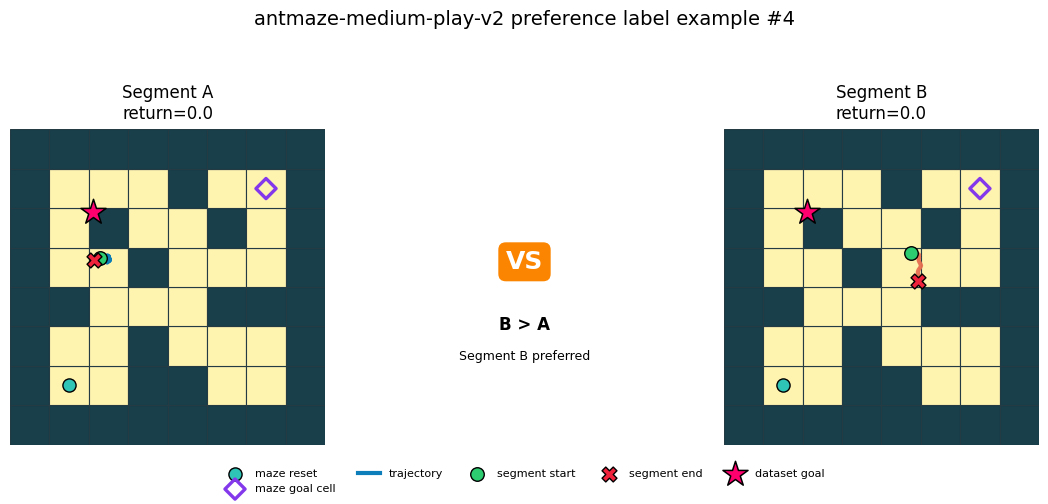

In [ ]:
import os
import pickle
from pathlib import Path

import gym
import d4rl
from d4rl.offline_env import set_dataset_path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Preference query index to visualize.
# If prefer_non_tie=True and index 0 is Tie / uncertain, the first non-tie example is shown.
example_idx = 0
prefer_non_tie = True

label_dir = REPO_DIR / "human_label" / D4RL_ENV
indices_1_path = label_dir / "indices_num1000"
indices_2_path = label_dir / "indices_2_num1000"
labels_path = label_dir / "label_human"

with open(indices_1_path, "rb") as f:
    indices_1 = np.asarray(pickle.load(f), dtype=np.int64)
with open(indices_2_path, "rb") as f:
    indices_2 = np.asarray(pickle.load(f), dtype=np.int64)
with open(labels_path, "rb") as f:
    labels = np.asarray(pickle.load(f)).reshape(-1)

if prefer_non_tie and int(labels[example_idx]) == -1:
    non_tie_indices = np.flatnonzero(labels != -1)
    if len(non_tie_indices) > 0:
        original_idx = example_idx
        example_idx = int(non_tie_indices[0])
        print(
            f"example_idx={original_idx} is Tie / uncertain, "
            f"so this cell shows first non-tie example_idx={example_idx}. "
            "Set prefer_non_tie=False to force index 0."
        )

if not (0 <= example_idx < len(labels)):
    raise IndexError(f"example_idx must be in [0, {len(labels) - 1}], got {example_idx}")

label = int(np.asarray(labels[example_idx]).item())
label_text = {0: "Segment A preferred", 1: "Segment B preferred", -1: "Tie / uncertain"}.get(label, f"Unknown label: {label}")
pref_text = {0: "A > B", 1: "B > A", -1: "A = B / uncertain"}.get(label, str(label))

# Convert the raw D4RL dataset to the same q-learning transition indexing used by the human-label code.
# Static plotting only needs xy, goal, and reward; qpos/qvel render states are not needed.
def qlearning_ant_dataset_for_plot(env, dataset):
    n = dataset["rewards"].shape[0]
    use_timeouts = "timeouts" in dataset
    episode_step = 0
    out = {key: [] for key in ["rewards", "goals", "xys"]}

    for i in range(n - 1):
        done_bool = bool(dataset["terminals"][i])
        if use_timeouts:
            final_timestep = bool(dataset["timeouts"][i])
        else:
            final_timestep = episode_step == env._max_episode_steps - 1

        if final_timestep:
            episode_step = 0
            continue
        if done_bool:
            episode_step = 0

        out["rewards"].append(dataset["rewards"][i].astype(np.float32))
        out["goals"].append(dataset["infos/goal"][i].astype(np.float32))
        out["xys"].append(dataset["infos/qpos"][i][:2].astype(np.float32))
        episode_step += 1

    return {key: np.asarray(val) for key, val in out.items()}

set_dataset_path(str(D4RL_DATASET_DIR))
env = gym.make(D4RL_ENV)
raw_dataset = env.get_dataset()
dataset = qlearning_ant_dataset_for_plot(env, raw_dataset)

start_1 = int(indices_1[example_idx])
start_2 = int(indices_2[example_idx])
end_1 = start_1 + QUERY_LEN
end_2 = start_2 + QUERY_LEN

seg_a = slice(start_1, end_1)
seg_b = slice(start_2, end_2)
xy_1 = dataset["xys"][seg_a]
xy_2 = dataset["xys"][seg_b]
reward_sum_1 = float(np.sum(dataset["rewards"][seg_a]))
reward_sum_2 = float(np.sum(dataset["rewards"][seg_b]))
goal = dataset["goals"][start_1]

print(f"Example index: {example_idx}")
print(f"Label raw value: {label} -> {label_text}")
print(f"Segment A: start={start_1}, end={end_1}, reward_sum={reward_sum_1:.3f}")
print(f"Segment B: start={start_2}, end={end_2}, reward_sum={reward_sum_2:.3f}")
print(f"Goal xy: {goal}")

# D4RL maze layout for antmaze-medium-play-v2. 1=wall, 0=open, r=reset, g=nominal goal cell.
# Draw this grid directly instead of using MuJoCo/OpenGL rendering.
try:
    from d4rl.locomotion.maze_env import BIG_MAZE_TEST, RESET, GOAL
    maze_layout = BIG_MAZE_TEST
except Exception:
    RESET = "r"
    GOAL = "g"
    maze_layout = [
        [1, 1, 1, 1, 1, 1, 1, 1],
        [1, RESET, 0, 1, 1, 0, 0, 1],
        [1, 0, 0, 1, 0, 0, 0, 1],
        [1, 1, 0, 0, 0, 1, 1, 1],
        [1, 0, 0, 1, 0, 0, 0, 1],
        [1, 0, 1, 0, 0, 1, 0, 1],
        [1, 0, 0, 0, 1, 0, GOAL, 1],
        [1, 1, 1, 1, 1, 1, 1, 1],
    ]

maze = np.asarray(maze_layout, dtype=object)
maze_scale = 4.0
reset_cells = np.argwhere(maze == RESET)
if len(reset_cells) == 0:
    raise RuntimeError("Could not find reset cell in AntMaze layout.")
reset_row, reset_col = reset_cells[0]
init_torso_x = reset_col * maze_scale
init_torso_y = reset_row * maze_scale

n_rows, n_cols = maze.shape
x_min = -init_torso_x - maze_scale / 2
x_max = (n_cols - 1) * maze_scale - init_torso_x + maze_scale / 2
y_min = -init_torso_y - maze_scale / 2
y_max = (n_rows - 1) * maze_scale - init_torso_y + maze_scale / 2

def cell_center(row, col):
    return col * maze_scale - init_torso_x, row * maze_scale - init_torso_y

def draw_maze(ax):
    ax.set_facecolor("#f5d99b")
    for row in range(n_rows):
        for col in range(n_cols):
            cx, cy = cell_center(row, col)
            value = maze[row, col]
            is_wall = value == 1
            rect = patches.Rectangle(
                (cx - maze_scale / 2, cy - maze_scale / 2),
                maze_scale,
                maze_scale,
                linewidth=0.8,
                edgecolor="#243b43",
                facecolor="#183f4a" if is_wall else "#fff3b0",
                alpha=1.0,
                zorder=0,
            )
            ax.add_patch(rect)
            if value == RESET:
                ax.scatter(cx, cy, marker="o", s=90, c="#2ec4b6", edgecolors="black", zorder=2, label="maze reset")
            if value == GOAL:
                ax.scatter(cx, cy, marker="D", s=105, facecolors="none", edgecolors="#8338ec", linewidths=2.4, zorder=3, label="maze goal cell")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

def draw_trajectory(ax, xy, color, title, reward_sum):
    draw_maze(ax)
    ax.plot(xy[:, 0], xy[:, 1], color=color, linewidth=3.0, alpha=0.95, zorder=4, label="trajectory")

    deltas = np.diff(xy, axis=0)
    speeds = np.linalg.norm(deltas, axis=1)
    moving = np.flatnonzero(speeds > 1e-4)
    if len(moving) > 0:
        arrow_count = min(8, len(moving))
        arrow_idx = moving[np.linspace(0, len(moving) - 1, arrow_count, dtype=int)]
        ax.quiver(
            xy[arrow_idx, 0],
            xy[arrow_idx, 1],
            deltas[arrow_idx, 0],
            deltas[arrow_idx, 1],
            angles="xy",
            scale_units="xy",
            scale=1,
            color=color,
            width=0.006,
            headwidth=4.5,
            headlength=5.5,
            headaxislength=4.5,
            zorder=5,
        )

    ax.scatter(xy[0, 0], xy[0, 1], marker="o", s=95, c="#2ecc71", edgecolors="black", zorder=6, label="segment start")
    ax.scatter(xy[-1, 0], xy[-1, 1], marker="X", s=115, c="#ef233c", edgecolors="black", zorder=6, label="segment end")
    ax.scatter(goal[0], goal[1], marker="*", s=360, c="#ff006e", edgecolors="black", linewidths=1.1, zorder=8, label="dataset goal")
    ax.set_title(f"{title}\nreturn={reward_sum:.1f}", fontsize=12, pad=8)

fig, axes = plt.subplots(1, 3, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 0.16, 1]})
draw_trajectory(axes[0], xy_1, "#0077b6", "Segment A", reward_sum_1)
draw_trajectory(axes[2], xy_2, "#e76f51", "Segment B", reward_sum_2)

axes[1].set_axis_off()
axes[1].text(
    0.5,
    0.58,
    "VS",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    color="white",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#fb8500", edgecolor="none"),
)
axes[1].text(0.5, 0.38, pref_text, ha="center", va="center", fontsize=12, fontweight="bold")
axes[1].text(0.5, 0.28, label_text, ha="center", va="center", fontsize=9, wrap=True)

handles, legend_labels = axes[0].get_legend_handles_labels()
unique = dict(zip(legend_labels, handles))
fig.legend(unique.values(), unique.keys(), loc="lower center", ncol=5, fontsize=8, frameon=False)
fig.suptitle(f"{D4RL_ENV} preference label example #{example_idx}", fontsize=14)
plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()


## 5. Training

- Train the Preference Transformer reward model from human preference labels.
- Train IQL with rewards relabeled by the learned Preference Transformer checkpoint.
- Save logs and policy parameters for evaluation, rollout visualization, and later reuse.


### 5.1 AntMaze Import Patch

- Patch the reward script so `robosuite` and `robomimic` are imported only for robosuite experiments.
- Keep the AntMaze/D4RL baseline independent of optional robosuite dependencies.
- Run once before reward-model training on a fresh server copy.


In [ ]:
from pathlib import Path
import subprocess
import sys

script_path = REPO_DIR / "JaxPref" / "new_preference_reward_main.py"
text = script_path.read_text(encoding="utf-8")

old_import = """import robosuite as suite
from robosuite.wrappers import GymWrapper
import robomimic.utils.env_utils as EnvUtils
"""
new_import = """try:
    import robosuite as suite
    from robosuite.wrappers import GymWrapper
    import robomimic.utils.env_utils as EnvUtils
    ROBOSUITE_IMPORT_ERROR = None
except Exception as exc:
    suite = None
    GymWrapper = None
    EnvUtils = None
    ROBOSUITE_IMPORT_ERROR = exc
"""

old_guard = """    if FLAGS.robosuite:
        dataset = r_tf.qlearning_robosuite_dataset("""
new_guard = """    if FLAGS.robosuite:
        if ROBOSUITE_IMPORT_ERROR is not None:
            raise ImportError(
                "robosuite/robomimic is required only for robosuite experiments. "
                "Install those packages or run with --robosuite False for D4RL tasks."
            ) from ROBOSUITE_IMPORT_ERROR
        dataset = r_tf.qlearning_robosuite_dataset("""

changed = False
if old_import in text:
    text = text.replace(old_import, new_import, 1)
    changed = True

if old_guard in text:
    text = text.replace(old_guard, new_guard, 1)
    changed = True

if changed:
    script_path.write_text(text, encoding="utf-8")
    print("Patched:", script_path)
else:
    print("Patch was already applied or the script format is different:", script_path)

result = subprocess.run(
    [str(PYTHON_EXECUTABLE), "-m", "py_compile", str(script_path)],
    text=True,
    capture_output=True,
)
print(result.stdout.strip())
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("py_compile failed after patching reward script.")

print("Reward script import patch check passed. You can restart reward training.")


Patch was already applied or the script format is different: /home/KHJ/AI611/PreferenceTransformer/JaxPref/new_preference_reward_main.py

Reward script import patch check passed. You can restart reward training.


### 5.2 W&B Login (Optional)

- Keep `WANDB_ONLINE=False` for local/offline logging.
- Set `WANDB_ONLINE=True` only when uploading logs to W&B.
- Enter the API key through hidden input and do not store it in the notebook.


In [ ]:
import getpass
import os
import re

import wandb
from packaging import version

wandb_online = os.environ.get("WANDB_ONLINE", "False").lower() == "true"
wandb_project = os.environ.get("WANDB_PROJECT", "PrefRL")

print("WANDB_ONLINE:", wandb_online)
print("WANDB_PROJECT:", wandb_project)
print("wandb version:", wandb.__version__)

if not wandb_online:
    os.environ["WANDB_MODE"] = "offline"
    print("W&B online logging is disabled. Training will save offline W&B logs locally.")
    print("Set WANDB_ONLINE=True in the config cell before using online logging.")
else:
    os.environ["WANDB_MODE"] = "online"

    raw_key = os.environ.get("WANDB_API_KEY", "").strip()
    if not raw_key:
        raw_key = getpass.getpass("Paste your W&B API key (input hidden): ").strip()

    compact_key = re.sub(r"\s+", "", raw_key)
    candidates = re.findall(r"wandb_v1_[A-Za-z0-9_-]+", compact_key)
    candidates += re.findall(r"(?<![A-Za-z0-9])[A-Za-z0-9]{40}(?![A-Za-z0-9])", compact_key)
    api_key = max(candidates, key=len) if candidates else compact_key

    if not api_key:
        raise RuntimeError("W&B API key was empty. Create a key at https://wandb.ai/authorize and rerun this cell.")

    masked_key = api_key[:12] + "..." + api_key[-6:] if len(api_key) > 24 else "<too short>"
    print("Detected key length:", len(api_key))
    print("Detected key preview:", masked_key)

    current_version = version.parse(wandb.__version__)
    min_new_key_version = version.parse("0.22.3")
    uses_new_key_format = api_key.startswith("wandb_v1_")

    if uses_new_key_format and len(api_key) < 80:
        raise ValueError(
            "The pasted W&B key looks truncated. New-format keys usually start with 'wandb_v1_' "
            "and are much longer than 45 characters. Copy the full key from https://wandb.ai/authorize."
        )

    if uses_new_key_format and current_version < min_new_key_version:
        raise RuntimeError(
            "This environment has an older wandb SDK that cannot authenticate new-format API keys.\n"
            f"Current wandb version: {wandb.__version__}\n"
            f"Upgrade in this conda env, restart the kernel, then rerun config/login cells:\n"
            f"  {PYTHON_EXECUTABLE} -m pip install --upgrade wandb==0.22.3"
        )

    os.environ["WANDB_API_KEY"] = api_key
    wandb.login(key=api_key, relogin=True)
    print("W&B login complete. Reward training will use online logging.")


WANDB_ONLINE: False
WANDB_PROJECT: PrefRL
wandb version: 0.22.3
W&B online logging is disabled. Training will save offline W&B logs locally.
Set WANDB_ONLINE=True in the config cell before using online logging.


### 5.3 Reward Model Training

- Start Preference Transformer reward-model training in the background.
- Write logs to `reward_train.log` under `NOTEBOOK_RUN_DIR`.
- Monitor progress with the next cell.


In [ ]:
%%bash
set -euo pipefail

: "${REPO_DIR:?Run the D4RL experiment/path config cell first.}"
: "${NOTEBOOK_RUN_DIR:?Run the D4RL experiment/path config cell first.}"
: "${PYTHON_EXECUTABLE:?Run the D4RL experiment/path config cell first.}"
: "${WANDB_ONLINE:=False}"
: "${WANDB_PROJECT:=PrefRL}"

cd "$REPO_DIR"
mkdir -p "$NOTEBOOK_RUN_DIR"

log_file="$NOTEBOOK_RUN_DIR/reward_train.log"
pid_file="$NOTEBOOK_RUN_DIR/reward_train.pid"

if [[ -f "$pid_file" ]] && kill -0 "$(cat "$pid_file")" 2>/dev/null; then
  echo "Reward model training is already running. PID=$(cat "$pid_file")"
  echo "Log: $log_file"
  exit 0
fi

nohup env PYTHONUNBUFFERED=1 CUDA_VISIBLE_DEVICES="${CUDA_VISIBLE_DEVICES:-0}" \
"$PYTHON_EXECUTABLE" -u -m JaxPref.new_preference_reward_main \
  --use_human_label True \
  --comment "$EXPERIMENT_NAME" \
  --transformer.embd_dim 256 \
  --transformer.n_layer 1 \
  --transformer.n_head 4 \
  --env "$D4RL_ENV" \
  --logging.output_dir "$REWARD_LOG_DIR" \
  --logging.online "$WANDB_ONLINE" \
  --logging.project "$WANDB_PROJECT" \
  --batch_size "$REWARD_BATCH_SIZE" \
  --num_query "$NUM_QUERY" \
  --query_len "$QUERY_LEN" \
  --n_epochs "$REWARD_N_EPOCHS" \
  --skip_flag 0 \
  --seed "$SEED" \
  --model_type "$MODEL_TYPE" \
  > "$log_file" 2>&1 &

echo $! > "$pid_file"
echo "Started reward model training. PID=$(cat "$pid_file")"
echo "Log: $log_file"
echo "Run the next monitoring cell to watch progress inside this notebook."

Started reward model training. PID=892160
Log: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/reward_train.log
Run the next monitoring cell to watch progress inside this notebook.


In [ ]:
import os
import subprocess
import time
from pathlib import Path
from IPython.display import clear_output

run_dir = Path(os.environ["NOTEBOOK_RUN_DIR"])
log_file = run_dir / "reward_train.log"
pid_file = run_dir / "reward_train.pid"
ckpt_path = Path(os.environ["CKPT_PATH"])

def pid_running(pid: str) -> bool:
    return subprocess.run(["bash", "-lc", f"kill -0 {pid} 2>/dev/null"], capture_output=True).returncode == 0

def tail_text(path: Path, n: int = 80) -> str:
    if not path.exists():
        return f"{path} does not exist yet."
    text = path.read_text(errors="replace")
    text = text.replace("\r", "\n")
    lines = [line for line in text.splitlines() if line.strip()]
    return "\n".join(lines[-n:])

def gpu_text() -> str:
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.used,memory.total,utilization.gpu", "--format=csv,noheader"],
            text=True,
            capture_output=True,
            timeout=5,
        )
        return result.stdout.strip() or result.stderr.strip()
    except Exception as exc:
        return f"nvidia-smi unavailable: {exc}"

while True:
    clear_output(wait=True)
    pid = pid_file.read_text().strip() if pid_file.exists() else None
    running = bool(pid and pid_running(pid))
    print("Reward training monitor")
    print("PID:", pid or "not started")
    print("Running:", running)
    print("Log:", log_file)
    print("ckpt_path:", ckpt_path)
    print("best_model.pkl:", (ckpt_path / "best_model.pkl").exists())
    print("model.pkl:", (ckpt_path / "model.pkl").exists())
    print("\nGPU")
    print(gpu_text())
    print("\nLast log lines")
    print(tail_text(log_file))
    if not running:
        break
    time.sleep(10)

Reward training monitor
PID: 892160
Running: False
Log: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/reward_train.log
ckpt_path: /home/KHJ/AI611/PreferenceTransformer/logs/pref_reward/antmaze-medium-play-v2/PrefTransformer/team16_antmaze_medium_play_pt_baseline/s42
best_model.pkl: True
model.pkl: True

GPU
NVIDIA GeForce RTX 3090, 582 MiB, 24576 MiB, 0 %
NVIDIA GeForce RTX 3090, 22061 MiB, 24576 MiB, 0 %
NVIDIA GeForce RTX 3090, 18 MiB, 24576 MiB, 0 %
NVIDIA GeForce RTX 3090, 18 MiB, 24576 MiB, 0 %

Last log lines
	Buffer 3:
		Size: 200.00MiB
		Operator: op_name="jit(_train_pref_step)/jit(main)/dot_general[dimension_numbers=(((2,), (1,)), ((), ())) precision=None preferred_element_type=None]" source_file="/home/KHJ/AI611/PreferenceTransformer/flaxmodels/flaxmodels/gpt2/trajectory_gpt2.py" source_line=114
		XLA Label: custom-call
		Shape: f32[51200,1024]
	Buffer 4:
		Size: 156.25MiB
		Operator: op_name="jit(_train_pref_step)/jit(main)/se

### 5.4 Reward Checkpoint Check

- Verify that `ckpt_path` contains `best_model.pkl` or `model.pkl`.
- Use this reward-model checkpoint for learned-reward IQL.
- Update `ckpt_path` in the config cell when using an external checkpoint.


In [ ]:
from pathlib import Path
import os

ckpt_path = Path(os.environ["CKPT_PATH"])
best_model = ckpt_path / "best_model.pkl"
last_model = ckpt_path / "model.pkl"

print("ckpt_path:", ckpt_path)
print("best_model.pkl exists:", best_model.exists())
print("model.pkl exists:", last_model.exists())

if not best_model.exists() and not last_model.exists():
    raise FileNotFoundError(
        "Reward model checkpoint was not found. "
        "Run the reward model training cell first, or update ckpt_path in the config cell."
    )


ckpt_path: /home/KHJ/AI611/PreferenceTransformer/logs/pref_reward/antmaze-medium-play-v2/PrefTransformer/team16_antmaze_medium_play_pt_baseline/s42
best_model.pkl exists: True
model.pkl exists: True


### 5.5 IQL Full Checkpoint Patch

- Patch `train_offline.py` to save actor, critic, value, and target-critic parameters.
- Save both individual `.params` files and full `iql_checkpoint_*.pkl` files.
- Use full checkpoints for later fine-tuning or policy analysis.


In [ ]:
from pathlib import Path
import subprocess

script_path = REPO_DIR / "train_offline.py"
text = script_path.read_text(encoding="utf-8")
changed = False

if "import jax" not in text:
    text = text.replace("import gym\n", "import gym\nimport jax\n", 1)
    changed = True

flag_anchor = "flags.DEFINE_string('label_mode', 'last', 'mode for relabeling reward with tranformer.')"
flag_insert = "flags.DEFINE_string('label_mode', 'last', 'mode for relabeling reward with tranformer.')\nflags.DEFINE_boolean('save_policy_ckpt', False,\n                     'Save IQL parameter checkpoints for later inference/fine-tuning.')\nflags.DEFINE_string('policy_ckpt_dir', '',\n                    'Directory where IQL parameter checkpoints are saved.')\nflags.DEFINE_integer('policy_ckpt_interval', 0,\n                     'Save a checkpoint every N training steps. 0 means only final/latest saves.')"
if "save_policy_ckpt" not in text:
    text = text.replace(flag_anchor, flag_insert, 1)
    changed = True

full_function = "\n\ndef save_policy_checkpoint(agent: Learner, step: int, tag: str = None):\n    if not FLAGS.save_policy_ckpt:\n        return\n    if not FLAGS.policy_ckpt_dir:\n        raise ValueError('--policy_ckpt_dir must be set when --save_policy_ckpt=True')\n\n    os.makedirs(FLAGS.policy_ckpt_dir, exist_ok=True)\n    name = tag if tag is not None else f'step_{step}'\n    param_paths = {\n        'actor': os.path.join(FLAGS.policy_ckpt_dir, f'actor_{name}.params'),\n        'critic': os.path.join(FLAGS.policy_ckpt_dir, f'critic_{name}.params'),\n        'value': os.path.join(FLAGS.policy_ckpt_dir, f'value_{name}.params'),\n        'target_critic': os.path.join(FLAGS.policy_ckpt_dir, f'target_critic_{name}.params'),\n    }\n    latest_param_paths = {\n        'actor': os.path.join(FLAGS.policy_ckpt_dir, 'actor_latest.params'),\n        'critic': os.path.join(FLAGS.policy_ckpt_dir, 'critic_latest.params'),\n        'value': os.path.join(FLAGS.policy_ckpt_dir, 'value_latest.params'),\n        'target_critic': os.path.join(FLAGS.policy_ckpt_dir, 'target_critic_latest.params'),\n    }\n    full_ckpt_path = os.path.join(FLAGS.policy_ckpt_dir, f'iql_checkpoint_{name}.pkl')\n    latest_full_ckpt_path = os.path.join(FLAGS.policy_ckpt_dir, 'iql_checkpoint_latest.pkl')\n\n    metadata = {\n        'step': int(step),\n        'env_name': FLAGS.env_name,\n        'seed': FLAGS.seed,\n        'config': dict(FLAGS.config),\n        'comment': FLAGS.comment,\n        'use_reward_model': FLAGS.use_reward_model,\n        'model_type': FLAGS.model_type,\n        'reward_ckpt_dir': FLAGS.ckpt_dir,\n        'param_paths': param_paths,\n        'full_ckpt_path': full_ckpt_path,\n    }\n\n    agent.actor.save(param_paths['actor'])\n    agent.actor.save(latest_param_paths['actor'])\n    agent.critic.save(param_paths['critic'])\n    agent.critic.save(latest_param_paths['critic'])\n    agent.value.save(param_paths['value'])\n    agent.value.save(latest_param_paths['value'])\n    agent.target_critic.save(param_paths['target_critic'])\n    agent.target_critic.save(latest_param_paths['target_critic'])\n\n    full_checkpoint = {\n        'metadata': metadata,\n        'params': {\n            'actor': jax.device_get(agent.actor.params),\n            'critic': jax.device_get(agent.critic.params),\n            'value': jax.device_get(agent.value.params),\n            'target_critic': jax.device_get(agent.target_critic.params),\n        },\n        'opt_state': {\n            'actor': jax.device_get(agent.actor.opt_state),\n            'critic': jax.device_get(agent.critic.opt_state),\n            'value': jax.device_get(agent.value.opt_state),\n        },\n        'rng': jax.device_get(agent.rng),\n    }\n\n    with open(full_ckpt_path, 'wb') as f:\n        pickle.dump(full_checkpoint, f)\n    with open(latest_full_ckpt_path, 'wb') as f:\n        pickle.dump(full_checkpoint, f)\n    with open(os.path.join(FLAGS.policy_ckpt_dir, f'metadata_{name}.pkl'), 'wb') as f:\n        pickle.dump(metadata, f)\n    with open(os.path.join(FLAGS.policy_ckpt_dir, 'metadata_latest.pkl'), 'wb') as f:\n        pickle.dump(metadata, f)\n    print(f'Saved IQL params checkpoint: {full_ckpt_path}', flush=True)\n"
if "def save_policy_checkpoint" in text:
    start = text.index("\ndef save_policy_checkpoint")
    end = text.index("\ndef main(_):", start)
    existing = text[start:end]
    if "iql_checkpoint_latest.pkl" not in existing or "target_critic_latest.params" not in existing:
        text = text[:start] + full_function + text[end:]
        changed = True
else:
    text = text.replace("\n\ndef main(_):", full_function + "\n\ndef main(_):", 1)
    changed = True

eval_save = "            np.savetxt(os.path.join(save_dir, 'progress.txt'),\n                       eval_returns,\n                       fmt=['%d', '%.1f'])"
eval_save_new = "            np.savetxt(os.path.join(save_dir, 'progress.txt'),\n                       eval_returns,\n                       fmt=['%d', '%.1f'])\n\n            if FLAGS.policy_ckpt_interval > 0 and i % FLAGS.policy_ckpt_interval == 0:\n                save_policy_checkpoint(agent, i)"
loop_start = text.find("for i in tqdm")
if loop_start != -1 and "policy_ckpt_interval" not in text[loop_start:]:
    text = text.replace(eval_save, eval_save_new, 1)
    changed = True

if "save_policy_checkpoint(agent, FLAGS.max_steps, tag='final')" not in text:
    text = text.replace("\n\nif __name__ == '__main__':", "\n\n    save_policy_checkpoint(agent, FLAGS.max_steps, tag='final')\n\n\nif __name__ == '__main__':", 1)
    changed = True

if changed:
    script_path.write_text(text, encoding="utf-8")
    print("Patched full IQL checkpoint saving:", script_path)
else:
    print("Full IQL checkpoint saving is already applied:", script_path)

result = subprocess.run([str(PYTHON_EXECUTABLE), "-m", "py_compile", str(script_path)], text=True, capture_output=True)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("train_offline.py py_compile failed.")
print("IQL full checkpoint patch check passed.")


Full IQL checkpoint saving is already applied: /home/KHJ/AI611/PreferenceTransformer/train_offline.py
IQL full checkpoint patch check passed.


### 5.6 IQL Training

- Train IQL with the learned Preference Transformer reward model.
- Save evaluation logs and IQL checkpoints under `NOTEBOOK_RUN_DIR`.
- Monitor progress with the next cell.


In [ ]:
%%bash
set -euo pipefail

: "${REPO_DIR:?Run the D4RL experiment/path config cell first.}"
: "${CKPT_PATH:?Run the D4RL experiment/path config cell first.}"
: "${NOTEBOOK_RUN_DIR:?Run the D4RL experiment/path config cell first.}"
: "${PYTHON_EXECUTABLE:?Run the D4RL experiment/path config cell first.}"
: "${IQL_POLICY_CKPT_DIR:?Run the D4RL experiment/path config cell first.}"
: "${SAVE_IQL_POLICY_CKPT:=True}"
: "${IQL_POLICY_CKPT_INTERVAL:=${EVAL_INTERVAL:-100000}}"

cd "$REPO_DIR"
mkdir -p "$NOTEBOOK_RUN_DIR"

# Reward checkpoint path passed to train_offline.py.
ckpt_path="$CKPT_PATH"

if [[ ! -f "$ckpt_path/best_model.pkl" && ! -f "$ckpt_path/model.pkl" ]]; then
  echo "ERROR: reward model checkpoint not found in $ckpt_path"
  echo "Run reward model training first, or update ckpt_path in the config cell."
  exit 1
fi

log_file="$NOTEBOOK_RUN_DIR/iql_train.log"
pid_file="$NOTEBOOK_RUN_DIR/iql_train.pid"

if [[ -f "$pid_file" ]] && kill -0 "$(cat "$pid_file")" 2>/dev/null; then
  echo "IQL training is already running. PID=$(cat "$pid_file")"
  echo "Log: $log_file"
  exit 0
fi

nohup env PYTHONUNBUFFERED=1 CUDA_VISIBLE_DEVICES="${CUDA_VISIBLE_DEVICES:-0}" \
"$PYTHON_EXECUTABLE" -u train_offline.py \
  --seq_len "$SEQ_LEN" \
  --comment "${EXPERIMENT_NAME}_iql" \
  --eval_interval "$EVAL_INTERVAL" \
  --env_name "$D4RL_ENV" \
  --config "$IQL_CONFIG" \
  --eval_episodes "$EVAL_EPISODES" \
  --batch_size "$IQL_BATCH_SIZE" \
  --max_steps "$IQL_MAX_STEPS" \
  --use_reward_model True \
  --model_type "$MODEL_TYPE" \
  --ckpt_dir "$ckpt_path" \
  --seed "$SEED" \
  --save_policy_ckpt "$SAVE_IQL_POLICY_CKPT" \
  --policy_ckpt_dir "$IQL_POLICY_CKPT_DIR" \
  --policy_ckpt_interval "$IQL_POLICY_CKPT_INTERVAL" \
  > "$log_file" 2>&1 &

echo $! > "$pid_file"
echo "Started IQL training. PID=$(cat "$pid_file")"
echo "Log: $log_file"
echo "Run the next monitoring cell to watch progress inside this notebook."


Started IQL training. PID=893447
Log: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_train.log
Run the next monitoring cell to watch progress inside this notebook.


In [ ]:
import os
import subprocess
import time
from pathlib import Path
from IPython.display import clear_output

repo_dir = Path(os.environ["REPO_DIR"])
run_dir = Path(os.environ["NOTEBOOK_RUN_DIR"])
policy_ckpt_dir = Path(os.environ.get("IQL_POLICY_CKPT_DIR", str(run_dir / "iql_policy_ckpt")))
log_file = run_dir / "iql_train.log"
pid_file = run_dir / "iql_train.pid"

def pid_running(pid: str) -> bool:
    return subprocess.run(["bash", "-lc", f"kill -0 {pid} 2>/dev/null"], capture_output=True).returncode == 0

def tail_text(path: Path, n: int = 80) -> str:
    if not path.exists():
        return f"{path} does not exist yet."
    text = path.read_text(errors="replace")
    text = text.replace("\r", "\n")
    lines = [line for line in text.splitlines() if line.strip()]
    return "\n".join(lines[-n:])

def latest_progress() -> Path:
    files = list((repo_dir / "logs").rglob("progress.txt"))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

def gpu_text() -> str:
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.used,memory.total,utilization.gpu", "--format=csv,noheader"],
            text=True,
            capture_output=True,
            timeout=5,
        )
        return result.stdout.strip() or result.stderr.strip()
    except Exception as exc:
        return f"nvidia-smi unavailable: {exc}"

while True:
    clear_output(wait=True)
    pid = pid_file.read_text().strip() if pid_file.exists() else None
    running = bool(pid and pid_running(pid))
    progress = latest_progress()
    print("IQL training monitor")
    print("PID:", pid or "not started")
    print("Running:", running)
    print("Log:", log_file)
    print("policy_ckpt_dir:", policy_ckpt_dir)
    print("actor_latest.params:", (policy_ckpt_dir / "actor_latest.params").exists())
    print("actor_final.params:", (policy_ckpt_dir / "actor_final.params").exists())
    print("critic_latest.params:", (policy_ckpt_dir / "critic_latest.params").exists())
    print("value_latest.params:", (policy_ckpt_dir / "value_latest.params").exists())
    print("target_critic_latest.params:", (policy_ckpt_dir / "target_critic_latest.params").exists())
    print("iql_checkpoint_latest.pkl:", (policy_ckpt_dir / "iql_checkpoint_latest.pkl").exists())
    print("iql_checkpoint_final.pkl:", (policy_ckpt_dir / "iql_checkpoint_final.pkl").exists())
    print("\nGPU")
    print(gpu_text())
    print("\nLatest progress.txt")
    if progress:
        print(progress)
        print(tail_text(progress, n=20))
    else:
        print("No progress.txt yet. It is created after the first evaluation interval.")
    print("\nLast log lines")
    print(tail_text(log_file))
    if not running:
        break
    time.sleep(10)

IQL training monitor
PID: 893447
Running: False
Log: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_train.log
policy_ckpt_dir: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_policy_ckpt
actor_latest.params: True
actor_final.params: True
critic_latest.params: True
value_latest.params: True
target_critic_latest.params: True
iql_checkpoint_latest.pkl: True
iql_checkpoint_final.pkl: True

GPU
NVIDIA GeForce RTX 3090, 582 MiB, 24576 MiB, 0 %
NVIDIA GeForce RTX 3090, 22061 MiB, 24576 MiB, 0 %
NVIDIA GeForce RTX 3090, 18 MiB, 24576 MiB, 0 %
NVIDIA GeForce RTX 3090, 18 MiB, 24576 MiB, 0 %

Latest progress.txt
/home/KHJ/AI611/PreferenceTransformer/logs/tb/antmaze-medium-play-v2/reward_True_PrefTransformer/team16_antmaze_medium_play_pt_baseline_iql/42/2026-06-12 21:39:04/progress.txt
100000 58.0
200000 59.0
300000 67.0
400000 71.0
500000 61.0
600000 69.0
700000 83.0
800000 73.0
900000 78.0
100

### 5.7 Stop Background Jobs

- Use only when a background reward or IQL job was started with incorrect settings.
- Set `STOP_REWARD=True` or `STOP_IQL=True`, then run the cell.
- Leave both values as `False` during normal experiments.


In [ ]:
import os
import subprocess
from pathlib import Path

STOP_REWARD = False
STOP_IQL = False

run_dir = Path(os.environ["NOTEBOOK_RUN_DIR"])

def stop_from_pid_file(pid_file: Path, name: str):
    if not pid_file.exists():
        print(f"{name}: pid file not found ({pid_file})")
        return
    pid = pid_file.read_text().strip()
    if not pid:
        print(f"{name}: empty pid file")
        return
    result = subprocess.run(["bash", "-lc", f"kill {pid}"], text=True, capture_output=True)
    if result.returncode == 0:
        print(f"{name}: stopped PID {pid}")
    else:
        print(f"{name}: could not stop PID {pid}")
        print(result.stderr.strip())

if STOP_REWARD:
    stop_from_pid_file(run_dir / "reward_train.pid", "reward training")
if STOP_IQL:
    stop_from_pid_file(run_dir / "iql_train.pid", "IQL training")
if not STOP_REWARD and not STOP_IQL:
    print("Nothing stopped. Set STOP_REWARD=True or STOP_IQL=True, then run this cell.")

Nothing stopped. Set STOP_REWARD=True or STOP_IQL=True, then run this cell.


## 6. Results

- Plot learned-reward IQL evaluation returns from `progress.txt`.
- Check saved actor and full IQL checkpoints for inference or fine-tuning.
- Visualize a deterministic IQL rollout on the static AntMaze map.


### 6.1 IQL Evaluation Curve

- Locate the latest IQL `progress.txt` file.
- Plot evaluation return against training steps.
- Use this result even when policy checkpoints are unavailable.


Latest progress.txt: /home/KHJ/AI611/PreferenceTransformer/logs/tb/antmaze-medium-play-v2/reward_True_PrefTransformer/team16_antmaze_medium_play_pt_baseline_iql/42/2026-06-12 21:39:04/progress.txt


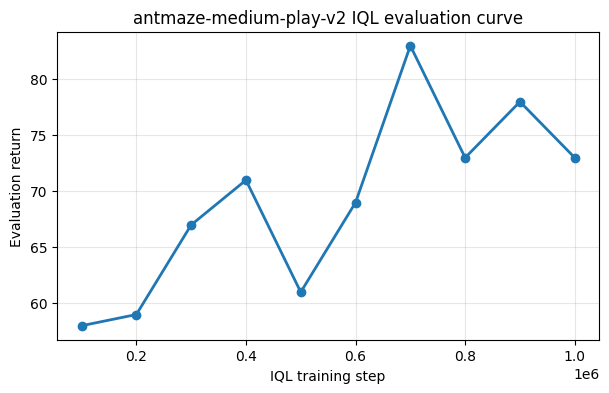

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_dir = Path(os.environ["REPO_DIR"])
run_dir = Path(os.environ["NOTEBOOK_RUN_DIR"])

progress_files = []
for root in [repo_dir / "logs", run_dir]:
    if root.exists():
        progress_files.extend(root.rglob("progress.txt"))

if not progress_files:
    print("No progress.txt found yet. Run/monitor IQL training first.")
else:
    latest_progress = max(progress_files, key=lambda p: p.stat().st_mtime)
    print("Latest progress.txt:", latest_progress)
    data = np.loadtxt(latest_progress)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    plt.figure(figsize=(7, 4))
    plt.plot(data[:, 0], data[:, 1], marker="o", linewidth=2)
    plt.xlabel("IQL training step")
    plt.ylabel("Evaluation return")
    plt.title(f"{D4RL_ENV} IQL evaluation curve")
    plt.grid(True, alpha=0.3)
    plt.show()


### 6.2 IQL Checkpoint Check

- Locate saved IQL actor parameters and full checkpoints.
- Use `actor_*.params` for rollout visualization.
- Use `iql_checkpoint_*.pkl` or individual params for fine-tuning.


In [ ]:
import os
from pathlib import Path

run_dir = Path(os.environ["NOTEBOOK_RUN_DIR"])
policy_ckpt_dir = Path(os.environ.get("IQL_POLICY_CKPT_DIR", str(run_dir / "iql_policy_ckpt")))
expected_latest_actor = policy_ckpt_dir / "actor_latest.params"
expected_final_actor = policy_ckpt_dir / "actor_final.params"
expected_latest_full = policy_ckpt_dir / "iql_checkpoint_latest.pkl"
expected_final_full = policy_ckpt_dir / "iql_checkpoint_final.pkl"

candidate_roots = [policy_ckpt_dir, run_dir, Path(os.environ["REPO_DIR"]) / "logs"]
actor_ckpts = []
full_ckpts = []
for root in candidate_roots:
    if root.exists():
        actor_ckpts.extend(root.rglob("actor_*.params"))
        full_ckpts.extend(root.rglob("iql_checkpoint_*.pkl"))

actor_ckpts = sorted({path.resolve() for path in actor_ckpts if path.is_file()}, key=lambda p: p.stat().st_mtime)
full_ckpts = sorted({path.resolve() for path in full_ckpts if path.is_file()}, key=lambda p: p.stat().st_mtime)
print("Expected IQL checkpoint dir:", policy_ckpt_dir)
print("Expected latest actor:", expected_latest_actor)
print("Expected final actor:", expected_final_actor)
print("Expected latest full ckpt:", expected_latest_full)
print("Expected final full ckpt:", expected_final_full)

if not actor_ckpts:
    os.environ.pop("IQL_ACTOR_CKPT_PATH", None)
    IQL_ACTOR_CKPT_PATH = None
    print("No IQL actor params found. 6.1 can plot progress.txt, but rollout visualization needs actor_*.params.")
else:
    if expected_final_actor.exists() and expected_final_actor.is_file():
        IQL_ACTOR_CKPT_PATH = expected_final_actor
    elif expected_latest_actor.exists() and expected_latest_actor.is_file():
        IQL_ACTOR_CKPT_PATH = expected_latest_actor
    else:
        IQL_ACTOR_CKPT_PATH = actor_ckpts[-1]
    os.environ["IQL_ACTOR_CKPT_PATH"] = str(IQL_ACTOR_CKPT_PATH)
    print("Using IQL actor params:", IQL_ACTOR_CKPT_PATH)

if not full_ckpts:
    os.environ.pop("IQL_FULL_CKPT_PATH", None)
    IQL_FULL_CKPT_PATH = None
    print("No full IQL checkpoint found. For fine-tuning, rerun IQL after applying the full checkpoint patch.")
else:
    if expected_final_full.exists() and expected_final_full.is_file():
        IQL_FULL_CKPT_PATH = expected_final_full
    elif expected_latest_full.exists() and expected_latest_full.is_file():
        IQL_FULL_CKPT_PATH = expected_latest_full
    else:
        IQL_FULL_CKPT_PATH = full_ckpts[-1]
    os.environ["IQL_FULL_CKPT_PATH"] = str(IQL_FULL_CKPT_PATH)
    print("Using full IQL checkpoint:", IQL_FULL_CKPT_PATH)

if actor_ckpts:
    print("\nRecent actor params:")
    for path in actor_ckpts[-10:]:
        print(" ", path)
if full_ckpts:
    print("\nRecent full checkpoints:")
    for path in full_ckpts[-10:]:
        print(" ", path)


Expected IQL checkpoint dir: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_policy_ckpt
Expected latest actor: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_policy_ckpt/actor_latest.params
Expected final actor: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_policy_ckpt/actor_final.params
Expected latest full ckpt: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_policy_ckpt/iql_checkpoint_latest.pkl
Expected final full ckpt: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_policy_ckpt/iql_checkpoint_final.pkl
Using IQL actor params: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_policy_ckpt/actor_final.params
Using full IQL checkpoint: /home/KHJ/AI611/PreferenceTransformer/notebook_

### 6.3 Load IQL Checkpoint for Fine-Tuning

- Restore actor, critic, value, and target-critic parameters into a `Learner`.
- Optionally restore optimizer states and RNG.
- Use this cell as a template for later fine-tuning experiments.


In [ ]:
import importlib.util
import os
import pickle
from pathlib import Path

import gym
import d4rl
from d4rl.offline_env import set_dataset_path

import wrappers
from learner import Learner

full_ckpt_value = os.environ.get("IQL_FULL_CKPT_PATH", "").strip()
if not full_ckpt_value:
    raise FileNotFoundError("IQL_FULL_CKPT_PATH is empty. Run the IQL Checkpoint Check cell first.")

full_ckpt_path = Path(full_ckpt_value).expanduser()
if not full_ckpt_path.exists() or not full_ckpt_path.is_file():
    raise FileNotFoundError(f"Full IQL checkpoint not found: {full_ckpt_path}")

with open(full_ckpt_path, "rb") as f:
    iql_ckpt = pickle.load(f)

config_path = REPO_DIR / IQL_CONFIG
spec = importlib.util.spec_from_file_location("iql_config", config_path)
config_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(config_module)
iql_config = config_module.get_config()

set_dataset_path(str(D4RL_DATASET_DIR))
env = gym.make(D4RL_ENV)
env = wrappers.EpisodeMonitor(env)
env = wrappers.SinglePrecision(env)
env.seed(SEED)
env.action_space.seed(SEED)
env.observation_space.seed(SEED)

FINETUNE_AGENT = Learner(
    SEED,
    env.observation_space.sample()[np.newaxis],
    env.action_space.sample()[np.newaxis],
    max_steps=IQL_MAX_STEPS,
    **dict(iql_config),
)

RESTORE_OPT_STATE = True
FINETUNE_AGENT.actor = FINETUNE_AGENT.actor.replace(params=iql_ckpt["params"]["actor"])
FINETUNE_AGENT.critic = FINETUNE_AGENT.critic.replace(params=iql_ckpt["params"]["critic"])
FINETUNE_AGENT.value = FINETUNE_AGENT.value.replace(params=iql_ckpt["params"]["value"])
FINETUNE_AGENT.target_critic = FINETUNE_AGENT.target_critic.replace(params=iql_ckpt["params"]["target_critic"])

if RESTORE_OPT_STATE and "opt_state" in iql_ckpt:
    FINETUNE_AGENT.actor = FINETUNE_AGENT.actor.replace(opt_state=iql_ckpt["opt_state"]["actor"])
    FINETUNE_AGENT.critic = FINETUNE_AGENT.critic.replace(opt_state=iql_ckpt["opt_state"]["critic"])
    FINETUNE_AGENT.value = FINETUNE_AGENT.value.replace(opt_state=iql_ckpt["opt_state"]["value"])
if RESTORE_OPT_STATE and "rng" in iql_ckpt:
    FINETUNE_AGENT.rng = iql_ckpt["rng"]

print("Loaded full IQL checkpoint for fine-tuning:", full_ckpt_path)
print("Checkpoint metadata:", iql_ckpt.get("metadata", {}))
print("FINETUNE_AGENT is ready. Use it as the initialized agent for your next fine-tuning loop.")


Loaded full IQL checkpoint for fine-tuning: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_policy_ckpt/iql_checkpoint_final.pkl
Checkpoint metadata: {'step': 1000000, 'env_name': 'antmaze-medium-play-v2', 'seed': 42, 'config': {'actor_lr': 0.0003, 'critic_lr': 0.0003, 'discount': 0.99, 'dropout_rate': None, 'expectile': 0.9, 'hidden_dims': (256, 256), 'tau': 0.005, 'temperature': 10.0, 'value_lr': 0.0003}, 'comment': 'team16_antmaze_medium_play_pt_baseline_iql', 'use_reward_model': True, 'model_type': 'PrefTransformer', 'reward_ckpt_dir': '/home/KHJ/AI611/PreferenceTransformer/logs/pref_reward/antmaze-medium-play-v2/PrefTransformer/team16_antmaze_medium_play_pt_baseline/s42', 'param_paths': {'actor': '/home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_policy_ckpt/actor_final.params', 'critic': '/home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42

/home/KHJ/miniconda3/envs/offline/lib/python3.8/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/KHJ/miniconda3/envs/offline/lib/python3.8/site-packages/gym/core.py:172: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed) instead.
  deprecation(


### 6.4 IQL Rollout Visualization

- Load the saved IQL actor parameters.
- Run one deterministic evaluation rollout.
- Draw the rollout trajectory on the static AntMaze map without MuJoCo rendering.


Loaded actor params: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_policy_ckpt/actor_final.params
Rollout steps: 372
Raw return: 1.0
Episode info: {'success': 100.0, 'return': 100.0, 'length': 372, 'duration': 0.8136935234069824}
Evaluation target goal: [20.675127 20.341864]
Saved visualization: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/iql_rollout_visualization.png


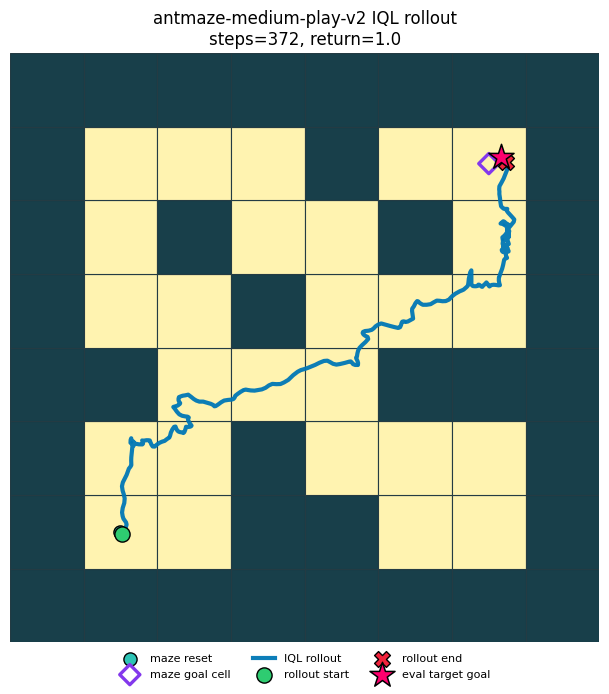

In [104]:
import importlib.util
import os
import pickle
from pathlib import Path

import gym
import d4rl
from d4rl.offline_env import set_dataset_path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

import wrappers
from learner import Learner

actor_ckpt_value = os.environ.get("IQL_ACTOR_CKPT_PATH", "").strip()
full_ckpt_value = os.environ.get("IQL_FULL_CKPT_PATH", "").strip()
expected_policy_dir = Path(os.environ.get("IQL_POLICY_CKPT_DIR", str(Path(os.environ["NOTEBOOK_RUN_DIR"]) / "iql_policy_ckpt")))
actor_ckpt_path = Path(actor_ckpt_value).expanduser() if actor_ckpt_value else None
full_ckpt_path = Path(full_ckpt_value).expanduser() if full_ckpt_value else None

if actor_ckpt_path is not None and actor_ckpt_path.is_dir():
    raise IsADirectoryError(f"IQL_ACTOR_CKPT_PATH points to a directory, not a params file: {actor_ckpt_path}")
if full_ckpt_path is not None and full_ckpt_path.is_dir():
    raise IsADirectoryError(f"IQL_FULL_CKPT_PATH points to a directory, not a pkl file: {full_ckpt_path}")

has_actor_params = actor_ckpt_path is not None and actor_ckpt_path.exists()
has_full_ckpt = full_ckpt_path is not None and full_ckpt_path.exists()
if not has_actor_params and not has_full_ckpt:
    raise FileNotFoundError(
        "No IQL actor/full checkpoint is available. Run the 'IQL Checkpoint Check' cell first. "
        f"Expected files include {expected_policy_dir / 'actor_latest.params'} and "
        f"{expected_policy_dir / 'iql_checkpoint_latest.pkl'}. If they do not exist, rerun IQL training after the full checkpoint patch."
    )

config_path = REPO_DIR / IQL_CONFIG
spec = importlib.util.spec_from_file_location("iql_config", config_path)
config_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(config_module)
iql_config = config_module.get_config()

set_dataset_path(str(D4RL_DATASET_DIR))
env = gym.make(D4RL_ENV)
env = wrappers.EpisodeMonitor(env)
env = wrappers.SinglePrecision(env)
env.seed(SEED)
env.action_space.seed(SEED)
env.observation_space.seed(SEED)

agent = Learner(
    SEED,
    env.observation_space.sample()[np.newaxis],
    env.action_space.sample()[np.newaxis],
    max_steps=IQL_MAX_STEPS,
    **dict(iql_config),
)
if has_actor_params:
    agent.actor = agent.actor.load(str(actor_ckpt_path))
    print("Loaded actor params:", actor_ckpt_path)
else:
    with open(full_ckpt_path, "rb") as f:
        iql_ckpt = pickle.load(f)
    agent.actor = agent.actor.replace(params=iql_ckpt["params"]["actor"])
    print("Loaded actor params from full checkpoint:", full_ckpt_path)

MAX_ROLLOUT_STEPS = getattr(env.env, "_max_episode_steps", 1000)

def walk_envs(env):
    current = env
    while True:
        yield current
        if not hasattr(current, "env"):
            break
        current = current.env

def extract_xy(env, observation):
    for current in walk_envs(env):
        if hasattr(current, "get_xy"):
            try:
                return np.asarray(current.get_xy(), dtype=np.float32)
            except Exception:
                pass
    return np.asarray(observation[:2], dtype=np.float32)

def extract_goal(env):
    for current in walk_envs(env):
        for attr in ["target_goal", "goal", "_goal"]:
            if hasattr(current, attr):
                value = getattr(current, attr)
                if value is not None:
                    value = np.asarray(value, dtype=np.float32).reshape(-1)
                    if len(value) >= 2:
                        return value[:2]
    return None

observation = env.reset()
goal = extract_goal(env)
xys = [extract_xy(env, observation)]
rewards = []
infos = []
done = False

for step in range(MAX_ROLLOUT_STEPS):
    action = agent.sample_actions(observation, temperature=0.0)
    observation, reward, done, info = env.step(action)
    xys.append(extract_xy(env, observation))
    rewards.append(float(reward))
    infos.append(info)
    if done:
        break

xys = np.asarray(xys)
episode_info = infos[-1].get("episode", {}) if infos else {}
print("Rollout steps:", len(rewards))
print("Raw return:", float(np.sum(rewards)))
if episode_info:
    print("Episode info:", episode_info)
if goal is not None:
    print("Evaluation target goal:", goal)

try:
    from d4rl.locomotion.maze_env import BIG_MAZE_TEST, RESET, GOAL
    maze_layout = BIG_MAZE_TEST
except Exception:
    RESET = "r"
    GOAL = "g"
    maze_layout = [
        [1, 1, 1, 1, 1, 1, 1, 1],
        [1, RESET, 0, 1, 1, 0, 0, 1],
        [1, 0, 0, 1, 0, 0, 0, 1],
        [1, 1, 0, 0, 0, 1, 1, 1],
        [1, 0, 0, 1, 0, 0, 0, 1],
        [1, 0, 1, 0, 0, 1, 0, 1],
        [1, 0, 0, 0, 1, 0, GOAL, 1],
        [1, 1, 1, 1, 1, 1, 1, 1],
    ]

maze = np.asarray(maze_layout, dtype=object)
maze_scale = 4.0
reset_row, reset_col = np.argwhere(maze == RESET)[0]
init_torso_x = reset_col * maze_scale
init_torso_y = reset_row * maze_scale
n_rows, n_cols = maze.shape
x_min = -init_torso_x - maze_scale / 2
x_max = (n_cols - 1) * maze_scale - init_torso_x + maze_scale / 2
y_min = -init_torso_y - maze_scale / 2
y_max = (n_rows - 1) * maze_scale - init_torso_y + maze_scale / 2

def cell_center(row, col):
    return col * maze_scale - init_torso_x, row * maze_scale - init_torso_y

def draw_maze(ax):
    ax.set_facecolor("#f5d99b")
    for row in range(n_rows):
        for col in range(n_cols):
            cx, cy = cell_center(row, col)
            value = maze[row, col]
            is_wall = value == 1
            ax.add_patch(
                patches.Rectangle(
                    (cx - maze_scale / 2, cy - maze_scale / 2),
                    maze_scale,
                    maze_scale,
                    linewidth=0.8,
                    edgecolor="#243b43",
                    facecolor="#183f4a" if is_wall else "#fff3b0",
                    zorder=0,
                )
            )
            if value == RESET:
                ax.scatter(cx, cy, marker="o", s=90, c="#2ec4b6", edgecolors="black", zorder=2, label="maze reset")
            if value == GOAL:
                ax.scatter(cx, cy, marker="D", s=105, facecolors="none", edgecolors="#8338ec", linewidths=2.4, zorder=3, label="maze goal cell")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig, ax = plt.subplots(figsize=(7, 7))
draw_maze(ax)
ax.plot(xys[:, 0], xys[:, 1], color="#0077b6", linewidth=3.0, alpha=0.95, zorder=4, label="IQL rollout")

if len(xys) > 2:
    deltas = np.diff(xys, axis=0)
    speeds = np.linalg.norm(deltas, axis=1)
    moving = np.flatnonzero(speeds > 1e-4)
    if len(moving) > 0:
        arrow_idx = moving[np.linspace(0, len(moving) - 1, min(12, len(moving)), dtype=int)]
        ax.quiver(
            xys[arrow_idx, 0], xys[arrow_idx, 1],
            deltas[arrow_idx, 0], deltas[arrow_idx, 1],
            angles="xy", scale_units="xy", scale=1,
            color="#0077b6", width=0.005, headwidth=4.5, headlength=5.5, zorder=5,
        )

ax.scatter(xys[0, 0], xys[0, 1], marker="o", s=120, c="#2ecc71", edgecolors="black", zorder=6, label="rollout start")
ax.scatter(xys[-1, 0], xys[-1, 1], marker="X", s=130, c="#ef233c", edgecolors="black", zorder=6, label="rollout end")
if goal is not None:
    ax.scatter(goal[0], goal[1], marker="*", s=360, c="#ff006e", edgecolors="black", linewidths=1.1, zorder=8, label="eval target goal")

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8, frameon=False)
ax.set_title(f"{D4RL_ENV} IQL rollout\nsteps={len(rewards)}, return={float(np.sum(rewards)):.1f}")
plt.tight_layout()

out_path = Path(os.environ["NOTEBOOK_RUN_DIR"]) / "iql_rollout_visualization.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=160, bbox_inches="tight")
print("Saved visualization:", out_path)
plt.show()


In [ ]:
%%bash
set -euo pipefail

cd "$REPO_DIR"

echo "Reward model checkpoint directory:"
echo "  $CKPT_PATH"
echo
echo "TensorBoard command:"
echo "  tensorboard --logdir logs --host 0.0.0.0 --port 6006"
echo
find logs -maxdepth 6 -name progress.txt -print 2>/dev/null || true


Reward model checkpoint directory:
  /home/KHJ/AI611/PreferenceTransformer/logs/pref_reward/antmaze-medium-play-v2/PrefTransformer/team16_antmaze_medium_play_pt_baseline/s42

TensorBoard command:
  tensorboard --logdir logs --host 0.0.0.0 --port 6006



## 7. Extension A: Multi-Context Decision Transformer OPPO

- This section implements our OPPO-based method extension after the PT + IQL baseline in Sections 1-6.
- The baseline PT pipeline converts human preference labels into a scalar reward model, then trains IQL with the learned reward.
- We start from OPPO because it directly learns a preference-guided contextual policy and avoids the separate reward-learning stage.
- Our novelty is to adapt OPPO to AntMaze's long-horizon navigation structure: instead of one optimal context, we learn multiple contexts that can specialize into different corridor or turning behaviors.
- A context selector chooses the context from recent trajectory history, and a Decision Transformer-style policy predicts actions from the selected context, state/action history, and goal-conditioned input.


### 7.1 Multi-Context Preference Objective

- This cell defines the basic losses used by MC-DT-OPPO.
- `multi_context_preference_loss` compares preferred and non-preferred trajectory embeddings against multiple learned contexts.
- `context_diversity_loss` discourages all contexts from collapsing into the same behavior.
- `context_usage_entropy` reports how evenly the preferred segments are assigned across contexts.


In [105]:
import jax
import jax.numpy as jnp


def l2_normalize(x, axis=-1, eps=1e-8):
    norm = jnp.linalg.norm(x, axis=axis, keepdims=True)
    return x / jnp.maximum(norm, eps)


def action_mse(pred_actions, target_actions):
    return jnp.mean((pred_actions - target_actions) ** 2)


def softmax_cross_entropy(logits, labels):
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    return -jnp.mean(log_probs[jnp.arange(labels.shape[0]), labels])


def multi_context_preference_loss(contexts, z_pos, z_neg, margin=1.0):
    contexts = l2_normalize(contexts)
    z_pos = l2_normalize(z_pos)
    z_neg = l2_normalize(z_neg)
    pos_dist = jnp.sum((z_pos[:, None, :] - contexts[None, :, :]) ** 2, axis=-1)
    neg_dist = jnp.sum((z_neg[:, None, :] - contexts[None, :, :]) ** 2, axis=-1)
    pos_min = jnp.min(pos_dist, axis=1)
    neg_min = jnp.min(neg_dist, axis=1)
    loss = jnp.maximum(pos_min - neg_min + margin, 0.0)
    accuracy = jnp.mean((pos_min < neg_min).astype(jnp.float32))
    assignment = jnp.argmin(pos_dist, axis=1)
    return jnp.mean(loss), accuracy, jnp.mean(pos_min), jnp.mean(neg_min), assignment


def context_diversity_loss(contexts):
    contexts = l2_normalize(contexts)
    similarity = contexts @ contexts.T
    off_diag = similarity - jnp.eye(contexts.shape[0], dtype=contexts.dtype)
    return jnp.mean(off_diag ** 2)


def context_usage_entropy(assignments, num_contexts):
    counts = jnp.bincount(assignments, length=num_contexts).astype(jnp.float32)
    probs = counts / jnp.maximum(jnp.sum(counts), 1.0)
    entropy = -jnp.sum(jnp.where(probs > 0, probs * jnp.log(probs + 1e-8), 0.0))
    return entropy, probs


### 7.2 Transformer Model Definitions

- This cell defines the neural network modules used by the method.
- `MCDTSequenceEncoder` encodes trajectory segments into preference embeddings.
- `MCDTPolicy` predicts actions from recent state/action history and a selected context.
- `MCDTContextSelector` chooses which learned context should guide the current policy step.


In [106]:
from typing import Sequence

import flax.linen as nn
import optax


class MCDTBlock(nn.Module):
    hidden_dim: int
    num_heads: int
    causal: bool = False

    @nn.compact
    def __call__(self, x):
        y = nn.LayerNorm()(x)
        mask = None
        if self.causal:
            mask = nn.make_causal_mask(jnp.ones((x.shape[0], x.shape[1]), dtype=bool))
        y = nn.SelfAttention(num_heads=self.num_heads, qkv_features=self.hidden_dim)(y, mask=mask)
        x = x + y
        y = nn.LayerNorm()(x)
        y = nn.Dense(4 * self.hidden_dim)(y)
        y = nn.gelu(y)
        y = nn.Dense(self.hidden_dim)(y)
        return x + y


class MCDTSequenceEncoder(nn.Module):
    hidden_dim: int = 128
    embed_dim: int = 64
    num_layers: int = 2
    num_heads: int = 4
    max_len: int = 100

    @nn.compact
    def __call__(self, observations, actions):
        x = jnp.concatenate([observations, actions], axis=-1)
        x = nn.Dense(self.hidden_dim)(x)
        pos_embed = self.param("pos_embed", nn.initializers.normal(stddev=0.02), (self.max_len, self.hidden_dim))
        x = x + pos_embed[: x.shape[1]][None, :, :]
        for _ in range(self.num_layers):
            x = MCDTBlock(self.hidden_dim, self.num_heads, causal=False)(x)
        x = nn.LayerNorm()(x)
        pooled = jnp.mean(x, axis=1)
        z = nn.Dense(self.embed_dim)(pooled)
        return l2_normalize(z)


class MCDTPolicy(nn.Module):
    action_dim: int
    hidden_dim: int = 128
    embed_dim: int = 64
    num_layers: int = 2
    num_heads: int = 4
    max_len: int = 25

    @nn.compact
    def __call__(self, observations, prev_actions, context):
        if context.ndim == 1:
            context = context[None, :]
        context_tokens = jnp.broadcast_to(context[:, None, :], observations.shape[:2] + (context.shape[-1],))
        x = jnp.concatenate([observations, prev_actions, context_tokens], axis=-1)
        x = nn.Dense(self.hidden_dim)(x)
        pos_embed = self.param("pos_embed", nn.initializers.normal(stddev=0.02), (self.max_len, self.hidden_dim))
        x = x + pos_embed[: x.shape[1]][None, :, :]
        for _ in range(self.num_layers):
            x = MCDTBlock(self.hidden_dim, self.num_heads, causal=True)(x)
        x = nn.LayerNorm()(x)
        return nn.tanh(nn.Dense(self.action_dim)(x))


class MCDTContextSelector(nn.Module):
    num_contexts: int
    hidden_dim: int = 128
    num_layers: int = 1
    num_heads: int = 4
    max_len: int = 25

    @nn.compact
    def __call__(self, observations, prev_actions):
        x = jnp.concatenate([observations, prev_actions], axis=-1)
        x = nn.Dense(self.hidden_dim)(x)
        pos_embed = self.param("pos_embed", nn.initializers.normal(stddev=0.02), (self.max_len, self.hidden_dim))
        x = x + pos_embed[: x.shape[1]][None, :, :]
        for _ in range(self.num_layers):
            x = MCDTBlock(self.hidden_dim, self.num_heads, causal=True)(x)
        x = nn.LayerNorm()(x)
        pooled = x[:, -1, :]
        return nn.Dense(self.num_contexts)(pooled)


def init_mcdt_params(rng, obs_dim, action_dim):
    encoder_def = MCDTSequenceEncoder(MCOPPO_HIDDEN_DIM, MCOPPO_EMBED_DIM, MCOPPO_ENCODER_LAYERS, MCOPPO_NUM_HEADS, MCOPPO_SEG_LEN)
    policy_def = MCDTPolicy(action_dim, MCOPPO_HIDDEN_DIM, MCOPPO_EMBED_DIM, MCOPPO_POLICY_LAYERS, MCOPPO_NUM_HEADS, MCOPPO_CONTEXT_LEN)
    selector_def = MCDTContextSelector(MCOPPO_NUM_CONTEXTS, MCOPPO_HIDDEN_DIM, MCOPPO_SELECTOR_LAYERS, MCOPPO_NUM_HEADS, MCOPPO_CONTEXT_LEN)

    rng, enc_key, policy_key, selector_key, context_key = jax.random.split(rng, 5)
    sample_seg_obs = jnp.zeros((1, MCOPPO_SEG_LEN, obs_dim), dtype=jnp.float32)
    sample_seg_act = jnp.zeros((1, MCOPPO_SEG_LEN, action_dim), dtype=jnp.float32)
    sample_ctx_obs = jnp.zeros((1, MCOPPO_CONTEXT_LEN, obs_dim), dtype=jnp.float32)
    sample_ctx_act = jnp.zeros((1, MCOPPO_CONTEXT_LEN, action_dim), dtype=jnp.float32)
    sample_context = jnp.zeros((1, MCOPPO_EMBED_DIM), dtype=jnp.float32)

    params = {
        "encoder": encoder_def.init(enc_key, sample_seg_obs, sample_seg_act)["params"],
        "policy": policy_def.init(policy_key, sample_ctx_obs, sample_ctx_act, sample_context)["params"],
        "selector": selector_def.init(selector_key, sample_ctx_obs, sample_ctx_act)["params"],
        "contexts": l2_normalize(jax.random.normal(context_key, (MCOPPO_NUM_CONTEXTS, MCOPPO_EMBED_DIM))),
    }
    return rng, encoder_def, policy_def, selector_def, params


### 7.3 Data Pipeline

- This cell builds the AntMaze dataset used by MC-DT-OPPO.
- It reuses the same D4RL transitions and non-tie human preference labels as the PT baseline.
- It creates preference segments for context learning, shorter history windows for policy learning, and train/validation splits for preference metrics.
- It also appends goal and goal-relative features so the direct policy can identify the navigation target.


load datafile: 100%|████████████████████████████| 8/8 [00:01<00:00,  5.52it/s]


MC-DT-OPPO data is ready.
Dataset transitions: 999000
HIM windows: 958795
Full segment starts: 871035
Preference pairs: 512
Train preference pairs: 410
Validation preference pairs: 102
Label counts: {0: 243, 1: 269}
Train label counts: {0: 187, 1: 223}
Validation label counts: {0: 56, 1: 46}
Feature dim: 33
Checkpoint dir: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal


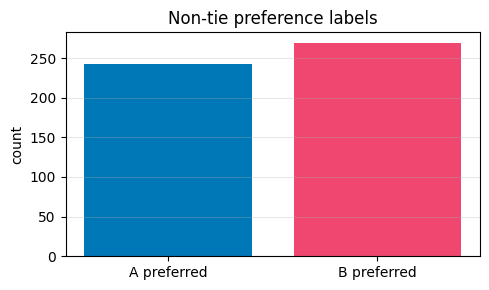

In [119]:
import os
import pickle
from pathlib import Path

import gym
import d4rl
from d4rl.offline_env import set_dataset_path
import matplotlib.pyplot as plt
import numpy as np

from JaxPref.reward_transform import qlearning_ant_dataset

# MC-DT-OPPO settings.
MCOPPO_SEG_LEN = QUERY_LEN
MCOPPO_CONTEXT_LEN = 25
MCOPPO_NUM_CONTEXTS = 4
MCOPPO_EMBED_DIM = 64
MCOPPO_HIDDEN_DIM = 128
MCOPPO_NUM_HEADS = 4
MCOPPO_ENCODER_LAYERS = 2
MCOPPO_POLICY_LAYERS = 2
MCOPPO_SELECTOR_LAYERS = 1

MCOPPO_HIM_BATCH_SIZE = 128
MCOPPO_PREF_BATCH_SIZE = 128
MCOPPO_ANCHOR_BATCH_SIZE = 128
MCOPPO_HIM_LR = 3e-4
MCOPPO_CONTEXT_LR = 3e-3
MCOPPO_POLICY_LR = 1e-4
MCOPPO_MARGIN = 1.0
MCOPPO_DIVERSITY_WEIGHT = 0.1
MCOPPO_SELECTOR_WEIGHT = 1.0
MCOPPO_PREFERRED_BC_WEIGHT = 1.0
MCOPPO_HIM_REG_WEIGHT = 0.2

MCOPPO_HIM_STEPS = 10_000
MCOPPO_CONTEXT_STEPS = 5_000
MCOPPO_POLICY_STEPS = 10_000
MCOPPO_LOG_INTERVAL = 500
MCOPPO_SAVE_INTERVAL = 5_000
MCOPPO_CKPT_DIR = NOTEBOOK_RUN_DIR / "mc_dt_oppo_goal"
MCOPPO_CKPT_DIR.mkdir(parents=True, exist_ok=True)

os.environ.update({
    "MCOPPO_CKPT_DIR": str(MCOPPO_CKPT_DIR),
    "MCOPPO_HIM_STEPS": str(MCOPPO_HIM_STEPS),
    "MCOPPO_CONTEXT_STEPS": str(MCOPPO_CONTEXT_STEPS),
    "MCOPPO_POLICY_STEPS": str(MCOPPO_POLICY_STEPS),
})

set_dataset_path(str(D4RL_DATASET_DIR))
mc_env_for_data = gym.make(D4RL_ENV)
mc_raw_dataset = mc_env_for_data.get_dataset()
mc_dataset = qlearning_ant_dataset(mc_env_for_data, mc_raw_dataset)

mc_obs_raw_all = np.asarray(mc_dataset["observations"], dtype=np.float32)
mc_act_all = np.clip(np.asarray(mc_dataset["actions"], dtype=np.float32), -1.0 + 1e-5, 1.0 - 1e-5)
mc_xy_all = np.asarray(mc_dataset.get("xys", mc_obs_raw_all[:, :2]), dtype=np.float32)
mc_goal_all = np.asarray(mc_dataset.get("goals", np.zeros((len(mc_obs_raw_all), 2))), dtype=np.float32)

# AntMaze-specific extension: add goal and goal-relative displacement.
# This keeps OPPO reward-free while giving the direct policy the navigation target.
MCOPPO_GOAL_SCALE = 25.0
mc_goal_features = mc_goal_all / MCOPPO_GOAL_SCALE
mc_delta_goal_features = (mc_goal_all - mc_xy_all) / MCOPPO_GOAL_SCALE
mc_obs_all = np.concatenate([mc_obs_raw_all, mc_goal_features, mc_delta_goal_features], axis=-1).astype(np.float32)
mc_obs_mean = mc_obs_all.mean(axis=0).astype(np.float32)
mc_obs_std = (mc_obs_all.std(axis=0) + 1e-6).astype(np.float32)
mc_obs_all_norm = ((mc_obs_all - mc_obs_mean) / mc_obs_std).astype(np.float32)

label_dir = REPO_DIR / "human_label" / D4RL_ENV
with open(label_dir / "indices_num1000", "rb") as f:
    mc_indices_a = np.asarray(pickle.load(f), dtype=np.int64)
with open(label_dir / "indices_2_num1000", "rb") as f:
    mc_indices_b = np.asarray(pickle.load(f), dtype=np.int64)
with open(label_dir / "label_human", "rb") as f:
    mc_labels_raw = np.asarray(pickle.load(f), dtype=np.int64).reshape(-1)

non_tie_mask = mc_labels_raw != -1
mc_indices_a = mc_indices_a[non_tie_mask]
mc_indices_b = mc_indices_b[non_tie_mask]
mc_pref_labels = mc_labels_raw[non_tie_mask].astype(np.int32)
if len(mc_pref_labels) == 0:
    raise RuntimeError("No non-tie preference labels are available.")


def collect_segments(array, starts, seq_len):
    offsets = np.arange(seq_len, dtype=np.int64)[None, :]
    return array[starts[:, None] + offsets].astype(np.float32)


def make_prev_actions(actions):
    prev = np.zeros_like(actions)
    prev[:, 1:, :] = actions[:, :-1, :]
    return prev.astype(np.float32)


def valid_sequence_starts(done_flags, seq_len):
    if len(done_flags) < seq_len:
        return np.array([], dtype=np.int64)
    window = np.ones(seq_len, dtype=np.int32)
    crosses = np.convolve(done_flags.astype(np.int32), window, mode="valid") > 0
    starts = np.flatnonzero(~crosses).astype(np.int64)
    if len(starts) == 0:
        starts = np.arange(0, len(done_flags) - seq_len + 1, dtype=np.int64)
    return starts


mc_pref_obs_a = collect_segments(mc_obs_all_norm, mc_indices_a, MCOPPO_SEG_LEN)
mc_pref_act_a = collect_segments(mc_act_all, mc_indices_a, MCOPPO_SEG_LEN)
mc_pref_obs_b = collect_segments(mc_obs_all_norm, mc_indices_b, MCOPPO_SEG_LEN)
mc_pref_act_b = collect_segments(mc_act_all, mc_indices_b, MCOPPO_SEG_LEN)
mc_pref_xy_a = collect_segments(mc_xy_all, mc_indices_a, MCOPPO_SEG_LEN)
mc_pref_xy_b = collect_segments(mc_xy_all, mc_indices_b, MCOPPO_SEG_LEN)

done_flags = np.asarray(mc_dataset.get("terminals", np.zeros(len(mc_obs_all), dtype=bool)), dtype=bool)
if "dones_bef" in mc_dataset:
    done_flags = np.logical_or(done_flags, np.asarray(mc_dataset["dones_bef"], dtype=bool))
mc_him_starts = valid_sequence_starts(done_flags, MCOPPO_CONTEXT_LEN)
mc_segment_starts = valid_sequence_starts(done_flags, MCOPPO_SEG_LEN)

split_rng = np.random.default_rng(SEED)
perm = split_rng.permutation(len(mc_pref_labels))
val_size = max(1, int(0.2 * len(perm)))
mc_val_pref_indices = perm[:val_size]
mc_train_pref_indices = perm[val_size:]
if len(mc_train_pref_indices) == 0:
    mc_train_pref_indices = mc_val_pref_indices.copy()

MCOPPO_DATA = {
    "obs_all_norm": mc_obs_all_norm,
    "act_all": mc_act_all,
    "xy_all": mc_xy_all,
    "goal_all": mc_goal_all,
    "obs_mean": mc_obs_mean,
    "obs_std": mc_obs_std,
    "him_starts": mc_him_starts,
    "segment_starts": mc_segment_starts,
    "pref_obs_a": mc_pref_obs_a,
    "pref_act_a": mc_pref_act_a,
    "pref_obs_b": mc_pref_obs_b,
    "pref_act_b": mc_pref_act_b,
    "pref_xy_a": mc_pref_xy_a,
    "pref_xy_b": mc_pref_xy_b,
    "pref_labels": mc_pref_labels,
    "train_pref_indices": mc_train_pref_indices.astype(np.int64),
    "val_pref_indices": mc_val_pref_indices.astype(np.int64),
}

label_counts = {int(k): int(v) for k, v in zip(*np.unique(mc_pref_labels, return_counts=True))}
train_counts = {int(k): int(v) for k, v in zip(*np.unique(mc_pref_labels[mc_train_pref_indices], return_counts=True))}
val_counts = {int(k): int(v) for k, v in zip(*np.unique(mc_pref_labels[mc_val_pref_indices], return_counts=True))}

print("MC-DT-OPPO data is ready.")
print("Dataset transitions:", len(mc_obs_all))
print("HIM windows:", len(mc_him_starts))
print("Full segment starts:", len(mc_segment_starts))
print("Preference pairs:", len(mc_pref_labels))
print("Train preference pairs:", len(mc_train_pref_indices))
print("Validation preference pairs:", len(mc_val_pref_indices))
print("Label counts:", label_counts)
print("Train label counts:", train_counts)
print("Validation label counts:", val_counts)
print("Feature dim:", mc_obs_all.shape[-1])
print("Checkpoint dir:", MCOPPO_CKPT_DIR)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["A preferred", "B preferred"], [label_counts.get(0, 0), label_counts.get(1, 0)], color=["#0077b6", "#ef476f"])
ax.set_title("Non-tie preference labels")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### 7.4 Batch Sampling and Initialization

- This cell defines the mini-batches used in the three training stages.
- Hindsight batches train the sequence policy to imitate dataset actions from trajectory history.
- Preference batches train contexts to separate preferred and non-preferred segments.
- Anchor batches connect preferred sub-trajectories to the selector and policy.
- The cell also initializes model parameters and optimizer states.


In [120]:
import time
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
from tqdm.auto import trange


def sample_him_batch(np_rng, batch_size=MCOPPO_HIM_BATCH_SIZE):
    starts = np_rng.choice(MCOPPO_DATA["him_starts"], size=batch_size, replace=True)
    offsets = np.arange(MCOPPO_CONTEXT_LEN, dtype=np.int64)[None, :]
    idx = starts[:, None] + offsets
    obs = MCOPPO_DATA["obs_all_norm"][idx]
    act = MCOPPO_DATA["act_all"][idx]
    return {
        "obs": jnp.asarray(obs),
        "act": jnp.asarray(act),
        "prev_act": jnp.asarray(make_prev_actions(act)),
    }


def build_pref_batch(indices):
    return {
        "obs_a": jnp.asarray(MCOPPO_DATA["pref_obs_a"][indices]),
        "act_a": jnp.asarray(MCOPPO_DATA["pref_act_a"][indices]),
        "obs_b": jnp.asarray(MCOPPO_DATA["pref_obs_b"][indices]),
        "act_b": jnp.asarray(MCOPPO_DATA["pref_act_b"][indices]),
        "labels": jnp.asarray(MCOPPO_DATA["pref_labels"][indices]),
    }


def sample_pref_batch(np_rng):
    indices = np_rng.choice(MCOPPO_DATA["train_pref_indices"], size=MCOPPO_PREF_BATCH_SIZE, replace=True)
    return build_pref_batch(indices)


def sample_anchor_batch(np_rng):
    indices = np_rng.choice(MCOPPO_DATA["train_pref_indices"], size=MCOPPO_ANCHOR_BATCH_SIZE, replace=True)
    labels = MCOPPO_DATA["pref_labels"][indices]
    obs_seg = np.where(labels[:, None, None] == 0, MCOPPO_DATA["pref_obs_a"][indices], MCOPPO_DATA["pref_obs_b"][indices])
    act_seg = np.where(labels[:, None, None] == 0, MCOPPO_DATA["pref_act_a"][indices], MCOPPO_DATA["pref_act_b"][indices])
    max_offset = MCOPPO_SEG_LEN - MCOPPO_CONTEXT_LEN + 1
    offsets = np_rng.integers(0, max_offset, size=len(indices))
    win_offsets = offsets[:, None] + np.arange(MCOPPO_CONTEXT_LEN, dtype=np.int64)[None, :]
    rows = np.arange(len(indices))[:, None]
    obs_win = obs_seg[rows, win_offsets]
    act_win = act_seg[rows, win_offsets]
    return {
        "seg_obs": jnp.asarray(obs_seg),
        "seg_act": jnp.asarray(act_seg),
        "obs": jnp.asarray(obs_win),
        "act": jnp.asarray(act_win),
        "prev_act": jnp.asarray(make_prev_actions(act_win)),
    }


obs_dim = MCOPPO_DATA["obs_all_norm"].shape[-1]
action_dim = MCOPPO_DATA["act_all"].shape[-1]
rng = jax.random.PRNGKey(SEED)
rng, MCDT_ENCODER_DEF, MCDT_POLICY_DEF, MCDT_SELECTOR_DEF, MCDT_PARAMS = init_mcdt_params(rng, obs_dim, action_dim)

MCDT_HIM_TX = optax.adam(MCOPPO_HIM_LR)
MCDT_CONTEXT_TX = optax.adam(MCOPPO_CONTEXT_LR)
MCDT_POLICY_TX = optax.adam(MCOPPO_POLICY_LR)
MCDT_HIM_OPT = MCDT_HIM_TX.init(MCDT_PARAMS)
MCDT_CONTEXT_OPT = MCDT_CONTEXT_TX.init(MCDT_PARAMS)
MCDT_POLICY_OPT = MCDT_POLICY_TX.init(MCDT_PARAMS)

print("MC-DT-OPPO models initialized.")
print("obs_dim:", obs_dim)
print("action_dim:", action_dim)
print("num_contexts:", MCOPPO_NUM_CONTEXTS)


MC-DT-OPPO models initialized.
obs_dim: 33
action_dim: 8
num_contexts: 4


### 7.5 Training Step Functions

- This cell defines one JAX update function for each training stage.
- Stage A trains encoder and policy with hindsight behavior cloning.
- Stage B updates the learned contexts using preference comparisons while keeping segment embeddings fixed.
- Stage C trains the selector and policy to choose contexts and imitate preferred behavior windows.


In [121]:
@jax.jit
def mcdt_him_step(params, opt_state, batch):
    def loss_fn(current_params):
        context = MCDT_ENCODER_DEF.apply({"params": current_params["encoder"]}, batch["obs"], batch["act"])
        pred_actions = MCDT_POLICY_DEF.apply(
            {"params": current_params["policy"]},
            batch["obs"],
            batch["prev_act"],
            context,
        )
        loss = action_mse(pred_actions, batch["act"])
        return loss, {"him_bc_loss": loss}

    (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    updates, new_opt_state = MCDT_HIM_TX.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    metrics["loss"] = loss
    return new_params, new_opt_state, metrics


@jax.jit
def mcdt_preference_metrics(params, pref_batch):
    z_a = MCDT_ENCODER_DEF.apply({"params": params["encoder"]}, pref_batch["obs_a"], pref_batch["act_a"])
    z_b = MCDT_ENCODER_DEF.apply({"params": params["encoder"]}, pref_batch["obs_b"], pref_batch["act_b"])
    is_a = pref_batch["labels"][:, None] == 0
    z_pos = jnp.where(is_a, z_a, z_b)
    z_neg = jnp.where(is_a, z_b, z_a)
    loss, acc, pos_dist, neg_dist, assignment = multi_context_preference_loss(
        params["contexts"], z_pos, z_neg, margin=MCOPPO_MARGIN
    )
    entropy, probs = context_usage_entropy(assignment, MCOPPO_NUM_CONTEXTS)
    return {
        "pref_loss": loss,
        "pref_acc": acc,
        "pos_dist": pos_dist,
        "neg_dist": neg_dist,
        "usage_entropy": entropy,
        "usage_probs": probs,
    }


@jax.jit
def mcdt_context_step(params, opt_state, pref_batch):
    def loss_fn(current_params):
        z_a = MCDT_ENCODER_DEF.apply({"params": current_params["encoder"]}, pref_batch["obs_a"], pref_batch["act_a"])
        z_b = MCDT_ENCODER_DEF.apply({"params": current_params["encoder"]}, pref_batch["obs_b"], pref_batch["act_b"])
        z_a = jax.lax.stop_gradient(z_a)
        z_b = jax.lax.stop_gradient(z_b)
        is_a = pref_batch["labels"][:, None] == 0
        z_pos = jnp.where(is_a, z_a, z_b)
        z_neg = jnp.where(is_a, z_b, z_a)
        pref_loss, pref_acc, pos_dist, neg_dist, assignment = multi_context_preference_loss(
            current_params["contexts"], z_pos, z_neg, margin=MCOPPO_MARGIN
        )
        diversity_loss = context_diversity_loss(current_params["contexts"])
        total_loss = pref_loss + MCOPPO_DIVERSITY_WEIGHT * diversity_loss
        entropy, probs = context_usage_entropy(assignment, MCOPPO_NUM_CONTEXTS)
        metrics = {
            "loss": total_loss,
            "pref_loss": pref_loss,
            "pref_acc": pref_acc,
            "pos_dist": pos_dist,
            "neg_dist": neg_dist,
            "diversity_loss": diversity_loss,
            "usage_entropy": entropy,
            "usage_probs": probs,
        }
        return total_loss, metrics

    (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    updates, new_opt_state = MCDT_CONTEXT_TX.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, metrics


@jax.jit
def mcdt_selector_policy_step(params, opt_state, anchor_batch, him_batch):
    def loss_fn(current_params):
        contexts = jax.lax.stop_gradient(l2_normalize(current_params["contexts"]))
        z_anchor = MCDT_ENCODER_DEF.apply({"params": current_params["encoder"]}, anchor_batch["seg_obs"], anchor_batch["seg_act"])
        z_anchor = jax.lax.stop_gradient(z_anchor)
        dist = jnp.sum((z_anchor[:, None, :] - contexts[None, :, :]) ** 2, axis=-1)
        target_context = jnp.argmin(dist, axis=1)

        logits = MCDT_SELECTOR_DEF.apply({"params": current_params["selector"]}, anchor_batch["obs"], anchor_batch["prev_act"])
        selector_loss = softmax_cross_entropy(logits, target_context)
        weights = jax.nn.softmax(logits, axis=-1)
        selected_context = weights @ contexts
        pred_pref_actions = MCDT_POLICY_DEF.apply(
            {"params": current_params["policy"]}, anchor_batch["obs"], anchor_batch["prev_act"], selected_context
        )
        preferred_bc_loss = action_mse(pred_pref_actions, anchor_batch["act"])

        him_context = MCDT_ENCODER_DEF.apply({"params": current_params["encoder"]}, him_batch["obs"], him_batch["act"])
        him_context = jax.lax.stop_gradient(him_context)
        pred_him_actions = MCDT_POLICY_DEF.apply(
            {"params": current_params["policy"]}, him_batch["obs"], him_batch["prev_act"], him_context
        )
        him_reg_loss = action_mse(pred_him_actions, him_batch["act"])
        total_loss = (
            MCOPPO_SELECTOR_WEIGHT * selector_loss
            + MCOPPO_PREFERRED_BC_WEIGHT * preferred_bc_loss
            + MCOPPO_HIM_REG_WEIGHT * him_reg_loss
        )
        selector_acc = jnp.mean((jnp.argmax(logits, axis=-1) == target_context).astype(jnp.float32))
        metrics = {
            "loss": total_loss,
            "selector_loss": selector_loss,
            "selector_acc": selector_acc,
            "preferred_bc_loss": preferred_bc_loss,
            "him_reg_loss": him_reg_loss,
        }
        return total_loss, metrics

    (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    updates, new_opt_state = MCDT_POLICY_TX.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, metrics


### 7.6 Three-Stage Training Run

- This cell runs the full MC-DT-OPPO training loop.
- It logs training and validation preference metrics at fixed intervals.
- It saves periodic and final checkpoints under `notebook_runs/.../mc_dt_oppo_goal`.
- The final plot marks the transitions between hindsight pretraining, context learning, and selector-policy anchoring.


Stage A: HIM pretraining


MC-DT HIM: 100%|███████████████████████| 10000/10000 [00:52<00:00, 191.53it/s]


Stage B: multi-context preference learning


MC-DT contexts: 100%|████████████████████| 5000/5000 [00:24<00:00, 202.00it/s]


Stage C: context selector and policy anchoring


MC-DT policy: 100%|████████████████████| 10000/10000 [01:24<00:00, 117.70it/s]


Training complete.
Elapsed minutes: 2.7
Saved checkpoint: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_final.pkl


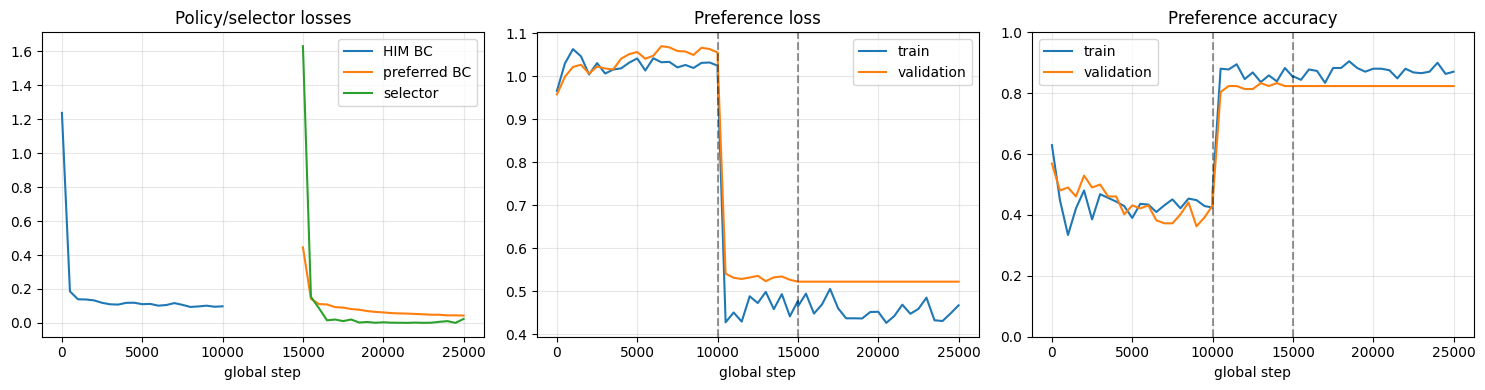

In [122]:
def evaluate_pref_split(params, np_rng):
    train_size = min(512, len(MCOPPO_DATA["train_pref_indices"]))
    train_indices = np_rng.choice(MCOPPO_DATA["train_pref_indices"], size=train_size, replace=True)
    val_indices = MCOPPO_DATA["val_pref_indices"]
    train_metrics = mcdt_preference_metrics(params, build_pref_batch(train_indices))
    val_metrics = mcdt_preference_metrics(params, build_pref_batch(val_indices))
    return {
        "train_pref_loss": float(jax.device_get(train_metrics["pref_loss"])),
        "train_pref_acc": float(jax.device_get(train_metrics["pref_acc"])),
        "val_pref_loss": float(jax.device_get(val_metrics["pref_loss"])),
        "val_pref_acc": float(jax.device_get(val_metrics["pref_acc"])),
        "usage_probs": np.asarray(jax.device_get(val_metrics["usage_probs"])).tolist(),
    }


def save_mcdt_checkpoint(params, opt_states, step, history, tag="latest"):
    ckpt = {
        "params": jax.device_get(params),
        "opt_state": jax.device_get(opt_states),
        "step": int(step),
        "history": history,
        "config": {
            "env": D4RL_ENV,
            "seed": SEED,
            "seg_len": MCOPPO_SEG_LEN,
            "context_len": MCOPPO_CONTEXT_LEN,
            "num_contexts": MCOPPO_NUM_CONTEXTS,
            "embed_dim": MCOPPO_EMBED_DIM,
            "hidden_dim": MCOPPO_HIDDEN_DIM,
            "num_heads": MCOPPO_NUM_HEADS,
            "encoder_layers": MCOPPO_ENCODER_LAYERS,
            "policy_layers": MCOPPO_POLICY_LAYERS,
            "selector_layers": MCOPPO_SELECTOR_LAYERS,
        },
        "obs_mean": MCOPPO_DATA["obs_mean"],
        "obs_std": MCOPPO_DATA["obs_std"],
    }
    path = MCOPPO_CKPT_DIR / f"mcdt_oppo_{tag}.pkl"
    with open(path, "wb") as f:
        pickle.dump(ckpt, f)
    with open(MCOPPO_CKPT_DIR / "mcdt_oppo_latest.pkl", "wb") as f:
        pickle.dump(ckpt, f)
    return path


def current_opt_states():
    return {"him": MCDT_HIM_OPT, "context": MCDT_CONTEXT_OPT, "policy": MCDT_POLICY_OPT}


np_rng = np.random.default_rng(SEED)
MCDT_HISTORY = []
global_step = 0
start_time = time.time()

print("Stage A: HIM pretraining")
for stage_step in trange(1, MCOPPO_HIM_STEPS + 1, desc="MC-DT HIM"):
    global_step += 1
    MCDT_PARAMS, MCDT_HIM_OPT, metrics = mcdt_him_step(MCDT_PARAMS, MCDT_HIM_OPT, sample_him_batch(np_rng))
    if stage_step == 1 or stage_step % MCOPPO_LOG_INTERVAL == 0:
        row = {key: float(jax.device_get(value)) for key, value in metrics.items() if key != "usage_probs"}
        row.update(evaluate_pref_split(MCDT_PARAMS, np_rng))
        row.update({"phase": "him", "global_step": global_step, "stage_step": stage_step})
        MCDT_HISTORY.append(row)
    if global_step % MCOPPO_SAVE_INTERVAL == 0:
        save_mcdt_checkpoint(MCDT_PARAMS, current_opt_states(), global_step, MCDT_HISTORY, tag=f"step_{global_step}")

print("Stage B: multi-context preference learning")
for stage_step in trange(1, MCOPPO_CONTEXT_STEPS + 1, desc="MC-DT contexts"):
    global_step += 1
    MCDT_PARAMS, MCDT_CONTEXT_OPT, metrics = mcdt_context_step(MCDT_PARAMS, MCDT_CONTEXT_OPT, sample_pref_batch(np_rng))
    if stage_step == 1 or stage_step % MCOPPO_LOG_INTERVAL == 0:
        row = {key: float(jax.device_get(value)) for key, value in metrics.items() if key != "usage_probs"}
        row.update(evaluate_pref_split(MCDT_PARAMS, np_rng))
        row.update({"phase": "contexts", "global_step": global_step, "stage_step": stage_step})
        MCDT_HISTORY.append(row)
    if global_step % MCOPPO_SAVE_INTERVAL == 0:
        save_mcdt_checkpoint(MCDT_PARAMS, current_opt_states(), global_step, MCDT_HISTORY, tag=f"step_{global_step}")

print("Stage C: context selector and policy anchoring")
for stage_step in trange(1, MCOPPO_POLICY_STEPS + 1, desc="MC-DT policy"):
    global_step += 1
    MCDT_PARAMS, MCDT_POLICY_OPT, metrics = mcdt_selector_policy_step(
        MCDT_PARAMS, MCDT_POLICY_OPT, sample_anchor_batch(np_rng), sample_him_batch(np_rng)
    )
    if stage_step == 1 or stage_step % MCOPPO_LOG_INTERVAL == 0:
        row = {key: float(jax.device_get(value)) for key, value in metrics.items() if key != "usage_probs"}
        row.update(evaluate_pref_split(MCDT_PARAMS, np_rng))
        row.update({"phase": "policy", "global_step": global_step, "stage_step": stage_step})
        MCDT_HISTORY.append(row)
    if global_step % MCOPPO_SAVE_INTERVAL == 0:
        save_mcdt_checkpoint(MCDT_PARAMS, current_opt_states(), global_step, MCDT_HISTORY, tag=f"step_{global_step}")

final_path = save_mcdt_checkpoint(MCDT_PARAMS, current_opt_states(), global_step, MCDT_HISTORY, tag="final")
os.environ["MCDT_OPPO_CKPT_PATH"] = str(final_path)
print("Training complete.")
print("Elapsed minutes:", round((time.time() - start_time) / 60.0, 2))
print("Saved checkpoint:", final_path)

if MCDT_HISTORY:
    steps = [row["global_step"] for row in MCDT_HISTORY]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    him_rows = [row for row in MCDT_HISTORY if "him_bc_loss" in row]
    policy_rows = [row for row in MCDT_HISTORY if "preferred_bc_loss" in row]
    if him_rows:
        axes[0].plot([row["global_step"] for row in him_rows], [row["him_bc_loss"] for row in him_rows], label="HIM BC")
    if policy_rows:
        axes[0].plot([row["global_step"] for row in policy_rows], [row["preferred_bc_loss"] for row in policy_rows], label="preferred BC")
        axes[0].plot([row["global_step"] for row in policy_rows], [row["selector_loss"] for row in policy_rows], label="selector")
    axes[0].set_title("Policy/selector losses")
    axes[0].set_xlabel("global step")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(steps, [row["train_pref_loss"] for row in MCDT_HISTORY], label="train")
    axes[1].plot(steps, [row["val_pref_loss"] for row in MCDT_HISTORY], label="validation")
    axes[1].axvline(MCOPPO_HIM_STEPS, color="black", linestyle="--", alpha=0.4)
    axes[1].axvline(MCOPPO_HIM_STEPS + MCOPPO_CONTEXT_STEPS, color="black", linestyle="--", alpha=0.4)
    axes[1].set_title("Preference loss")
    axes[1].set_xlabel("global step")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(steps, [row["train_pref_acc"] for row in MCDT_HISTORY], label="train")
    axes[2].plot(steps, [row["val_pref_acc"] for row in MCDT_HISTORY], label="validation")
    axes[2].axvline(MCOPPO_HIM_STEPS, color="black", linestyle="--", alpha=0.4)
    axes[2].axvline(MCOPPO_HIM_STEPS + MCOPPO_CONTEXT_STEPS, color="black", linestyle="--", alpha=0.4)
    axes[2].set_title("Preference accuracy")
    axes[2].set_xlabel("global step")
    axes[2].set_ylim(0.0, 1.0)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    plt.tight_layout()
    plt.show()


### 7.7 Context Embedding Visualization

- This cell visualizes whether learned contexts separate preference-relevant trajectory embeddings.
- PCA projects preferred segments, non-preferred segments, and context vectors into two dimensions.
- The distance diagnostic checks whether preferred segments are closer to some context than non-preferred segments.
- The usage plot shows whether contexts are shared or whether one context dominates all preference assignments.


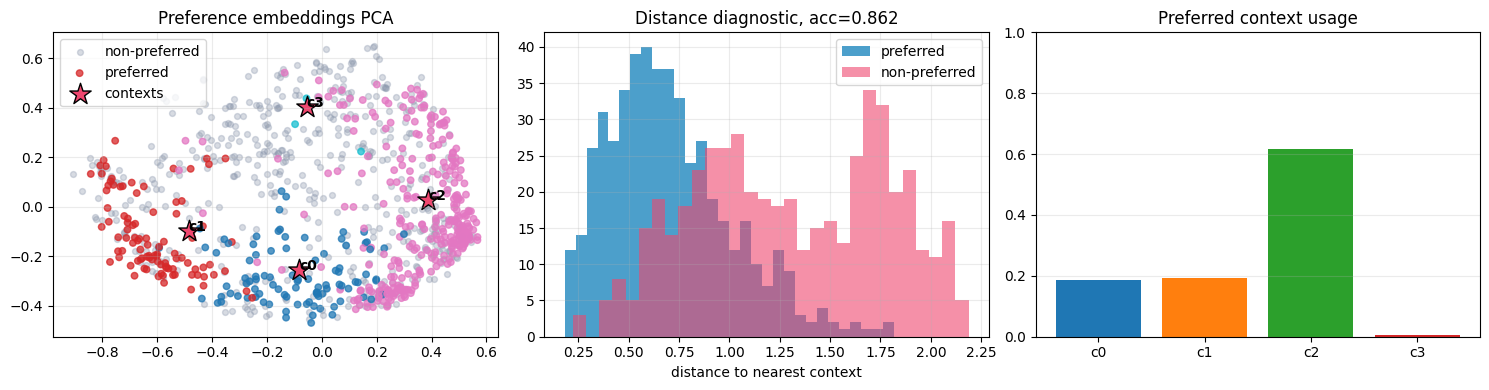

Validation-like preference distance accuracy: 0.862
Mean preferred nearest distance: 0.7035
Mean non-preferred nearest distance: 1.3004
Context usage: {'c0': 0.186, 'c1': 0.192, 'c2': 0.616, 'c3': 0.006}


In [123]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

if "MCDT_PARAMS" not in globals():
    ckpt_path = Path(os.environ.get("MCDT_OPPO_CKPT_PATH", MCOPPO_CKPT_DIR / "mcdt_oppo_latest.pkl"))
    if not ckpt_path.exists():
        raise FileNotFoundError("Run MC-DT-OPPO training before embedding visualization.")
    with open(ckpt_path, "rb") as f:
        ckpt = pickle.load(f)
    MCDT_PARAMS = ckpt["params"]

viz_count = min(500, len(MCOPPO_DATA["pref_labels"]))
viz_indices = np.linspace(0, len(MCOPPO_DATA["pref_labels"]) - 1, viz_count, dtype=np.int64)
viz_batch = build_pref_batch(viz_indices)
viz_labels = MCOPPO_DATA["pref_labels"][viz_indices]

z_a = MCDT_ENCODER_DEF.apply({"params": MCDT_PARAMS["encoder"]}, viz_batch["obs_a"], viz_batch["act_a"])
z_b = MCDT_ENCODER_DEF.apply({"params": MCDT_PARAMS["encoder"]}, viz_batch["obs_b"], viz_batch["act_b"])
z_a = np.asarray(jax.device_get(z_a))
z_b = np.asarray(jax.device_get(z_b))
contexts = np.asarray(jax.device_get(l2_normalize(jnp.asarray(MCDT_PARAMS["contexts"]))))

prefer_a = viz_labels[:, None] == 0
z_pos = np.where(prefer_a, z_a, z_b)
z_neg = np.where(prefer_a, z_b, z_a)
pos_dist = np.sum((z_pos[:, None, :] - contexts[None, :, :]) ** 2, axis=-1)
neg_dist = np.sum((z_neg[:, None, :] - contexts[None, :, :]) ** 2, axis=-1)
assignments = np.argmin(pos_dist, axis=1)
pref_acc = float(np.mean(np.min(pos_dist, axis=1) < np.min(neg_dist, axis=1)))
usage = np.bincount(assignments, minlength=MCOPPO_NUM_CONTEXTS) / len(assignments)

embeddings = np.concatenate([z_pos, z_neg, contexts], axis=0)
centered = embeddings - embeddings.mean(axis=0, keepdims=True)
_, _, vh = np.linalg.svd(centered, full_matrices=False)
coords = centered @ vh[:2].T
pos_xy = coords[:viz_count]
neg_xy = coords[viz_count:2 * viz_count]
context_xy = coords[2 * viz_count:]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(neg_xy[:, 0], neg_xy[:, 1], s=18, alpha=0.35, color="#8d99ae", label="non-preferred")
axes[0].scatter(pos_xy[:, 0], pos_xy[:, 1], s=22, alpha=0.75, c=assignments, cmap="tab10", label="preferred")
axes[0].scatter(context_xy[:, 0], context_xy[:, 1], s=260, marker="*", color="#ef476f", edgecolor="black", label="contexts")
for context_idx, point in enumerate(context_xy):
    axes[0].text(point[0], point[1], f"c{context_idx}", fontsize=10, weight="bold")
axes[0].set_title("Preference embeddings PCA")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].hist(np.min(pos_dist, axis=1), bins=30, alpha=0.7, label="preferred", color="#0077b6")
axes[1].hist(np.min(neg_dist, axis=1), bins=30, alpha=0.6, label="non-preferred", color="#ef476f")
axes[1].set_title(f"Distance diagnostic, acc={pref_acc:.3f}")
axes[1].set_xlabel("distance to nearest context")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

axes[2].bar([f"c{i}" for i in range(MCOPPO_NUM_CONTEXTS)], usage, color=plt.cm.tab10(np.arange(MCOPPO_NUM_CONTEXTS)))
axes[2].set_ylim(0.0, 1.0)
axes[2].set_title("Preferred context usage")
axes[2].grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("Validation-like preference distance accuracy:", round(pref_acc, 4))
print("Mean preferred nearest distance:", round(float(np.min(pos_dist, axis=1).mean()), 4))
print("Mean non-preferred nearest distance:", round(float(np.min(neg_dist, axis=1).mean()), 4))
print("Context usage:", {f"c{i}": round(float(value), 4) for i, value in enumerate(usage)})


### 7.8 Checkpoint Selection

- This cell selects the MC-DT-OPPO checkpoint used by rollout and evaluation cells.
- It prefers `mcdt_oppo_latest.pkl` when available and otherwise falls back to the newest matching checkpoint.
- The selected path is exported as `MCDT_OPPO_CKPT_PATH` so later cells use the same model.


In [124]:
import os
from pathlib import Path

mc_ckpt_dir = Path(os.environ.get("MCOPPO_CKPT_DIR", str(NOTEBOOK_RUN_DIR / "mc_dt_oppo")))
latest_mc_ckpt = mc_ckpt_dir / "mcdt_oppo_latest.pkl"
all_mc_ckpts = sorted(mc_ckpt_dir.glob("mcdt_oppo_*.pkl"), key=lambda p: p.stat().st_mtime) if mc_ckpt_dir.exists() else []

if latest_mc_ckpt.exists():
    MCDT_OPPO_CKPT_PATH = latest_mc_ckpt
elif all_mc_ckpts:
    MCDT_OPPO_CKPT_PATH = all_mc_ckpts[-1]
else:
    MCDT_OPPO_CKPT_PATH = None
    os.environ.pop("MCDT_OPPO_CKPT_PATH", None)

print("MC-DT-OPPO checkpoint dir:", mc_ckpt_dir)
if MCDT_OPPO_CKPT_PATH is None:
    print("No MC-DT-OPPO checkpoint found. Run the training cell first.")
else:
    os.environ["MCDT_OPPO_CKPT_PATH"] = str(MCDT_OPPO_CKPT_PATH)
    print("Using MC-DT-OPPO checkpoint:", MCDT_OPPO_CKPT_PATH)
    print("Recent checkpoints:")
    for path in all_mc_ckpts[-5:]:
        print(" ", path)


MC-DT-OPPO checkpoint dir: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal
Using MC-DT-OPPO checkpoint: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_latest.pkl
Recent checkpoints:
  /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_step_15000.pkl
  /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_step_20000.pkl
  /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_step_25000.pkl
  /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_final.pkl
  /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_latest.pkl


### 7.9 Rollout Visualization

- This cell runs one deterministic MC-DT-OPPO rollout in AntMaze.
- At every step, the selector chooses one of the learned contexts from the recent history window.
- The trajectory is colored by selected context, making it possible to inspect whether the policy changes navigation mode across maze regions.
- In the observed rollout, contexts switch along the path rather than staying fixed, which is the main qualitative signal of the multi-context design.


Compiling MC-DT-OPPO action function once...
Action function is ready.


Loaded MC-DT-OPPO checkpoint: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_latest.pkl
Rollout steps: 870
Raw return: 1.0
Episode info: {'success': 100.0, 'return': 100.0, 'length': 870, 'duration': 6.7505340576171875}
Evaluation target goal: [20.532972 21.059166]
Context usage in rollout: {'c0': 478, 'c1': 229, 'c2': 163, 'c3': 0}


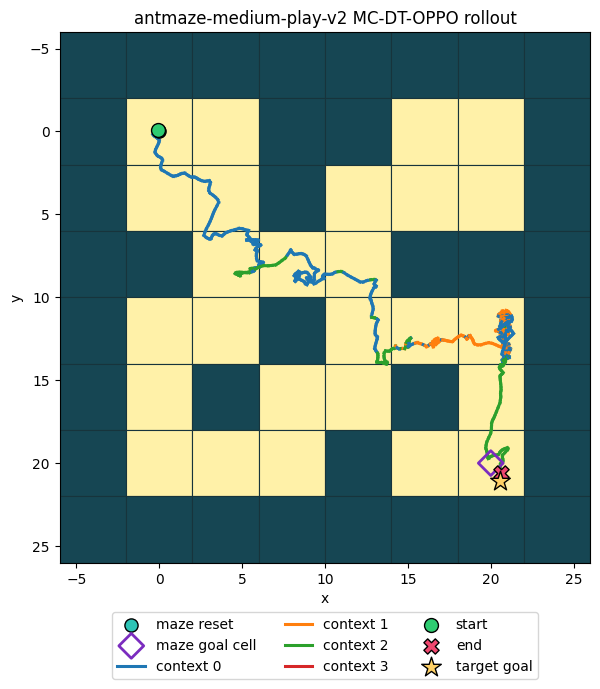

Saved rollout figure: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_rollout.png


In [135]:
import os
import pickle
from pathlib import Path

import gym
import d4rl
from d4rl.offline_env import set_dataset_path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from tqdm.auto import trange

import wrappers

mc_ckpt_value = os.environ.get("MCDT_OPPO_CKPT_PATH", "").strip()
if not mc_ckpt_value:
    fallback = Path(os.environ.get("MCOPPO_CKPT_DIR", str(NOTEBOOK_RUN_DIR / "mc_dt_oppo_goal"))) / "mcdt_oppo_latest.pkl"
    if fallback.exists():
        mc_ckpt_value = str(fallback)
        os.environ["MCDT_OPPO_CKPT_PATH"] = mc_ckpt_value
    else:
        raise FileNotFoundError("MCDT_OPPO_CKPT_PATH is empty. Run checkpoint selection first.")

mc_ckpt_path = Path(mc_ckpt_value).expanduser()
with open(mc_ckpt_path, "rb") as f:
    mc_ckpt = pickle.load(f)
mc_cfg = mc_ckpt["config"]
mc_params = mc_ckpt["params"]
mc_obs_mean = np.asarray(mc_ckpt["obs_mean"], dtype=np.float32)
mc_obs_std = np.asarray(mc_ckpt["obs_std"], dtype=np.float32)

set_dataset_path(str(D4RL_DATASET_DIR))
env = gym.make(D4RL_ENV)
env = wrappers.EpisodeMonitor(env)
env = wrappers.SinglePrecision(env)
env.seed(SEED)
env.action_space.seed(SEED)
env.observation_space.seed(SEED)
obs_dim = int(mc_obs_mean.shape[0])
action_dim = env.action_space.shape[-1]
MCOPPO_GOAL_SCALE = 25.0

policy_def = MCDTPolicy(env.action_space.shape[-1], mc_cfg["hidden_dim"], mc_cfg["embed_dim"], mc_cfg["policy_layers"], mc_cfg["num_heads"], mc_cfg["context_len"])
selector_def = MCDTContextSelector(mc_cfg["num_contexts"], mc_cfg["hidden_dim"], mc_cfg["selector_layers"], mc_cfg["num_heads"], mc_cfg["context_len"])
contexts = l2_normalize(jnp.asarray(mc_params["contexts"]))


@jax.jit
def mcdt_policy_apply(params, contexts, obs_window, prev_window):
    logits = selector_def.apply(
        {"params": params["selector"]},
        obs_window[None, :, :],
        prev_window[None, :, :],
    )
    weights = jax.nn.softmax(logits, axis=-1)
    selected_context = weights @ contexts
    pred_actions = policy_def.apply(
        {"params": params["policy"]},
        obs_window[None, :, :],
        prev_window[None, :, :],
        selected_context,
    )
    action = pred_actions[0, -1]
    context_id = jnp.argmax(logits, axis=-1)[0]
    return action, context_id


print("Compiling MC-DT-OPPO action function once...")
_dummy_obs = jnp.zeros((MCOPPO_CONTEXT_LEN, obs_dim), dtype=jnp.float32)
_dummy_prev = jnp.zeros((MCOPPO_CONTEXT_LEN, action_dim), dtype=jnp.float32)
_warmup_action, _ = mcdt_policy_apply(mc_params, contexts, _dummy_obs, _dummy_prev)
jax.block_until_ready(_warmup_action)
print("Action function is ready.")


def walk_envs(env):
    current = env
    while True:
        yield current
        if not hasattr(current, "env"):
            break
        current = current.env


def extract_xy(env, observation):
    for current in walk_envs(env):
        if hasattr(current, "get_xy"):
            try:
                return np.asarray(current.get_xy(), dtype=np.float32)
            except Exception:
                pass
    return np.asarray(observation[:2], dtype=np.float32)


def extract_goal(env):
    for current in walk_envs(env):
        for attr in ["target_goal", "goal", "_goal"]:
            if hasattr(current, attr):
                value = getattr(current, attr)
                if value is not None:
                    value = np.asarray(value, dtype=np.float32).reshape(-1)
                    if len(value) >= 2:
                        return value[:2]
    return None


def make_eval_feature(env, observation, goal):
    xy = extract_xy(env, observation)
    if goal is None:
        goal = np.zeros(2, dtype=np.float32)
    goal = np.asarray(goal, dtype=np.float32)[:2]
    return np.concatenate([
        np.asarray(observation, dtype=np.float32),
        goal / MCOPPO_GOAL_SCALE,
        (goal - xy) / MCOPPO_GOAL_SCALE,
    ]).astype(np.float32)


def mcdt_action_from_history(obs_history, action_history):
    obs_window = np.zeros((MCOPPO_CONTEXT_LEN, obs_dim), dtype=np.float32)
    prev_window = np.zeros((MCOPPO_CONTEXT_LEN, action_dim), dtype=np.float32)
    length = min(len(obs_history), MCOPPO_CONTEXT_LEN)
    obs_window[-length:] = np.asarray(obs_history[-length:], dtype=np.float32)
    if len(action_history) > 0:
        prev_length = min(len(action_history), MCOPPO_CONTEXT_LEN - 1)
        prev_window[-prev_length:] = np.asarray(action_history[-prev_length:], dtype=np.float32)
    obs_window = ((obs_window - mc_obs_mean) / mc_obs_std).astype(np.float32)
    action, context_id = mcdt_policy_apply(
        mc_params,
        contexts,
        jnp.asarray(obs_window),
        jnp.asarray(prev_window),
    )
    action = np.asarray(jax.device_get(action))
    context_id = int(np.asarray(jax.device_get(context_id)))
    return np.clip(action, env.action_space.low, env.action_space.high), context_id


observation = env.reset()
goal = extract_goal(env)
obs_history = [make_eval_feature(env, observation, goal)]
action_history = []
xys = [extract_xy(env, observation)]
context_ids = []
rewards = []
infos = []
max_rollout_steps = getattr(env.env, "_max_episode_steps", 1000)

for step in trange(max_rollout_steps, desc="MC-DT rollout", leave=False):
    action, context_id = mcdt_action_from_history(obs_history, action_history)
    observation, reward, done, info = env.step(action)
    obs_history.append(make_eval_feature(env, observation, goal))
    action_history.append(np.asarray(action, dtype=np.float32))
    xys.append(extract_xy(env, observation))
    context_ids.append(context_id)
    rewards.append(float(reward))
    infos.append(info)
    if done:
        break

xys = np.asarray(xys)
context_ids = np.asarray(context_ids, dtype=np.int64)
episode_info = infos[-1].get("episode", {}) if infos else {}
print("Loaded MC-DT-OPPO checkpoint:", mc_ckpt_path)
print("Rollout steps:", len(rewards))
print("Raw return:", float(np.sum(rewards)))
if episode_info:
    print("Episode info:", episode_info)
if goal is not None:
    print("Evaluation target goal:", goal)
print("Context usage in rollout:", {f"c{i}": int(np.sum(context_ids == i)) for i in range(MCOPPO_NUM_CONTEXTS)})

try:
    from d4rl.locomotion.maze_env import BIG_MAZE_TEST, RESET, GOAL
    maze_layout = BIG_MAZE_TEST
except Exception:
    RESET = "r"
    GOAL = "g"
    maze_layout = [[1,1,1,1,1,1,1,1],[1,RESET,0,1,1,0,0,1],[1,0,0,1,0,0,0,1],[1,1,0,0,0,1,1,1],[1,0,0,1,0,0,0,1],[1,0,1,0,0,1,0,1],[1,0,0,0,1,0,GOAL,1],[1,1,1,1,1,1,1,1]]
maze = np.asarray(maze_layout, dtype=object)
maze_scale = 4.0
reset_row, reset_col = np.argwhere(maze == RESET)[0]
init_torso_x = reset_col * maze_scale
init_torso_y = reset_row * maze_scale
n_rows, n_cols = maze.shape
x_min = -init_torso_x - maze_scale / 2
x_max = (n_cols - 1) * maze_scale - init_torso_x + maze_scale / 2
y_min = -init_torso_y - maze_scale / 2
y_max = (n_rows - 1) * maze_scale - init_torso_y + maze_scale / 2

def cell_center(row, col):
    return col * maze_scale - init_torso_x, row * maze_scale - init_torso_y

def draw_static_antmaze(ax):
    ax.set_facecolor("#f5d99b")
    for row in range(n_rows):
        for col in range(n_cols):
            value = maze[row, col]
            x, y = cell_center(row, col)
            color = "#164653" if value == 1 else "#fff1a8"
            ax.add_patch(patches.Rectangle((x - maze_scale / 2, y - maze_scale / 2), maze_scale, maze_scale, facecolor=color, edgecolor="#17343c", linewidth=0.8))
            if value == RESET:
                ax.scatter(x, y, s=90, marker="o", color="#2ec4b6", edgecolor="black", zorder=5, label="maze reset")
            if value == GOAL:
                ax.scatter(x, y, s=160, marker="D", facecolor="none", edgecolor="#7b2cbf", linewidth=2.0, zorder=5, label="maze goal cell")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig, ax = plt.subplots(figsize=(7, 7))
draw_static_antmaze(ax)
colors = plt.cm.tab10(np.arange(MCOPPO_NUM_CONTEXTS))
for i in range(len(xys) - 1):
    cid = int(context_ids[i]) if i < len(context_ids) else 0
    ax.plot(xys[i:i + 2, 0], xys[i:i + 2, 1], color=colors[cid], linewidth=2.2)
for cid in range(MCOPPO_NUM_CONTEXTS):
    ax.plot([], [], color=colors[cid], linewidth=2.2, label=f"context {cid}")
ax.scatter(xys[0, 0], xys[0, 1], s=100, color="#2ecc71", edgecolor="black", zorder=6, label="start")
ax.scatter(xys[-1, 0], xys[-1, 1], s=120, color="#ef476f", marker="X", edgecolor="black", zorder=6, label="end")
if goal is not None:
    ax.scatter(goal[0], goal[1], s=220, marker="*", color="#ffd166", edgecolor="black", zorder=7, label="target goal")
ax.set_title(f"{D4RL_ENV} MC-DT-OPPO rollout")
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.tight_layout()
rollout_path = Path(os.environ.get("MCOPPO_CKPT_DIR", str(NOTEBOOK_RUN_DIR / "mc_dt_oppo_goal"))) / "mcdt_oppo_rollout.png"
fig.savefig(rollout_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved rollout figure:", rollout_path)


### 7.10 Quantitative Evaluation

- This cell evaluates MC-DT-OPPO over multiple AntMaze episodes using the same return-style metrics used for PT + IQL.
- It records return, success, episode length, sparse return, and context usage during evaluation.
- The comparison plot places PT + IQL next to MC-DT-OPPO, while the context-usage plot summarizes how often each context is selected.
- The saved summary files are used for the final interpretation cell below.


Compiling MC-DT-OPPO action function once...
Action function is ready.


MC-DT-OPPO evaluation: 100%|████████████████| 100/100 [12:07<00:00,  7.27s/it]


MC-DT-OPPO quantitative evaluation
Checkpoint: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_latest.pkl
return: 23.000 +/- 42.083
success: 23.000 +/- 42.083
length: 934.480 +/- 143.558
raw_return: 0.230 +/- 0.421
Context counts: {'c0': 57097, 'c1': 9901, 'c2': 26173, 'c3': 277}
Saved summary: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_eval_summary.json
Saved episodes: /home/KHJ/AI611/PreferenceTransformer/notebook_runs/team16_antmaze_medium_play_pt_baseline_s42/mc_dt_oppo_goal/mcdt_oppo_eval_episodes.csv
PT+IQL final eval return from progress.txt: 73.0


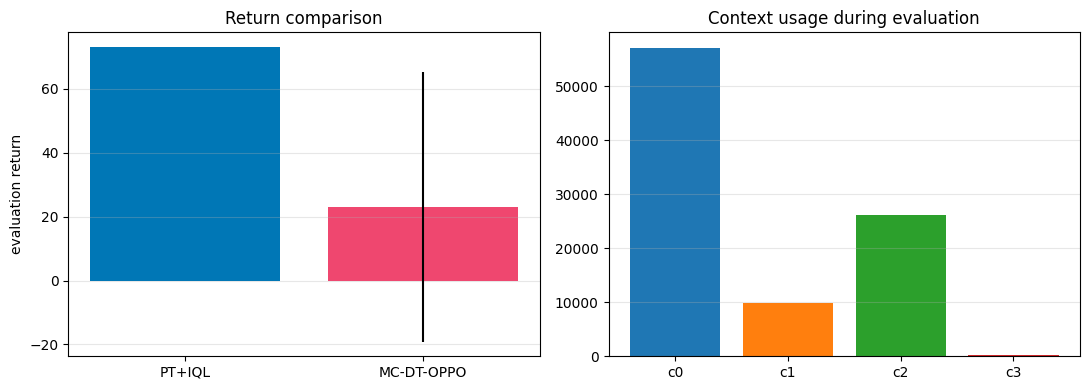

In [136]:
import csv
import json
import os
import pickle
from pathlib import Path

import gym
import d4rl
from d4rl.offline_env import set_dataset_path
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import trange

import wrappers

MCOPPO_EVAL_EPISODES = EVAL_EPISODES
mc_ckpt_value = os.environ.get("MCDT_OPPO_CKPT_PATH", "").strip()
if not mc_ckpt_value:
    fallback = Path(os.environ.get("MCOPPO_CKPT_DIR", str(NOTEBOOK_RUN_DIR / "mc_dt_oppo_goal"))) / "mcdt_oppo_latest.pkl"
    if fallback.exists():
        mc_ckpt_value = str(fallback)
        os.environ["MCDT_OPPO_CKPT_PATH"] = mc_ckpt_value
    else:
        raise FileNotFoundError("MCDT_OPPO_CKPT_PATH is empty. Run checkpoint selection first.")

mc_ckpt_path = Path(mc_ckpt_value).expanduser()
with open(mc_ckpt_path, "rb") as f:
    mc_ckpt = pickle.load(f)
mc_cfg = mc_ckpt["config"]
mc_params = mc_ckpt["params"]
mc_obs_mean = np.asarray(mc_ckpt["obs_mean"], dtype=np.float32)
mc_obs_std = np.asarray(mc_ckpt["obs_std"], dtype=np.float32)

set_dataset_path(str(D4RL_DATASET_DIR))
env = gym.make(D4RL_ENV)
env = wrappers.EpisodeMonitor(env)
env = wrappers.SinglePrecision(env)
env.seed(SEED)
env.action_space.seed(SEED)
env.observation_space.seed(SEED)
obs_dim = int(mc_obs_mean.shape[0])
action_dim = env.action_space.shape[-1]
MCOPPO_GOAL_SCALE = 25.0

policy_def = MCDTPolicy(env.action_space.shape[-1], mc_cfg["hidden_dim"], mc_cfg["embed_dim"], mc_cfg["policy_layers"], mc_cfg["num_heads"], mc_cfg["context_len"])
selector_def = MCDTContextSelector(mc_cfg["num_contexts"], mc_cfg["hidden_dim"], mc_cfg["selector_layers"], mc_cfg["num_heads"], mc_cfg["context_len"])
contexts = l2_normalize(jnp.asarray(mc_params["contexts"]))


@jax.jit
def mcdt_policy_apply(params, contexts, obs_window, prev_window):
    logits = selector_def.apply(
        {"params": params["selector"]},
        obs_window[None, :, :],
        prev_window[None, :, :],
    )
    weights = jax.nn.softmax(logits, axis=-1)
    selected_context = weights @ contexts
    pred_actions = policy_def.apply(
        {"params": params["policy"]},
        obs_window[None, :, :],
        prev_window[None, :, :],
        selected_context,
    )
    action = pred_actions[0, -1]
    context_id = jnp.argmax(logits, axis=-1)[0]
    return action, context_id


print("Compiling MC-DT-OPPO action function once...")
_dummy_obs = jnp.zeros((MCOPPO_CONTEXT_LEN, obs_dim), dtype=jnp.float32)
_dummy_prev = jnp.zeros((MCOPPO_CONTEXT_LEN, action_dim), dtype=jnp.float32)
_warmup_action, _ = mcdt_policy_apply(mc_params, contexts, _dummy_obs, _dummy_prev)
jax.block_until_ready(_warmup_action)
print("Action function is ready.")
max_episode_steps = getattr(env.env, "_max_episode_steps", 1000)


def eval_action(obs_history, action_history):
    obs_window = np.zeros((MCOPPO_CONTEXT_LEN, obs_dim), dtype=np.float32)
    prev_window = np.zeros((MCOPPO_CONTEXT_LEN, action_dim), dtype=np.float32)
    length = min(len(obs_history), MCOPPO_CONTEXT_LEN)
    obs_window[-length:] = np.asarray(obs_history[-length:], dtype=np.float32)
    if len(action_history) > 0:
        prev_length = min(len(action_history), MCOPPO_CONTEXT_LEN - 1)
        prev_window[-prev_length:] = np.asarray(action_history[-prev_length:], dtype=np.float32)
    obs_window = ((obs_window - mc_obs_mean) / mc_obs_std).astype(np.float32)
    action, context_id = mcdt_policy_apply(
        mc_params,
        contexts,
        jnp.asarray(obs_window),
        jnp.asarray(prev_window),
    )
    action = np.asarray(jax.device_get(action))
    context_id = int(np.asarray(jax.device_get(context_id)))
    return np.clip(action, env.action_space.low, env.action_space.high), context_id


episode_rows = []
context_counts_total = np.zeros(MCOPPO_NUM_CONTEXTS, dtype=np.int64)
for episode_idx in trange(MCOPPO_EVAL_EPISODES, desc="MC-DT-OPPO evaluation"):
    observation = env.reset()
    goal = extract_goal(env)
    obs_history = [make_eval_feature(env, observation, goal)]
    action_history = []
    raw_return = 0.0
    info = {}
    context_counts = np.zeros(MCOPPO_NUM_CONTEXTS, dtype=np.int64)
    for step in range(max_episode_steps):
        action, context_id = eval_action(obs_history, action_history)
        observation, reward, done, info = env.step(action)
        obs_history.append(make_eval_feature(env, observation, goal))
        action_history.append(np.asarray(action, dtype=np.float32))
        context_counts[context_id] += 1
        raw_return += float(reward)
        if done:
            break
    context_counts_total += context_counts
    episode_info = info.get("episode", {})
    episode_rows.append({
        "episode": episode_idx,
        "return": float(episode_info.get("return", raw_return)),
        "success": float(episode_info.get("success", 100.0 * (raw_return > 0.0))),
        "length": float(episode_info.get("length", step + 1)),
        "raw_return": raw_return,
    })

metric_names = ["return", "success", "length", "raw_return"]
summary = {}
for metric in metric_names:
    values = np.asarray([row[metric] for row in episode_rows], dtype=np.float32)
    summary[f"{metric}_mean"] = float(values.mean())
    summary[f"{metric}_std"] = float(values.std())
summary["episodes"] = MCOPPO_EVAL_EPISODES
summary["checkpoint"] = str(mc_ckpt_path)
summary["context_counts"] = {f"c{i}": int(v) for i, v in enumerate(context_counts_total)}

output_dir = Path(os.environ.get("MCOPPO_CKPT_DIR", str(NOTEBOOK_RUN_DIR / "mc_dt_oppo_goal")))
summary_path = output_dir / "mcdt_oppo_eval_summary.json"
episodes_path = output_dir / "mcdt_oppo_eval_episodes.csv"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
with open(episodes_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["episode", "return", "success", "length", "raw_return"])
    writer.writeheader()
    writer.writerows(episode_rows)

print("MC-DT-OPPO quantitative evaluation")
print("Checkpoint:", mc_ckpt_path)
for metric in metric_names:
    print(f"{metric}: {summary[f'{metric}_mean']:.3f} +/- {summary[f'{metric}_std']:.3f}")
print("Context counts:", summary["context_counts"])
print("Saved summary:", summary_path)
print("Saved episodes:", episodes_path)

comparison_labels = ["MC-DT-OPPO"]
comparison_returns = [summary["return_mean"]]
comparison_errors = [summary["return_std"]]
progress_files = []
for root in [REPO_DIR / "logs", NOTEBOOK_RUN_DIR]:
    if root.exists():
        progress_files.extend(root.rglob("progress.txt"))
if progress_files:
    latest_progress = max(progress_files, key=lambda path: path.stat().st_mtime)
    progress_data = np.loadtxt(latest_progress)
    if progress_data.ndim == 1:
        progress_data = progress_data.reshape(1, -1)
    comparison_labels.insert(0, "PT+IQL")
    comparison_returns.insert(0, float(progress_data[-1, 1]))
    comparison_errors.insert(0, 0.0)
    print("PT+IQL final eval return from progress.txt:", float(progress_data[-1, 1]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(comparison_labels, comparison_returns, yerr=comparison_errors, color=["#0077b6", "#ef476f"][:len(comparison_labels)])
axes[0].set_ylabel("evaluation return")
axes[0].set_title("Return comparison")
axes[0].grid(axis="y", alpha=0.3)
axes[1].bar([f"c{i}" for i in range(MCOPPO_NUM_CONTEXTS)], context_counts_total, color=plt.cm.tab10(np.arange(MCOPPO_NUM_CONTEXTS)))
axes[1].set_title("Context usage during evaluation")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### 7.11 Result Summary and Interpretation

- This cell summarizes how to read the MC-DT-OPPO rollout and evaluation results.
- Quantitatively, MC-DT-OPPO does not outperform the PT + IQL baseline in this run; PT + IQL achieves the higher evaluation return.
- However, MC-DT-OPPO still shows meaningful behavior as a direct preference policy: the rollout reaches deep into the maze and approaches the target region instead of collapsing near the reset state.
- The context-colored trajectory shows that the policy selects different contexts across the route. In the observed rollout, context 0 dominates the early path, context 1 appears around a middle transition, context 2 is used heavily in the later corridor, and context 3 is rarely selected.
- This supports the design intuition that AntMaze behavior is not well represented by one global context; different contexts can act like coarse navigation modes.
- The main limitation is that context selection alone is not enough to beat the mature PT + IQL baseline yet. The result is best interpreted as a promising method variation rather than a stronger final policy.


## 8. Human Preference Budget Ablation

- Ablation question: how many human preference labels are needed for reward-model learning and downstream IQL?
- Compare `MR`, `NMR`, and `PT` with label budgets `333`, `666`, and `1000`.
- Keep the D4RL AntMaze dataset and IQL protocol fixed, then evaluate policies over 3 seeds.
- Goal: identify which reward-model family uses limited preference feedback most effectively in sparse long-horizon navigation.


### 8.1 Experiment Setup

- Define the shared environment, model list, budgets, seeds, and artifact paths.
- Keep the full training launcher disabled by default to avoid accidental long GPU runs.


In [137]:
from pathlib import Path
import os
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_DIR = Path.cwd()
RUN_DIR = PROJECT_DIR / 'runs' / 'budget_ablation_3seed'
FIGURE_DIR = RUN_DIR / 'figures'
RESULTS_CSV = RUN_DIR / 'summary_3seed_mean_std.csv'
ALL_SEEDS_CSV = RUN_DIR / 'merged_3seed_results.csv'
GRAPH_PATH = FIGURE_DIR / 'budget_ablation_score.png'
MAZE_PATH = FIGURE_DIR / 'seed1_rollouts.png'

ENV_NAME = 'antmaze-medium-play-v2'
MODELS = ['mr', 'nmr', 'pt']
BUDGETS = [333, 666, 1000]
SEEDS = [0, 1, 2]
EVAL_EPISODES = 20

print('Environment:', ENV_NAME)
print('Models:', MODELS)
print('Budgets:', BUDGETS)
print('Seeds:', SEEDS)
print('Evaluation episodes:', EVAL_EPISODES)
print('Run directory:', RUN_DIR.relative_to(PROJECT_DIR))


Environment: antmaze-medium-play-v2
Models: ['mr', 'nmr', 'pt']
Budgets: [333, 666, 1000]
Seeds: [0, 1, 2]
Evaluation episodes: 20
Run directory: runs/budget_ablation_3seed


### 8.2 Human Preference Labels

- Inspect the label distribution for the AntMaze preference dataset.
- Label convention: `0` means the first segment is preferred, `1` means the second segment is preferred, and `-1` means tie/uncertain.
- Tie-heavy labels weaken the directional reward-learning signal.


In [138]:
label_counts = pd.DataFrame([
    {'budget': 333, 'first_preferred': 77, 'second_preferred': 81, 'tie_uncertain': 175, 'tie_uncertain_frac': '52.6%'},
    {'budget': 666, 'first_preferred': 158, 'second_preferred': 179, 'tie_uncertain': 329, 'tie_uncertain_frac': '49.4%'},
    {'budget': 1000, 'first_preferred': 243, 'second_preferred': 269, 'tie_uncertain': 488, 'tie_uncertain_frac': '48.8%'},
])
label_counts

,budget,first_preferred,second_preferred,tie_uncertain,tie_uncertain_frac
0,333,77,81,175,52.6%
1,666,158,179,329,49.4%
2,1000,243,269,488,48.8%


### 8.3 Training Launcher

- Keep `RUN_TRAINING=False` by default so the notebook does not launch long jobs accidentally.
- Set it to `True` only when reproducing the full 3-seed MR/NMR/PT budget run.


In [139]:
RUN_TRAINING = False

training_env = os.environ.copy()
training_env.update({
    'PROJECT_DIR': str(PROJECT_DIR),
    'ENV_NAME': ENV_NAME,
    'REWARD_STEPS': '10000',
    'PREF_BATCH_SIZE': '333',
    'BATCH_SIZE': '2048',
    'IQL_STEPS': '12500',
    'EVAL_EPISODES': str(EVAL_EPISODES),
    'SAVE_ROLLOUTS': '1',
    'SAVE_CHECKPOINTS': '1',
})

# Bundled training entry point. The full run is disabled by default
# because it launches 27 training/evaluation jobs: 3 models × 3 budgets × 3 seeds.
TRAIN_SCRIPT = PROJECT_DIR / 'scripts' / 'train_budget_ablation.py'

if RUN_TRAINING:
    for seed in SEEDS:
        for model in MODELS:
            for budget in BUDGETS:
                env = training_env.copy()
                env['SEED'] = str(seed)
                env['MODELS'] = model
                env['BUDGETS'] = str(budget)
                env['RUN_TAG'] = f'budget_ablation_3seed/raw/{model}_{budget}_seed{seed}'
                subprocess.run([sys.executable, str(TRAIN_SCRIPT)], cwd=PROJECT_DIR, check=True, env=env)
else:
    print('Training is disabled. Set RUN_TRAINING=True to launch the full experiment.')
    print('Training script:', TRAIN_SCRIPT.relative_to(PROJECT_DIR))
    print('Jobs:', len(MODELS) * len(BUDGETS) * len(SEEDS))


Training is disabled. Set RUN_TRAINING=True to launch the full experiment.
Training script: scripts/train_budget_ablation.py
Jobs: 27


### 8.4 Load and Aggregate Results

- Load completed CSV artifacts when they are present.
- Fall back to the completed 3-seed values used for this report when local CSV files are missing.


In [140]:
fallback_summary = pd.DataFrame([
    {'method': 'MR', 'budget': 333, 'score_mean': 10.0, 'score_std': 13.2, 'score_min': 0.0, 'score_max': 25.0, 'n': 3},
    {'method': 'NMR', 'budget': 333, 'score_mean': 1.7, 'score_std': 2.9, 'score_min': 0.0, 'score_max': 5.0, 'n': 3},
    {'method': 'PT', 'budget': 333, 'score_mean': 8.3, 'score_std': 10.4, 'score_min': 0.0, 'score_max': 20.0, 'n': 3},
    {'method': 'MR', 'budget': 666, 'score_mean': 8.3, 'score_std': 10.4, 'score_min': 0.0, 'score_max': 20.0, 'n': 3},
    {'method': 'NMR', 'budget': 666, 'score_mean': 8.3, 'score_std': 2.9, 'score_min': 5.0, 'score_max': 10.0, 'n': 3},
    {'method': 'PT', 'budget': 666, 'score_mean': 6.7, 'score_std': 2.9, 'score_min': 5.0, 'score_max': 10.0, 'n': 3},
    {'method': 'MR', 'budget': 1000, 'score_mean': 10.0, 'score_std': 8.7, 'score_min': 5.0, 'score_max': 20.0, 'n': 3},
    {'method': 'NMR', 'budget': 1000, 'score_mean': 8.3, 'score_std': 10.4, 'score_min': 0.0, 'score_max': 20.0, 'n': 3},
    {'method': 'PT', 'budget': 1000, 'score_mean': 15.0, 'score_std': 5.0, 'score_min': 10.0, 'score_max': 20.0, 'n': 3},
])

if RESULTS_CSV.exists():
    summary = pd.read_csv(RESULTS_CSV)
elif (RUN_DIR / 'raw').exists():
    rows = []
    for result_file in sorted((RUN_DIR / 'raw').glob('*/results.csv')):
        part = pd.read_csv(result_file)
        name = result_file.parent.name
        pieces = name.split('_')
        if len(pieces) >= 3 and pieces[-1].startswith('seed'):
            part['seed'] = int(pieces[-1].replace('seed', ''))
        rows.append(part)
    all_results = pd.concat(rows, ignore_index=True)
    ALL_SEEDS_CSV.parent.mkdir(parents=True, exist_ok=True)
    all_results.to_csv(ALL_SEEDS_CSV, index=False)
    name_map = {'mr': 'MR', 'nmr': 'NMR', 'pt': 'PT'}
    summary = (all_results[all_results['model'].isin(name_map)]
        .groupby(['model', 'budget'])['normalized_score']
        .agg(score_mean='mean', score_std='std', score_min='min', score_max='max', n='count')
        .reset_index())
    summary['method'] = summary['model'].map(name_map)
    summary = summary[['method', 'budget', 'score_mean', 'score_std', 'score_min', 'score_max', 'n']]
    summary.to_csv(RESULTS_CSV, index=False)
else:
    summary = fallback_summary

summary


,method,budget,score_mean,score_std,score_min,score_max,n
0,MR,333,10.0,13.2,0.0,25.0,3
1,NMR,333,1.7,2.9,0.0,5.0,3
2,PT,333,8.3,10.4,0.0,20.0,3
3,MR,666,8.3,10.4,0.0,20.0,3
4,NMR,666,8.3,2.9,5.0,10.0,3
5,PT,666,6.7,2.9,5.0,10.0,3
6,MR,1000,10.0,8.7,5.0,20.0,3
7,NMR,1000,8.3,10.4,0.0,20.0,3
8,PT,1000,15.0,5.0,10.0,20.0,3


### 8.5 Quantitative Result Plot

- Generate the budget-vs-score graph from the aggregated result table.
- Place markers exactly at budgets `333`, `666`, and `1000`.


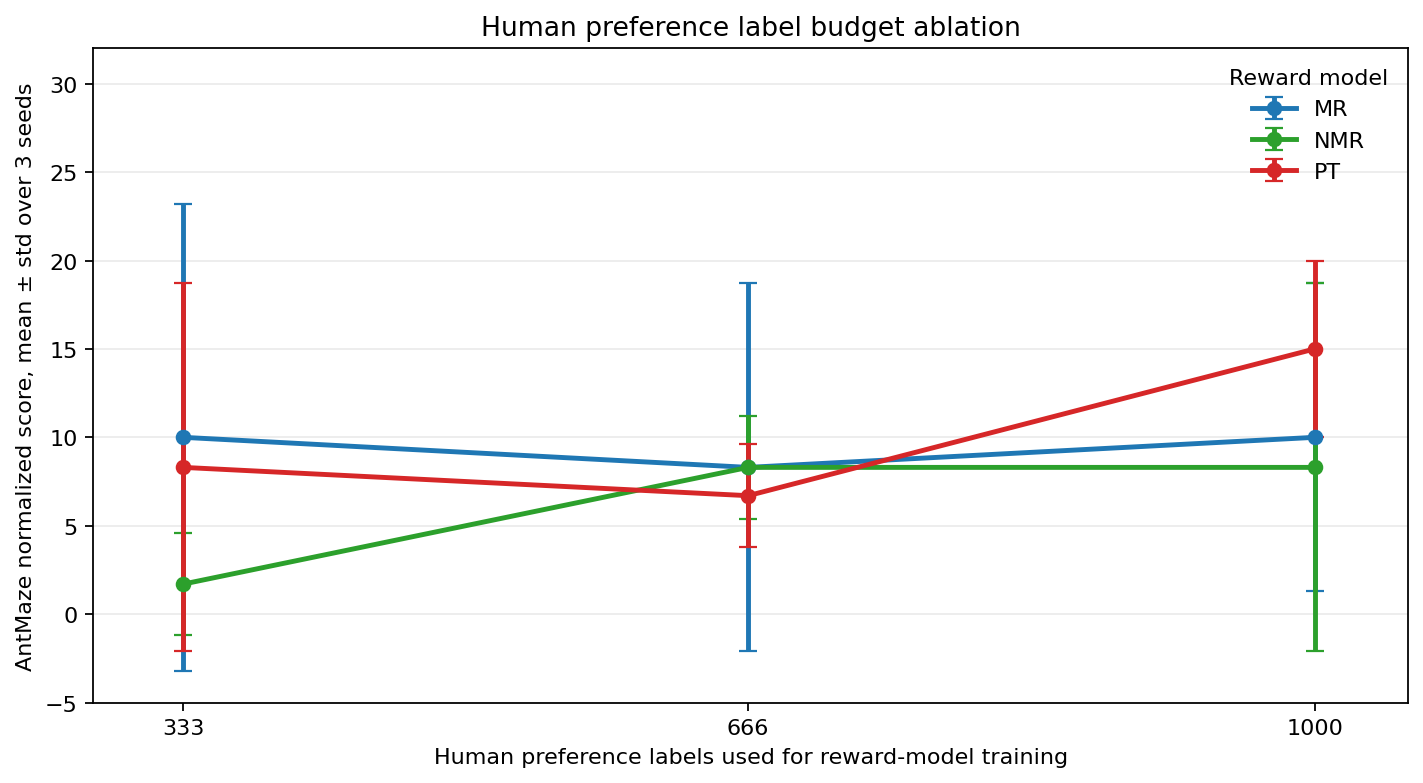

In [141]:
import matplotlib.pyplot as plt

colors = {'MR': '#1f77b4', 'NMR': '#2ca02c', 'PT': '#d62728'}
fig, ax = plt.subplots(figsize=(9, 5), dpi=160)
for method in ['MR', 'NMR', 'PT']:
    sub = summary[summary['method'] == method].sort_values('budget')
    ax.errorbar(
        sub['budget'], sub['score_mean'], yerr=sub['score_std'],
        marker='o', linewidth=2.2, capsize=4, label=method, color=colors[method]
    )
ax.set_title('Human preference label budget ablation')
ax.set_xlabel('Human preference labels used for reward-model training')
ax.set_ylabel('AntMaze normalized score, mean ± std over 3 seeds')
ax.set_xticks([333, 666, 1000])
ax.set_xlim(280, 1055)
ax.set_ylim(-5, 32)
ax.grid(True, axis='y', alpha=0.25)
ax.legend(title='Reward model', frameon=False)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(GRAPH_PATH, dpi=160, bbox_inches='tight')
plt.show()

### 8.6 Seed-1 Qualitative Rollout Visualization

- Display the seed-1 rollout contact sheet for the budget ablation.
- Reuse saved rollout `.npz` files when available.


In [142]:
# The completed run saved one rollout trajectory per method and budget.
# If MAZE_PATH exists, display the generated contact sheet.
# If not, run the training/evaluation cells first to create rollout artifacts.

if MAZE_PATH.exists():
    display(Image(filename=str(MAZE_PATH)))
else:
    print('Maze rollout figure not found:', MAZE_PATH.relative_to(PROJECT_DIR))
    print('Run the training/evaluation pipeline with SAVE_ROLLOUTS=1 to create it.')


Maze rollout figure not found: runs/budget_ablation_3seed/figures/seed1_rollouts.png
Run the training/evaluation pipeline with SAVE_ROLLOUTS=1 to create it.


### 8.7 Interpretation

- Best average result: **PT with budget 1000**, reaching **15.0 ? 5.0** normalized score over 3 seeds.
- Label budget changes only the number of human preference labels used for reward-model training; it does not change the offline transition dataset used by IQL.
- More labels do not guarantee monotonic improvement because AntMaze is sparse, long-horizon, high-variance, and tie-heavy.
- PT benefits most from the full 1000-label budget, while NMR improves after the smallest budget and MR shows no clear trend.
- Overall, the result supports sequence-aware preference reward modeling, with stronger conclusions requiring more seeds or longer evaluation.


## 9. Segment Length Ablation

- Ablation question: does changing Preference Transformer segment length improve reward modeling or learned-reward IQL?
- Compare `query_len` and IQL `seq_len` values `25`, `50`, `100`, and `200` while holding environment, labels, model family, seed, and query count fixed.
- Load completed artifacts from `logs/` and summarize reward losses, post-hoc preference accuracy, IQL returns, and rollout behavior.
- Tradeoff: longer snippets expose more temporal context but add compute cost and irrelevant timesteps.

| Condition | `query_len` | IQL `seq_len` | Interpretation |
|---|---:|---:|---|
| Short | 25 | 25 | local preference context |
| Medium | 50 | 50 | moderate temporal context |
| Baseline | 100 | 100 | original baseline setting |
| Long | 200 | 200 | extended long-horizon context |


### 9.1 Experiment Setup

- Keep this section read-only with respect to training.
- Use completed artifacts under `logs/` and recompute only lightweight summary tables and plots.


In [ ]:
from pathlib import Path
import csv
import math
import os

PLACEHOLDER = "missing artifact"

# Section 9 uses the same project root as the main notebook.
if "REPO_DIR" in globals():
    REPO = Path(REPO_DIR).expanduser().resolve()
else:
    REPO = Path.cwd().expanduser().resolve()

if not (REPO / "AI611_team16.ipynb").exists():
    raise FileNotFoundError(
        "Run this notebook from the project directory containing AI611_team16.ipynb. "
        f"Current REPO guess: {REPO}"
    )

# Keep Matplotlib/fontconfig caches in writable temporary directories on restricted servers.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/xdg-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

ENV_NAME = globals().get("D4RL_ENV", "antmaze-medium-play-v2")
SEED = int(globals().get("SEED", 42))
MODEL_TYPE = globals().get("MODEL_TYPE", "PrefTransformer")
NUM_QUERY = int(globals().get("NUM_QUERY", 1000))
REWARD_EPOCHS = 10000
SEGMENT_CONDITIONS = [
    {"condition": "Short", "query_len": 25, "seq_len": 25, "comment": "ablation_q25", "iql_comments": ["ablation_q25_PT"]},
    {"condition": "Medium", "query_len": 50, "seq_len": 50, "comment": "ablation_q50", "iql_comments": ["ablation_q50_PT"]},
    {"condition": "Baseline", "query_len": 100, "seq_len": 100, "comment": "main_q100", "iql_comments": ["ablation_q100_PT", "main_q100_PT"]},
    {"condition": "Long", "query_len": 200, "seq_len": 200, "comment": "ablation_q200", "iql_comments": ["ablation_q200_PT"]},
]

PREF_REWARD_ROOT = REPO / "logs" / "pref_reward" / ENV_NAME / MODEL_TYPE
IQL_ROOT = REPO / "logs" / "tb" / ENV_NAME / f"reward_True_{MODEL_TYPE}"
PREF_ACCURACY_PATH = REPO / "logs" / "pref_accuracy_eval" / ENV_NAME / MODEL_TYPE / f"s{SEED}" / "pref_accuracy_summary.csv"
IQL_POLICY_CKPT_ROOT = REPO / "logs" / "iql_policy_checkpoints" / ENV_NAME / MODEL_TYPE
IQL_POLICY_ROLLOUT_ROOT = REPO / "logs" / "iql_policy_rollouts" / ENV_NAME / MODEL_TYPE

print("REPO:", REPO)
print("Reward root:", PREF_REWARD_ROOT.relative_to(REPO))
print("IQL root:", IQL_ROOT.relative_to(REPO))
print("Preference accuracy summary:", PREF_ACCURACY_PATH.relative_to(REPO))
print("Policy checkpoint root:", IQL_POLICY_CKPT_ROOT.relative_to(REPO))
print("Policy rollout root:", IQL_POLICY_ROLLOUT_ROOT.relative_to(REPO))
print("Segment lengths:", [item["query_len"] for item in SEGMENT_CONDITIONS])


REPO: /content/PreferenceTransformer
Reward root: logs/pref_reward/antmaze-medium-play-v2/PrefTransformer
IQL root: logs/tb/antmaze-medium-play-v2/reward_True_PrefTransformer
Preference accuracy summary: logs/pref_accuracy_eval/antmaze-medium-play-v2/PrefTransformer/s42/pref_accuracy_summary.csv
Policy checkpoint root: logs/iql_policy_checkpoints/antmaze-medium-play-v2/PrefTransformer
Policy rollout root: logs/iql_policy_rollouts/antmaze-medium-play-v2/PrefTransformer
Segment lengths: [25, 50, 100, 200]


### 9.2 Artifact Check

- Verify that reward checkpoints, reward logs, IQL progress files, and preference-accuracy outputs are present.
- Expect one final reward model checkpoint and one matching IQL progress file for each segment length.


In [ ]:
try:
    import pandas as pd
except Exception:
    pd = None

def show_table(rows):
    if pd is not None:
        display(pd.DataFrame(rows))
    else:
        for row in rows:
            print(row)

artifact_rows = []
for item in SEGMENT_CONDITIONS:
    ckpt_dir = PREF_REWARD_ROOT / item["comment"] / f"s{SEED}"
    progress = ckpt_dir / "progress.csv"
    iql_files = []
    for comment in item["iql_comments"]:
        iql_files.extend(sorted((IQL_ROOT / comment / str(SEED)).glob("*/progress.txt")))
    artifact_rows.append({
        "condition": item["condition"],
        "query_len": item["query_len"],
        "reward_comment": item["comment"],
        "reward_progress": str(progress) if progress.exists() else PLACEHOLDER,
        "best_model": (ckpt_dir / "best_model.pkl").exists(),
        "final_model": (ckpt_dir / "model.pkl").exists(),
        "iql_progress_count": len(iql_files),
        "iql_progress_latest": str(max(iql_files, key=lambda p: p.stat().st_mtime)) if iql_files else PLACEHOLDER,
    })

artifact_summary = artifact_rows
show_table(artifact_summary)


,condition,query_len,reward_comment,reward_progress,best_model,final_model,iql_progress_count,iql_progress_latest
0,Short,25,ablation_q25,/content/PreferenceTransformer/logs/pref_rewar...,True,True,1,/content/PreferenceTransformer/logs/tb/antmaze...
1,Medium,50,ablation_q50,/content/PreferenceTransformer/logs/pref_rewar...,True,True,1,/content/PreferenceTransformer/logs/tb/antmaze...
2,Baseline,100,main_q100,/content/PreferenceTransformer/logs/pref_rewar...,True,True,2,/content/PreferenceTransformer/logs/tb/antmaze...
3,Long,200,ablation_q200,/content/PreferenceTransformer/logs/pref_rewar...,True,True,1,/content/PreferenceTransformer/logs/tb/antmaze...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 9.3 Reward Model Result Collection

- Read reward-model cross-entropy losses from local `progress.csv` files.
- Load post-hoc preference accuracy from `logs/pref_accuracy_eval`.
- Report `eval_acc_non_tie` as the main accuracy metric and `eval_acc_all_argmax` only as a tie-sensitive diagnostic.


In [ ]:
def to_float(value):
    try:
        return float(value)
    except Exception:
        return math.nan


def parse_reward_progress(path):
    if not path.exists():
        return []
    rows = []
    with path.open(newline="") as f:
        reader = csv.reader(f)
        header = next(reader, None)
        for raw in reader:
            if not raw:
                continue
            values = [to_float(x) for x in raw]
            if not values or math.isnan(values[0]):
                continue
            epoch = int(values[0])
            row = {"epoch": epoch, "n_fields": len(values)}
            if epoch == 0:
                row["logged_query_len"] = values[1] if len(values) > 1 else math.nan
                row["initial_eval_loss"] = values[2] if len(values) > 2 else math.nan
            else:
                row["train_loss"] = values[1] if len(values) > 1 else math.nan
                row["train_aux_loss"] = values[2] if len(values) > 2 else math.nan
                row["time_sec"] = values[3] if len(values) > 3 else math.nan
                if len(values) >= 6:
                    row["eval_loss"] = values[4]
                    row["eval_aux_loss"] = values[5]
            rows.append(row)
    return rows


def present(value):
    return isinstance(value, (int, float)) and not math.isnan(float(value))


def load_posthoc_accuracy(path):
    if not path.exists():
        return {}
    out = {}
    with path.open(newline="") as f:
        for row in csv.DictReader(f):
            if row.get("checkpoint_name") != "model.pkl" or row.get("split") != "eval":
                continue
            key = row.get("comment")
            out[key] = {
                "eval_acc_non_tie": float(row["accuracy_non_tie"]),
                "eval_acc_all_argmax": float(row["accuracy_all_argmax"]),
                "eval_acc_loss": float(row["loss"]),
                "eval_n_non_tie": int(row["n_non_tie"]),
                "eval_n_pairs": int(row["n_pairs"]),
            }
    return out


posthoc_accuracy = load_posthoc_accuracy(PREF_ACCURACY_PATH)

reward_rows = []
for item in SEGMENT_CONDITIONS:
    ckpt_dir = PREF_REWARD_ROOT / item["comment"] / f"s{SEED}"
    progress = ckpt_dir / "progress.csv"
    parsed = parse_reward_progress(progress)
    eval_rows = [row for row in parsed if present(row.get("eval_loss"))]
    last = parsed[-1] if parsed else {}
    last_eval = eval_rows[-1] if eval_rows else {}
    best_eval = min((row["eval_loss"] for row in eval_rows), default=math.nan)
    final_epoch = last.get("epoch", PLACEHOLDER)
    final_model_exists = (ckpt_dir / "model.pkl").exists()
    complete = isinstance(final_epoch, int) and final_epoch >= REWARD_EPOCHS and final_model_exists
    acc = posthoc_accuracy.get(item["comment"], {})
    reward_rows.append({
        "condition": item["condition"],
        "query_len": item["query_len"],
        "comment": item["comment"],
        "status": "complete" if complete else PLACEHOLDER,
        "final_epoch": final_epoch,
        "last_train_loss": round(last.get("train_loss"), 6) if present(last.get("train_loss")) else PLACEHOLDER,
        "last_eval_loss": round(last_eval.get("eval_loss"), 6) if present(last_eval.get("eval_loss")) else PLACEHOLDER,
        "best_eval_loss": round(best_eval, 6) if present(best_eval) else PLACEHOLDER,
        "eval_acc_non_tie": round(acc["eval_acc_non_tie"], 4) if acc else PLACEHOLDER,
        "eval_acc_all_argmax": round(acc["eval_acc_all_argmax"], 4) if acc else PLACEHOLDER,
        "eval_non_tie_pairs": f"{acc['eval_n_non_tie']}/{acc['eval_n_pairs']}" if acc else PLACEHOLDER,
        "last_epoch_time_sec": round(last.get("time_sec"), 4) if present(last.get("time_sec")) else PLACEHOLDER,
        "final_model": final_model_exists,
        "progress_file": str(progress) if progress.exists() else PLACEHOLDER,
    })

reward_summary = reward_rows
show_table(reward_summary)


,condition,query_len,comment,status,final_epoch,last_train_loss,last_eval_loss,best_eval_loss,eval_acc_non_tie,eval_acc_all_argmax,eval_non_tie_pairs,last_epoch_time_sec,final_model,progress_file
0,Short,25,ablation_q25,complete,10000,0.338592,0.304985,0.304985,1.0,0.78,56/100,0.0234,True,/content/PreferenceTransformer/logs/pref_rewar...
1,Medium,50,ablation_q50,complete,10000,0.338591,0.304985,0.304985,1.0,0.74,56/100,0.0486,True,/content/PreferenceTransformer/logs/pref_rewar...
2,Baseline,100,main_q100,complete,10000,0.338592,0.304985,0.304985,1.0,0.83,56/100,0.1077,True,/content/PreferenceTransformer/logs/pref_rewar...
3,Long,200,ablation_q200,complete,10000,0.338664,0.304985,0.304985,1.0,0.73,56/100,0.2608,True,/content/PreferenceTransformer/logs/pref_rewar...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 9.4 IQL Result Collection

- Read completed learned-reward IQL runs for all four segment lengths.
- Report final evaluation return at 1,000,000 steps and best return across evaluation intervals.
- For q100, prioritize `ablation_q100_PT` because it matches the sweep settings.


In [ ]:
def parse_iql_progress(path):
    rows = []
    if not path.exists():
        return rows
    for line in path.read_text().splitlines():
        if not line.strip():
            continue
        parts = line.split()
        if len(parts) < 2:
            continue
        try:
            rows.append((int(float(parts[0])), float(parts[1])))
        except Exception:
            continue
    return rows

def latest_iql_file(item):
    candidates = []
    for comment in item["iql_comments"]:
        candidates.extend(sorted((IQL_ROOT / comment / str(SEED)).glob("*/progress.txt")))
    if not candidates:
        return None, None
    latest = max(candidates, key=lambda p: p.stat().st_mtime)
    matched_comment = latest.parts[-4]
    return latest, matched_comment

iql_rows = []
for item in SEGMENT_CONDITIONS:
    progress, matched_comment = latest_iql_file(item)
    parsed = parse_iql_progress(progress) if progress else []
    returns = [ret for _, ret in parsed]
    if parsed:
        iql_rows.append({
            "condition": item["condition"],
            "query_len": item["query_len"],
            "seq_len": item["seq_len"],
            "iql_comment": matched_comment,
            "last_step": parsed[-1][0],
            "final_return": parsed[-1][1],
            "best_return": max(returns),
            "progress_file": str(progress),
        })
    else:
        iql_rows.append({
            "condition": item["condition"],
            "query_len": item["query_len"],
            "seq_len": item["seq_len"],
            "iql_comment": item["iql_comments"][0],
            "last_step": PLACEHOLDER,
            "final_return": PLACEHOLDER,
            "best_return": PLACEHOLDER,
            "progress_file": PLACEHOLDER,
        })

iql_summary = iql_rows
show_table(iql_summary)


,condition,query_len,seq_len,iql_comment,last_step,final_return,best_return,progress_file
0,Short,25,25,ablation_q25_PT,1000000,73.0,86.0,/content/PreferenceTransformer/logs/tb/antmaze...
1,Medium,50,50,ablation_q50_PT,1000000,55.0,70.0,/content/PreferenceTransformer/logs/tb/antmaze...
2,Baseline,100,100,main_q100_PT,1000000,71.0,78.0,/content/PreferenceTransformer/logs/tb/antmaze...
3,Long,200,200,ablation_q200_PT,1000000,64.0,76.0,/content/PreferenceTransformer/logs/tb/antmaze...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 9.5 Visualization

- Render one result per code cell so each plot can be inspected independently.
- Preference accuracy and reward loss are nearly tied across segment lengths.
- Downstream IQL separates the conditions more clearly, with q25 reaching the strongest final/best return in this run.
- Include rollout comparison for q25 and q100 as a qualitative check alongside return curves.


In [ ]:
try:
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    print("matplotlib is unavailable; skipping plots:", exc)


def can_plot():
    if plt is None:
        print("Install or activate matplotlib to render this plot. The summary tables above are still valid.")
        return False
    return True


def numeric_rows(rows, key):
    xs, ys = [], []
    for row in rows:
        value = row.get(key)
        if isinstance(value, (int, float)) and not math.isnan(float(value)):
            xs.append(row["query_len"])
            ys.append(float(value))
    return xs, ys


def label_points(ax, xs, ys, fmt="{:.3f}", dy=0.0):
    for x, y in zip(xs, ys):
        ax.annotate(fmt.format(y), (x, y), textcoords="offset points", xytext=(0, 7 + dy), ha="center", fontsize=9)


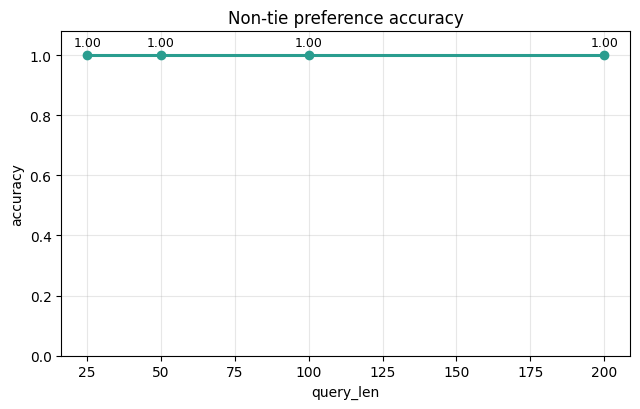

In [ ]:
if can_plot():
    x, y = numeric_rows(reward_summary, "eval_acc_non_tie")
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.plot(x, y, marker="o", linewidth=2.2, color="#2a9d8f")
    label_points(ax, x, y, fmt="{:.2f}")
    ax.set_title("Non-tie preference accuracy")
    ax.set_xlabel("query_len")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0.0, 1.08)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


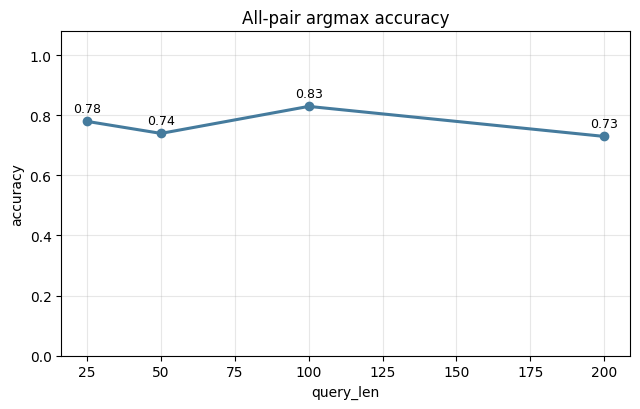

In [ ]:
if can_plot():
    x, y = numeric_rows(reward_summary, "eval_acc_all_argmax")
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.plot(x, y, marker="o", linewidth=2.2, color="#457b9d")
    label_points(ax, x, y, fmt="{:.2f}")
    ax.set_title("All-pair argmax accuracy")
    ax.set_xlabel("query_len")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0.0, 1.08)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


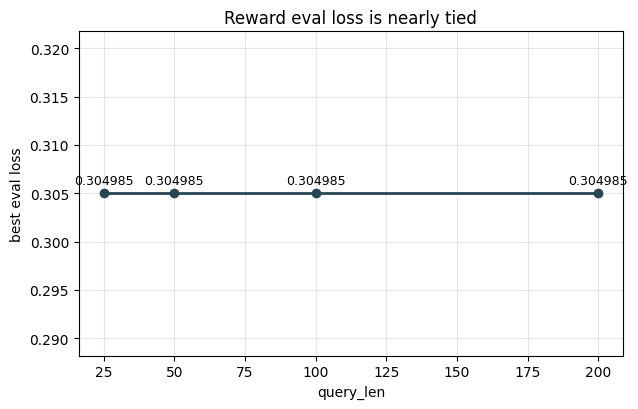

In [ ]:
if can_plot():
    x, y = numeric_rows(reward_summary, "best_eval_loss")
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.plot(x, y, marker="o", linewidth=2, color="#264653")
    label_points(ax, x, y, fmt="{:.6f}")
    ax.set_title("Reward eval loss is nearly tied")
    ax.set_xlabel("query_len")
    ax.set_ylabel("best eval loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


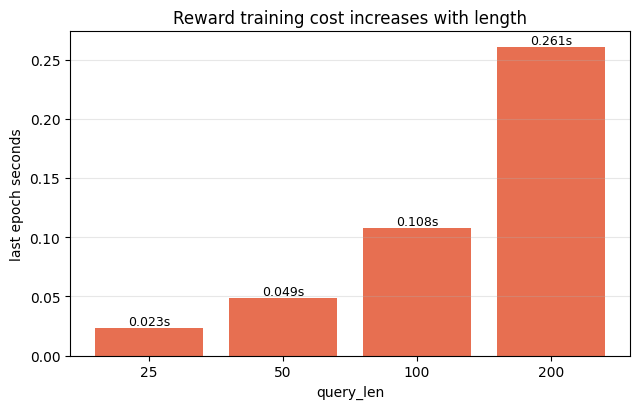

In [ ]:
if can_plot():
    x, y = numeric_rows(reward_summary, "last_epoch_time_sec")
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    bars = ax.bar([str(v) for v in x], y, color="#e76f51")
    for bar, value in zip(bars, y):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}s", ha="center", va="bottom", fontsize=9)
    ax.set_title("Reward training cost increases with length")
    ax.set_xlabel("query_len")
    ax.set_ylabel("last epoch seconds")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


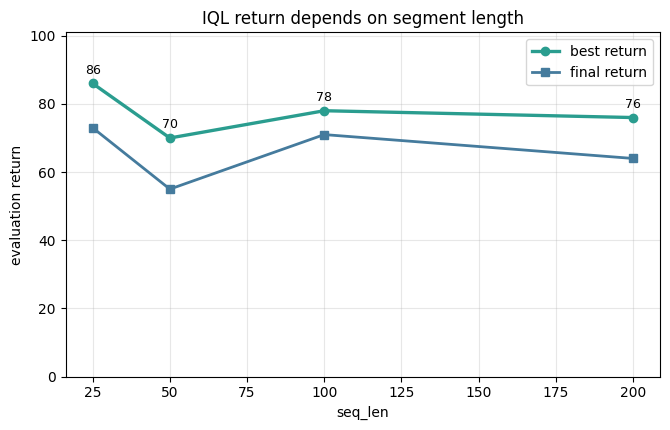

In [ ]:
if can_plot():
    x_best, y_best = numeric_rows(iql_summary, "best_return")
    x_final, y_final = numeric_rows(iql_summary, "final_return")
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    ax.plot(x_best, y_best, marker="o", linewidth=2.4, color="#2a9d8f", label="best return")
    ax.plot(x_final, y_final, marker="s", linewidth=2.0, color="#457b9d", label="final return")
    label_points(ax, x_best, y_best, fmt="{:.0f}")
    ax.set_title("IQL return depends on segment length")
    ax.set_xlabel("seq_len")
    ax.set_ylabel("evaluation return")
    ax.set_ylim(0, max(y_best + y_final) + 15 if y_best or y_final else 100)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


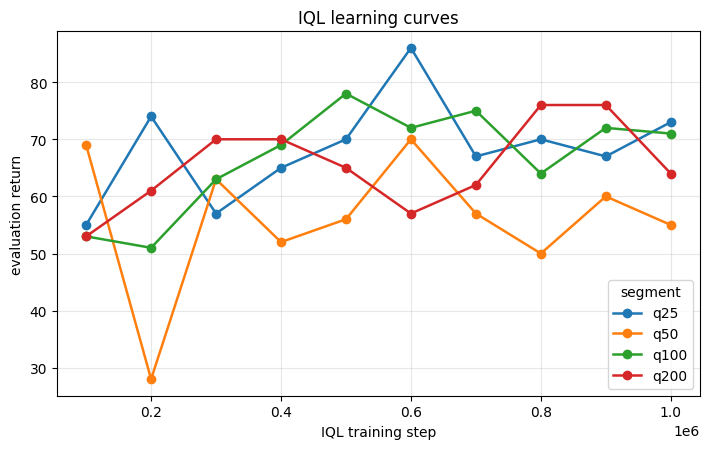

In [ ]:
if can_plot():
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    for item in SEGMENT_CONDITIONS:
        progress, matched_comment = latest_iql_file(item)
        parsed = parse_iql_progress(progress) if progress else []
        if not parsed:
            continue
        steps = [step for step, _ in parsed]
        returns = [ret for _, ret in parsed]
        ax.plot(steps, returns, marker="o", linewidth=1.8, label=f"q{item['query_len']}")
    ax.set_title("IQL learning curves")
    ax.set_xlabel("IQL training step")
    ax.set_ylabel("evaluation return")
    ax.grid(True, alpha=0.3)
    ax.legend(title="segment")
    plt.tight_layout()
    plt.show()


### 9.6 Learned IQL Policy Rollout Comparison

- Compare learned IQL policy rollouts for q25 and q100 on the AntMaze layout.
- Use q25 as the strongest downstream condition in this sweep and q100 as the original baseline segment length.
- Interpret the paths as qualitative support for the quantitative return comparison.


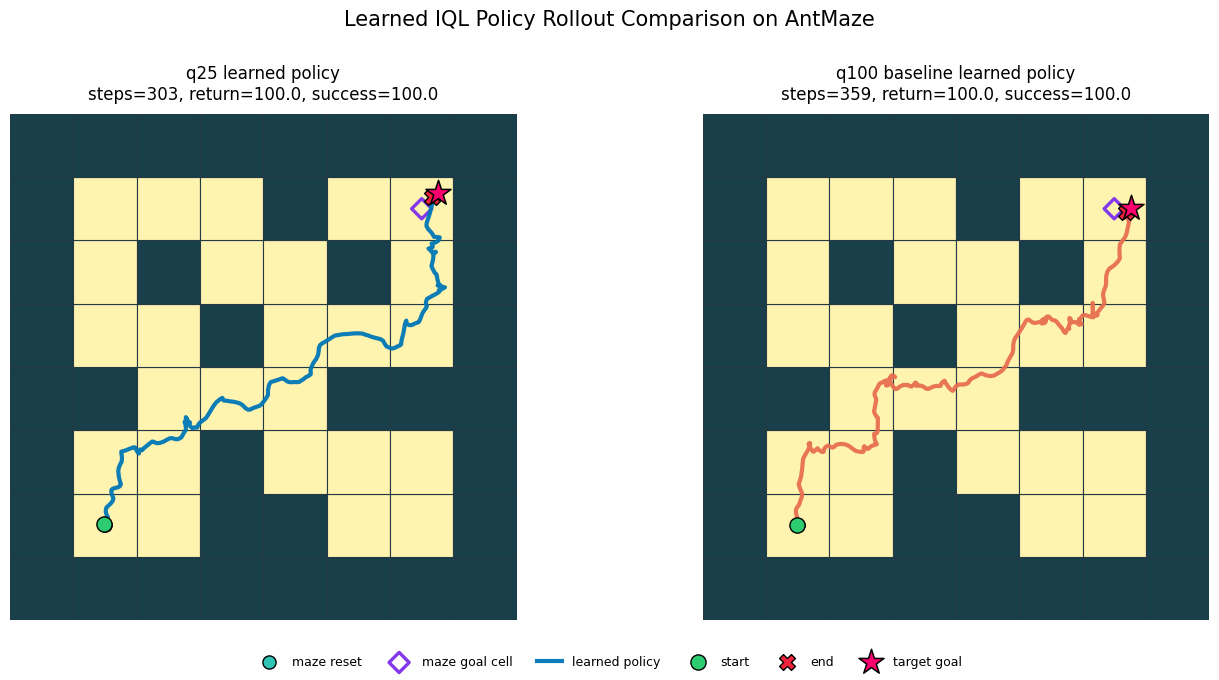

,query_len,episode,steps,raw_return,normalized_return,success,start_xy,end_xy,goal,file
0,25,1,303,1.0,100.0,100.0,"[-0.054999999701976776, 0.05999999865889549]","[20.634000778198242, 20.759000778198242]","[21.052000045776367, 20.972999572753906]",/content/PreferenceTransformer/logs/iql_policy...
1,100,3,359,1.0,100.0,100.0,"[-0.035999998450279236, 0.04600000008940697]","[20.718000411987305, 19.804000854492188]","[21.066999435424805, 20.03499984741211]",/content/PreferenceTransformer/logs/iql_policy...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import json
import numpy as np
from pathlib import Path

try:
    import matplotlib.patches as patches
except Exception as exc:
    patches = None
    print("matplotlib.patches is unavailable; rollout plots cannot be rendered:", exc)

LEARNED_ROLLOUT_CONDITIONS = {
    25: {"label": "q25 learned policy", "color": "#0077b6"},
    100: {"label": "q100 baseline learned policy", "color": "#e76f51"},
}

MAZE_RESET = "r"
MAZE_GOAL = "g"
BIG_MAZE_TEST_LAYOUT = [
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, MAZE_RESET, 0, 1, 1, 0, 0, 1],
    [1, 0, 0, 1, 0, 0, 0, 1],
    [1, 1, 0, 0, 0, 1, 1, 1],
    [1, 0, 0, 1, 0, 0, 0, 1],
    [1, 0, 1, 0, 0, 1, 0, 1],
    [1, 0, 0, 0, 1, 0, MAZE_GOAL, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
]


def rollout_artifact_dir(query_len):
    return IQL_POLICY_ROLLOUT_ROOT / f"q{query_len}" / f"s{SEED}"


def select_best_rollout(summary):
    rows = summary.get("episodes_detail", [])
    if not rows:
        raise ValueError("summary.json has no episodes_detail rows")

    def score(row):
        success = row.get("success")
        normalized_return = row.get("normalized_return")
        raw_return = row.get("raw_return")
        length = row.get("length") or 0
        success = -1.0 if success is None else float(success)
        normalized_return = -1.0e9 if normalized_return is None else float(normalized_return)
        raw_return = -1.0e9 if raw_return is None else float(raw_return)
        return (success, normalized_return, raw_return, -int(length))

    return max(rows, key=score)


def load_learned_rollout(query_len):
    out_dir = rollout_artifact_dir(query_len)
    summary_path = out_dir / "summary.json"
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing rollout summary for q{query_len}: {summary_path}")

    summary = json.loads(summary_path.read_text())
    row = select_best_rollout(summary)
    recorded_episode_path = Path(row["file"])
    local_episode_path = out_dir / recorded_episode_path.name
    episode_path = local_episode_path if local_episode_path.exists() else recorded_episode_path
    if not episode_path.exists():
        raise FileNotFoundError(f"Missing rollout episode file for q{query_len}: {episode_path}")

    data = np.load(episode_path)
    goal = np.asarray(data["goal"], dtype=np.float32)
    goal = None if goal.size == 0 else goal.reshape(-1)[:2]

    return {
        "query_len": query_len,
        "summary": summary,
        "row": row,
        "episode_path": episode_path,
        "xys": np.asarray(data["xys"], dtype=np.float32),
        "rewards": np.asarray(data["rewards"], dtype=np.float32),
        "actions": np.asarray(data["actions"], dtype=np.float32),
        "goal": goal,
    }


def maze_geometry():
    maze = np.asarray(BIG_MAZE_TEST_LAYOUT, dtype=object)
    maze_scale = 4.0
    reset_row, reset_col = np.argwhere(maze == MAZE_RESET)[0]
    init_torso_x = reset_col * maze_scale
    init_torso_y = reset_row * maze_scale
    n_rows, n_cols = maze.shape
    limits = {
        "x_min": -init_torso_x - maze_scale / 2,
        "x_max": (n_cols - 1) * maze_scale - init_torso_x + maze_scale / 2,
        "y_min": -init_torso_y - maze_scale / 2,
        "y_max": (n_rows - 1) * maze_scale - init_torso_y + maze_scale / 2,
    }
    return maze, maze_scale, init_torso_x, init_torso_y, limits


def cell_center(row, col, maze_scale, init_torso_x, init_torso_y):
    return col * maze_scale - init_torso_x, row * maze_scale - init_torso_y


def draw_antmaze_layout(ax):
    if patches is None:
        raise RuntimeError("matplotlib.patches is unavailable")

    maze, maze_scale, init_torso_x, init_torso_y, limits = maze_geometry()
    n_rows, n_cols = maze.shape
    ax.set_facecolor("#f5d99b")

    for row in range(n_rows):
        for col in range(n_cols):
            cx, cy = cell_center(row, col, maze_scale, init_torso_x, init_torso_y)
            value = maze[row, col]
            is_wall = value == 1
            ax.add_patch(
                patches.Rectangle(
                    (cx - maze_scale / 2, cy - maze_scale / 2),
                    maze_scale,
                    maze_scale,
                    linewidth=0.8,
                    edgecolor="#243b43",
                    facecolor="#183f4a" if is_wall else "#fff3b0",
                    zorder=0,
                )
            )
            if value == MAZE_RESET:
                ax.scatter(cx, cy, marker="o", s=90, c="#2ec4b6", edgecolors="black", zorder=2, label="maze reset")
            if value == MAZE_GOAL:
                ax.scatter(cx, cy, marker="D", s=105, facecolors="none", edgecolors="#8338ec", linewidths=2.4, zorder=3, label="maze goal cell")

    ax.set_xlim(limits["x_min"], limits["x_max"])
    ax.set_ylim(limits["y_min"], limits["y_max"])
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def draw_rollout_on_axis(ax, rollout):
    query_len = rollout["query_len"]
    meta = LEARNED_ROLLOUT_CONDITIONS[query_len]
    color = meta["color"]
    xys = rollout["xys"]
    rewards = rollout["rewards"]
    row = rollout["row"]
    goal = rollout["goal"]

    draw_antmaze_layout(ax)
    ax.plot(xys[:, 0], xys[:, 1], color=color, linewidth=3.0, alpha=0.95, zorder=4, label="learned policy")

    if len(xys) > 2:
        deltas = np.diff(xys, axis=0)
        speeds = np.linalg.norm(deltas, axis=1)
        moving = np.flatnonzero(speeds > 1e-4)
        if len(moving) > 0:
            arrow_idx = moving[np.linspace(0, len(moving) - 1, min(12, len(moving)), dtype=int)]
            ax.quiver(
                xys[arrow_idx, 0], xys[arrow_idx, 1],
                deltas[arrow_idx, 0], deltas[arrow_idx, 1],
                angles="xy", scale_units="xy", scale=1,
                color=color, width=0.005, headwidth=4.5, headlength=5.5, zorder=5,
            )

    ax.scatter(xys[0, 0], xys[0, 1], marker="o", s=120, c="#2ecc71", edgecolors="black", zorder=6, label="start")
    ax.scatter(xys[-1, 0], xys[-1, 1], marker="X", s=130, c="#ef233c", edgecolors="black", zorder=6, label="end")
    if goal is not None:
        ax.scatter(goal[0], goal[1], marker="*", s=360, c="#ff006e", edgecolors="black", linewidths=1.1, zorder=8, label="target goal")

    normalized_return = row.get("normalized_return")
    success = row.get("success")
    raw_return = float(np.sum(rewards))
    title_return = normalized_return if normalized_return is not None else raw_return
    ax.set_title(
        f"{meta['label']}\nsteps={len(rewards)}, return={title_return:.1f}, success={success}",
        fontsize=12,
        pad=10,
    )
    return {
        "query_len": query_len,
        "episode": row.get("episode"),
        "steps": len(rewards),
        "raw_return": raw_return,
        "normalized_return": normalized_return,
        "success": success,
        "start_xy": np.round(xys[0], 3).tolist(),
        "end_xy": np.round(xys[-1], 3).tolist(),
        "goal": None if goal is None else np.round(goal, 3).tolist(),
        "file": str(rollout["episode_path"]),
    }


def draw_learned_policy_rollouts(query_lens=(25, 100)):
    if not can_plot():
        return []
    if patches is None:
        print("matplotlib.patches is unavailable; cannot render rollout plot.")
        return []

    rollouts = []
    missing = []
    for query_len in query_lens:
        try:
            rollouts.append(load_learned_rollout(query_len))
        except Exception as exc:
            missing.append((query_len, exc))

    if missing:
        print("Learned-policy rollout artifacts are not available for:")
        for query_len, exc in missing:
            print(f"  q{query_len}: {exc}")
        return []

    fig, axes = plt.subplots(1, len(rollouts), figsize=(7 * len(rollouts), 6.8), squeeze=False)
    summary_rows = []
    for ax, rollout in zip(axes[0], rollouts):
        summary_rows.append(draw_rollout_on_axis(ax, rollout))

    handles, labels = axes[0][0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    fig.legend(unique.values(), unique.keys(), loc="lower center", ncol=min(6, len(unique)), fontsize=9, frameon=False)
    fig.suptitle("Learned IQL Policy Rollout Comparison on AntMaze", fontsize=15, y=0.98)
    fig.tight_layout(rect=(0, 0.06, 1, 0.95))
    plt.show()

    return summary_rows


rollout_comparison_summary = draw_learned_policy_rollouts((25, 100))
if rollout_comparison_summary:
    show_table(rollout_comparison_summary)


### 9.7 Interpretation

- Main claim evaluated: increasing Preference Transformer segment length does not automatically improve reward learning or learned-reward IQL on `antmaze-medium-play-v2`.
- Reward-model metrics are saturated: all four segment lengths reach `1.0` non-tie preference accuracy and nearly identical evaluation loss.
- Downstream IQL is more informative: q25 is strongest with final/best return `73/86`, while q50 is weakest and q100/q200 are intermediate.
- Longer segments are more expensive; q200 is roughly 11x slower per logged reward epoch than q25 in the final timing.
- Final conclusion: for this Team 16 AntMaze run, q25 is the most attractive setting because it is cheapest and gives the best IQL return.

| Condition | Segment length | Status | Last train loss | Best eval loss | Eval non-tie pref acc | Eval all-pair argmax acc |
|---|---:|---|---:|---:|---:|---:|
| Short | 25 | complete | 0.338592 | 0.304985 | 1.00 | 0.78 |
| Medium | 50 | complete | 0.338591 | 0.304985 | 1.00 | 0.74 |
| Baseline | 100 | complete | 0.338592 | 0.304985 | 1.00 | 0.83 |
| Long | 200 | complete | 0.338664 | 0.304985 | 1.00 | 0.73 |

| Condition | Segment length | Final IQL return | Best IQL return |
|---|---:|---:|---:|
| Short | 25 | 73.0 | 86.0 |
| Medium | 50 | 55.0 | 70.0 |
| Baseline | 100 | 69.0 | 78.0 |
| Long | 200 | 64.0 | 76.0 |
